# Similarity Mejoras

## Libraries

In [1]:
import sys

print('Python version: ', sys.version)

Python version:  3.11.4 | packaged by conda-forge | (main, Jun 10 2023, 18:08:17) [GCC 12.2.0]


In [2]:
# Desactiva por completo la dependencia con TorchVision en Transformers
import os
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"   # <- clave
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"      # opcional, menos ruido
os.environ["TRANSFORMERS_NO_TF"] = "1"       # <— evita que Transformers intente cargar TensorFlow
os.environ["TRANSFORMERS_NO_FLAX"] = "1"     # opcional, por si acaso

In [3]:
import site, sys
sys.path.insert(0, site.getusersitepackages())
print("usersite:", site.getusersitepackages())

usersite: /home/jovyan/.local/lib/python3.11/site-packages


In [4]:
!pip uninstall -y sentence-transformers transformers tokenizers torchvision

Found existing installation: transformers 4.36.2
Uninstalling transformers-4.36.2:
  Successfully uninstalled transformers-4.36.2
Found existing installation: tokenizers 0.15.0
Uninstalling tokenizers-0.15.0:
  Successfully uninstalled tokenizers-0.15.0


In [5]:
# Instala versiones probadas para Python 3.11 (sin tocar torch/cuda del sistema)
# NOTA: usamos --user para no requerir root; --no-cache-dir por si hay ruedas viejas cacheadas
!pip install --user --upgrade --no-cache-dir \
  "numpy==1.23.5" \
  "tokenizers==0.20.3" \
  "transformers==4.46.3" \
  "sentence-transformers==2.6.1" \
  "scikit-learn==1.5.2" \
  "pandas==2.2.3" \
  "pyarrow==17.0.0" \
  "numexpr>=2.10.1" \
  "bottleneck>=1.4.0"



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 55.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 81.5 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 143.4 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import numpy, pandas, sklearn, transformers, tokenizers, sentence_transformers, torch, pyarrow, numexpr, bottleneck
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__, "| tokenizers:", tokenizers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available(), "| cuda ver:", torch.version.cuda)
print("pyarrow:", pyarrow.__version__)
print("numexpr:", numexpr.__version__)
print("bottleneck:", bottleneck.__version__)

numpy: 1.23.5
pandas: 2.2.3
sklearn: 1.5.2
transformers: 4.46.3 | tokenizers: 0.20.3
sentence-transformers: 2.6.1
torch: 2.8.0+cu128 | cuda: True | cuda ver: 12.8
pyarrow: 17.0.0
numexpr: 2.12.1
bottleneck: 1.6.0


In [7]:
import types

if "torchvision" not in sys.modules:
    tv = types.ModuleType("torchvision")
    tv_t = types.ModuleType("torchvision.transforms")
    class _InterpolationMode: pass
    tv_t.InterpolationMode = _InterpolationMode
    tv.transforms = tv_t
    sys.modules["torchvision"] = tv
    sys.modules["torchvision.transforms"] = tv_t

# (Opcional) Si por alguna razón Transformers todavía cree que hay TF, fuerza a falso:
try:
    import transformers.utils.import_utils as _iu
    _iu.is_tf_available = lambda: False
except Exception:
    pass

print("Guardia OK. usersite first:", sys.path[0])

Guardia OK. usersite first: /home/jovyan/.local/lib/python3.11/site-packages


In [8]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

emb = model.encode(["hola mundo"], convert_to_tensor=True)
print(emb.shape, emb.device)


torch.Size([1, 384]) cuda:0


## A) Setup básico y rutas portables 

In [9]:
# --- Semillas + device coherente ---
import os, random, numpy as np
from pathlib import Path

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

def get_device():
    try:
        import torch
        if torch.cuda.is_available():
            return "cuda"
        # soporte Apple Silicon
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
    except Exception:
        pass
    return "cpu"

SEED = int(os.getenv("SEED", "42"))
set_seed(SEED)
DEVICE = get_device()
print(f"[Setup] SEED={SEED} | DEVICE={DEVICE}")



[Setup] SEED=42 | DEVICE=cuda


In [10]:
# --- Rutas portables ---
BASE_DIR = Path.cwd()
DATA_DIR = Path(os.getenv("DATA_DIR", BASE_DIR / "data"))
RESULTS_DIR = Path(os.getenv("RESULTS_DIR", BASE_DIR / "results"))
PLOTS_DIR = Path(os.getenv("PLOTS_DIR", BASE_DIR / "plots"))

for d in (DATA_DIR, RESULTS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR   : {BASE_DIR}")
print(f"DATA_DIR   : {DATA_DIR} (exists={DATA_DIR.exists()})")
print(f"RESULTS_DIR: {RESULTS_DIR} (exists={RESULTS_DIR.exists()})")
print(f"PLOTS_DIR  : {PLOTS_DIR} (exists={PLOTS_DIR.exists()})")


BASE_DIR   : /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras
DATA_DIR   : /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/data (exists=True)
RESULTS_DIR: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results (exists=True)
PLOTS_DIR  : /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots (exists=True)


In [ ]:
# --- Búsqueda de dwas.(tsv/csv) en múltiples ubicaciones ---
from hashlib import md5
from pathlib import Path
import pandas as pd
import csv

CANDIDATE_DWA_PATHS = [
    DATA_DIR / "dwas.tsv",
    BASE_DIR / "dwas.tsv",
    Path("/mnt/data/dwas.tsv"),
    DATA_DIR / "dwas.csv",
    BASE_DIR / "dwas.csv",
    Path("/mnt/data/dwas.csv"),
]

dwa_path = next((p for p in CANDIDATE_DWA_PATHS if p.exists()), None)
assert dwa_path is not None, f"No se encontró dwas.(tsv/csv) en {CANDIDATE_DWA_PATHS}"

def file_md5(path: Path) -> str:
    import hashlib
    return hashlib.md5(path.read_bytes()).hexdigest()

print(f"[Datos] dwas file: {dwa_path} | md5={file_md5(dwa_path)}")


### ¿Qué es el MD5?
MD5 es un algoritmo de hash (resumen criptográfico). Si aplicas MD5 a un archivo (ej. tu dwas.csv), te devuelve una “huella digital” de 32 caracteres hexadecimales.

Ejemplo:
```
Hola → 8b1a9953c4611296a827abf8c47804d7

hola → 4d186321c1a7f0f354b297e8914ab240
(con solo cambiar una letra, el hash cambia totalmente).
```

¿Para qué sirve aquí?: Para saber si el dataset ha cambiado entre ejecuciones. Si guardas ese hash en tus resultados (run_info.json o incluso en un print al arrancar), luego puedes comprobar:

¿Estoy evaluando siempre sobre el mismo dwas.csv? ¿O se ha actualizado / corrompido / descargado otro diferente?

En resumen:
* No cambia nada en el flujo de datos, es solo una forma rápida de verificar la integridad y versión exacta de tu dataset.
* Si no lo ves necesario, se puede quitar sin problema; pero en proyectos con versiones largas, ayuda a evitar confusiones (“¿por qué este run me da 210 DWAs y el otro 221?”).

In [11]:
import pandas as pd
import unicodedata, re

def normalize_text(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


In [ ]:

# --- Lector robusto (elige separador por extensión y evita el sniffer) ---
def load_dwa(path: Path) -> pd.DataFrame:
    ext = path.suffix.lower()
    try:
        if ext == ".tsv":
            # TSV: separador explícito, sin sniffer
            df = pd.read_csv(path, sep="\t", encoding="utf-8", dtype=str)
        elif ext == ".csv":
            # CSV: lector estándar por defecto (evita sep=None/engine=python)
            df = pd.read_csv(path, encoding="utf-8", dtype=str)
        else:
            raise ValueError(f"Extensión no soportada: {ext}")
        return df
    except Exception as e:
        # Fallback: trata cada línea como una única celda
        print(f"[WARN] Lectura estándar falló ({e}). Usando modo 1-columna-por-línea.")
        lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
        # si la primera línea es cabecera, elimínala
        if lines and lines[0].strip().lower() == "dwa_title":
            lines = lines[1:]
        # limpia tabs “inadvertidos” que generan columnas ficticias
        values = [ln.replace("\t", " ").strip() for ln in lines]
        return pd.DataFrame({"dwa_title": values}, dtype=str)


In [ ]:

df_onet = load_dwa(dwa_path)

# Normaliza columnas
if "dwa_title" not in df_onet.columns:
    # si el archivo venía sin header correcto
    first_col = df_onet.columns[0]
    df_onet = df_onet.rename(columns={first_col: "dwa_title"})

# Limpieza básica
df_onet["dwa_title"] = df_onet["dwa_title"].astype(str).map(normalize_text)
df_onet = df_onet[df_onet["dwa_title"] != ""]
df_onet = df_onet.drop_duplicates(subset=["dwa_title"]).reset_index(drop=True)

# Generar un ID estable si no existe 'dwa_id'
if "dwa_id" not in df_onet.columns:
    df_onet["dwa_id"] = df_onet["dwa_title"].apply(lambda t: md5(t.encode("utf-8")).hexdigest()[:12])

# (Opcional) Guardar versión canónica TSV (1 col) para el resto del pipeline
CANON = Path(DATA_DIR / "dwas_canonical.tsv")
df_onet[["dwa_title"]].to_csv(CANON, sep="\t", index=False, encoding="utf-8")
print(f"[Datos] DWAs: {len(df_onet)} | TSV canónico: {CANON}")

# Construir corpus y etiquetas trazables
CORPUS_TEXTS  = df_onet["dwa_title"].tolist()
CORPUS_LABELS = df_onet["dwa_id"].tolist()

print(f"[Datos] Ejemplo:\n{df_onet.head(3)[['dwa_id','dwa_title']]}")


## B) Utils: limpieza y funciones auxiliares

In [13]:
import re, unicodedata

# STOPWORDS = {
#     "the","a","an","and","or","to","of","in","on","for","with","by","from",
#     "is","are","be","being","been","as","at","that","this","these","those",
#     "using","use","used","via","into","out","up","down","over","under",
# }

STOPWORDS = {
    "the","a","an","and","or","of","to","for","in","on","with","by","from",
    "de","la","el","los","las","y","o","del","para","en","con","por"
}
# Amplía si usas ES: {"y","o","de","la","el","los","las","para","con","por","en",...}

TOKEN_RE = re.compile(
    r"[A-Za-z0-9\+\#\.\/\-]+"  # conserva C++, C#, Node.js, ETL/ELT, quality-control
)

def normalize_nfkc(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def strip_accents(s: str) -> str:
    # útil si mezclas ES/EN y no quieres que 'gestión' != 'gestion'
    nfkd = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in nfkd if not unicodedata.combining(ch))

def analyze_text(
    s: str,
    *,
    lower: bool = True,
    remove_accents: bool = False,
    stopset = STOPWORDS,
):
    s = normalize_nfkc(s)
    if remove_accents:
        s = strip_accents(s)
    if lower:
        s = s.lower()
    toks = TOKEN_RE.findall(s)
    # quita tokens triviales (1 char) salvo casos técnicos (c, r, .net):
    toks = [t for t in toks if len(t) > 1 or t in {"c", "r"}]
    # stopwords
    if stopset:
        toks = [t for t in toks if t not in stopset]
    return toks



### Jaccard (coeficiente de Jaccard)

**Qué es:**
Es una métrica de **similitud entre conjuntos**.
Mide qué proporción de elementos comparten dos conjuntos respecto al total combinado.

**Fórmula:**

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$

* $|A \cap B|$ = número de tokens comunes.
* $|A \cup B|$ = número de tokens únicos en ambos.

**Ejemplo:**

* Query: “data analysis with Python” → {data, analysis, python}
* Candidato: “python for data science” → {python, data, science}
* Intersección = {data, python} → 2
* Unión = {data, analysis, python, science} → 4
* Jaccard = 2/4 = 0.5

**Variante con stopwords:**
Se eliminan “the, and, with, …” antes de calcular para que no inflen el score.

Es un **indicador léxico muy simple**, pero útil como penalización: si la similitud coseno es alta pero el Jaccard es 0, probablemente es un **falso positivo**.

In [14]:
from collections import Counter
import math

# def jaccard_pure(a_tokens, b_tokens):
#     A, B = set(a_tokens), set(b_tokens)
#     if not A and not B: 
#         return 0.0  # sin señal
#     inter = len(A & B)
#     union = len(A | B)
#     return inter / union

# class IDFWeighter:
#     def __init__(self, docs_tokens):
#         self.N = len(docs_tokens)
#         # df por término (document frequency)
#         df = Counter()
#         for toks in docs_tokens:
#             for t in set(toks):
#                 df[t] += 1
#         # BM25 idf con suavizado clásico
#         self.idf = {t: math.log((self.N - f + 0.5) / (f + 0.5) + 1.0) for t, f in df.items()}

#     def w(self, t): 
#         return self.idf.get(t, math.log((self.N - 0.5) / (0.5) + 1.0))  # OOV alto pero razonable

# def jaccard_weighted(a_tokens, b_tokens, idf_weighter: IDFWeighter):
#     A, B = set(a_tokens), set(b_tokens)
#     w = idf_weighter.w
#     inter = sum(w(t) for t in (A & B))
#     union = sum(w(t) for t in (A | B))
#     if union == 0: 
#         return 0.0
#     return inter / union


In [15]:
def drop_stopwords(tokens, stopset=None):
    stopset = STOPWORDS if stopset is None else stopset
    return [t for t in tokens if t not in stopset]

def jaccard_tokens(tokens_a, tokens_b, remove_stop=True, stopset=None) -> float:
    A = set(drop_stopwords(tokens_a, stopset)) if remove_stop else set(tokens_a)
    B = set(drop_stopwords(tokens_b, stopset)) if remove_stop else set(tokens_b)
    if not A and not B:
        return 0.0
    inter = len(A & B)
    union = len(A | B)
    return inter / (union or 1)

def jaccard_char_ngrams(a: str, b: str, n: int = 3) -> float:
    A = {a[i:i+n] for i in range(max(0, len(a)-n+1))} if a else set()
    B = {b[i:i+n] for i in range(max(0, len(b)-n+1))} if b else set()
    if not A and not B:
        return 0.0
    inter = len(A & B)
    union = len(A | B)
    return inter / (union or 1)




### Length penalty

**Qué es:**
No es un algoritmo estándar, sino una **heurística** para evitar que los modelos de embeddings emparejen frases solo por tener longitudes parecidas (o diferentes).

**Definición típica:**
Se mide la **diferencia de longitudes** entre query y candidato, y se transforma en un penalizador.

Ejemplo sencillo:

$$
\text{penalty}(q,d) = |\,|q| - |d|\,|
$$

Si query tiene 5 tokens y candidato 20, la diferencia = 15 → penalización alta.

Mejora (log-escala):

$$
\text{penalty}(q,d) = \frac{|\log(|q|) - \log(|d|)|}{2}
$$

Esto suaviza las diferencias y las acota entre \[0,1].

La idea es que dos DWAs parecidas deberían tener **longitudes cercanas**. Si el modelo da un coseno alto entre una frase muy corta y otra muy larga, puede ser sospechoso.

In [16]:

import math

def length_penalty(q_tokens, d_tokens, *, eps=1e-6):
    Lq = max(len(q_tokens), 1)
    Ld = max(len(d_tokens), 1)
    diff = abs(math.log(Lq + eps) - math.log(Ld + eps))  # simétrico en log
    # acotar: considera diffs típicos 0–2 (≈ e^2 ~7x diferencia)
    return max(0.0, min(1.0, diff / 2.0))


### BM25

**Qué es:**
BM25 (*Best Matching 25*) es una función de ranking usada en **recuperación de información** (motores de búsqueda clásicos, tipo Lucene/Elasticsearch).
Mide la **relevancia léxica** entre una consulta y un documento, teniendo en cuenta:

* cuántas veces aparecen los términos de la consulta en el documento (**frecuencia de término, TF**),
* en cuántos documentos aparece ese término en todo el corpus (**frecuencia de documento, DF → IDF**),
* y la longitud del documento (para no favorecer a documentos muy largos).

**Fórmula:**
Para un término $t$, en consulta $q$ y documento $d$:

$$
\text{BM25}(q,d) = \sum_{t \in q} IDF(t) \cdot \frac{f(t,d)\cdot (k_1 + 1)}{f(t,d) + k_1 \cdot \big(1 - b + b \cdot \tfrac{|d|}{\text{avgdl}}\big)}
$$

Donde:

* $f(t,d)$ = frecuencia del término $t$ en documento $d$.
* $|d|$ = longitud del documento.
* $\text{avgdl}$ = longitud media de los documentos en el corpus.
* $k_1$ ≈ 1.2 y $b$ ≈ 0.75 → hiperparámetros típicos.
* $IDF(t) = \log\frac{N - n_t + 0.5}{n_t + 0.5}$ con $N$ documentos y $n_t$ documentos que contienen $t$.

**Intuición:**

* Si un término aparece mucho en el documento, sube el score (pero con saturación).
* Si el término es raro en el corpus (alto IDF), pesa más.
* Si el documento es demasiado largo, se normaliza para no tener ventaja injusta.

Es un **modelo léxico puro**, no semántico. Detecta coincidencia de palabras “exactas”.

#### $k_1$ — Saturación de frecuencia de término

* Controla **cuánto crece el score** cuando un término aparece muchas veces en un documento.
* **Valores bajos (≈0.5–1.2):** la ganancia por repeticiones es pequeña, se premia más la **presencia** que la frecuencia.
* **Valores altos (≈2.0+):** se da más peso a documentos donde el término se repite mucho.

Ajusta el **impacto de TF (term frequency)**.


#### $b$ — Normalización por longitud

* Controla cuánto se corrige el score según la longitud del documento.
* **b = 0:** sin normalización → documentos largos tienen ventaja (más probabilidad de contener términos).
* **b = 1:** normalización total → documentos largos quedan más penalizados.
* **Valores típicos (≈0.75):** equilibrio entre no penalizar demasiado y evitar que “documentos largos siempre ganen”.

Ajusta la **compensación por longitud del documento**.

#### En la práctica

* **k1 = 1.2, b = 0.75** → son los valores “clásicos” que funcionan bien en la mayoría de corpus.
* Si tus DWAs son textos **cortos y de longitud similar**, el efecto de $b$ casi desaparece.
* Si mezclas DWAs con cursos (unos más largos que otros), ahí **b** se vuelve más importante.


In [17]:
class SimpleBM25:
    def __init__(self, k1=1.2, b=0.75, analyzer=analyze_text):
        self.k1 = k1
        self.b = b
        self.analyzer = analyzer
        self.docs_tokens = None
        self.df = Counter()
        self.idf = {}
        self.avgdl = 0.0
        self.N = 0

    def fit(self, corpus_texts):
        self.docs_tokens = [self.analyzer(t) for t in corpus_texts]
        self.N = len(self.docs_tokens)
        # df y longitudes
        lengths = []
        for toks in self.docs_tokens:
            lengths.append(len(toks))
            for t in set(toks):
                self.df[t] += 1
        self.avgdl = sum(lengths) / max(1, len(lengths))
        # idf suavizado clásico
        self.idf = {t: math.log((self.N - f + 0.5) / (f + 0.5) + 1.0) for t, f in self.df.items()}
        return self

    def _score_doc(self, q_toks, d_toks, idf, k1, b, avgdl):
        # frecuencia por documento
        tf = Counter(d_toks)
        dl = len(d_toks)
        denom_norm = (1 - b) + b * (dl / max(1.0, avgdl))
        score = 0.0
        for t in q_toks:
            if t not in tf: 
                continue
            idf_t = idf.get(t, 0.0)
            numer = tf[t] * (k1 + 1.0)
            denom = tf[t] + k1 * denom_norm
            score += idf_t * (numer / denom)
        return score

    def scores(self, query_text):
        assert self.docs_tokens is not None, "Llama a fit() primero"
        q_toks = self.analyzer(query_text)
        # precalcula cosas locales
        idf, k1, b, avgdl = self.idf, self.k1, self.b, self.avgdl
        # devuelve lista de scores alineada con orden de documentos
        return [self._score_doc(q_toks, d_toks, idf, k1, b, avgdl) for d_toks in self.docs_tokens]


In [18]:
def minmax_norm(arr):
    lo, hi = min(arr), max(arr)
    if hi - lo < 1e-12:
        return [0.0 for _ in arr]
    return [(x - lo) / (hi - lo) for x in arr]




### Resumen comparativo

| Métrica            | Tipo              | Qué mide                        | Fortalezas                                    | Debilidades                                  |
| ------------------ | ----------------- | ------------------------------- | --------------------------------------------- | -------------------------------------------- |
| **BM25**           | Léxica, ponderada | Relevancia por frecuencia e IDF | Captura “palabras raras”, ajusta por longitud | No ve sinónimos ni contexto semántico        |
| **Jaccard**        | Léxica, binaria   | Proporción de tokens comunes    | Muy interpretable, rápida                     | Muy frágil (sinónimos ≠, stopwords influyen) |
| **Length penalty** | Heurística        | Diferencia de longitudes        | Evita sesgos por tamaño                       | Arbitraria; necesita buen escalado           |

## C) Model loader & encoding

In [19]:
from sentence_transformers import SentenceTransformer

_ENCODER_CACHE = {}

def get_encoder(model_name: str, device: str = DEVICE):
    if model_name in _ENCODER_CACHE:
        return _ENCODER_CACHE[model_name]
    try:
        encoder = SentenceTransformer(model_name, device=device)
    except Exception as e:
        raise ValueError(f"Error cargando modelo {model_name}: {e}")
    _ENCODER_CACHE[model_name] = encoder
    return encoder



### Normalización L2

Si tienes un embedding $\mathbf{v} = (v_1, v_2, ..., v_n)$:

$$
\mathbf{v}_{norm} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2}
= \frac{\mathbf{v}}{\sqrt{\sum_{i=1}^n v_i^2}}
$$


#### ¿Qué significa?

* Tomas el vector original y lo divides por su **longitud euclídea** (la raíz cuadrada de la suma de cuadrados).
* Así el vector resultante tiene siempre tamaño 1, pero conserva su **dirección** en el espacio.


#### ¿Por qué se usa?

1. **Coseno = producto escalar**
   Si los vectores están normalizados, la **similitud coseno** se calcula simplemente con el **dot product** (producto escalar).

   $$
   \cos(\theta) = \mathbf{u} \cdot \mathbf{v}
   $$

2. **Comparabilidad**
   Evita que embeddings con norma grande den scores más altos solo por magnitud, no por dirección semántica.

3. **Estabilidad numérica**
   Los rangos de similitud quedan siempre entre $[-1, 1]$.


La normalización L2 convierte todos los embeddings en vectores unitarios para que la **similitud coseno dependa solo del ángulo** entre ellos, no de su tamaño.


In [20]:
import torch
import numpy as np

def encode_texts(texts, model_name: str, device: str = DEVICE, batch_size: int = 32):
    encoder = get_encoder(model_name, device)
    with torch.no_grad():
        emb = encoder.encode(
            texts,
            batch_size=batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,  # fuerza L2
            show_progress_bar=True,
        )
    return emb


In [21]:
import os
from pathlib import Path

EMB_CACHE_DIR = RESULTS_DIR / "embeddings"
EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def get_corpus_embeddings(model_name: str, texts, corpus_hash: str):
    slug = model_name.replace("/", "_")
    emb_path = EMB_CACHE_DIR / f"{slug}_{corpus_hash}.npy"
    if emb_path.exists():
        print(f"[Embeddings] Cargando cache {emb_path}")
        return np.load(emb_path)
    print(f"[Embeddings] Calculando embeddings con {model_name}")
    emb = encode_texts(texts, model_name)
    np.save(emb_path, emb)
    return emb


In [22]:

# --- Utils ---
import re, gc, numpy as np, pandas as pd
from pathlib import Path

def slugify_model(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")


## D) Búsqueda de vecinos con normalización local + filtros

In [23]:
from dataclasses import dataclass

@dataclass
class NeighborParams:
    k: int = 50
    k_return: int = 10
    tau_z: float | None = None       # p.ej. 1.0 → ~ percentil ~84%
    alpha_cos: float = 1.0
    beta_bm25: float = 0.5
    gamma_sem: float = 0.2          # refuerza casos cos alto + Jaccard bajo
    lam_len: float = 0.2

    # === NUEVO: paridad con _coursera para Jaccard ===
    use_char_jaccard: bool = False   # activa Jaccard de caracteres
    char_n: int = 3                  # tamaño del n-grama de char
    # ================================================
    
    use_mnn: bool = True
    mnn_k: int = 20
    mnn_hard_filter: bool = False
    mnn_bonus: float = 0.05         # suma si hay MNN
    lambda_diversity: float = 0.3    # para MMR

    


### z-score (normalización local por query)

* Mide **cuántas desviaciones estándar** por encima/debajo de la **media de la query** está un candidato.
* Para los cosenos $s_i$ de una query:

$$
z_i = \frac{s_i - \mu}{\sigma}
$$

* **Uso aquí:** si pones `tau_z`, **eliminas** candidatos con z-score bajo (peor que la media por cierto margen).
* **Ventaja:** cada query tiene una escala distinta; z-score “estandariza” la distribución de **esa** query.


In [24]:
import numpy as np

def zscore_per_query(scores):
    mu = scores.mean()
    sd = scores.std()
    sd = sd if sd > 1e-6 else 1.0
    return (scores - mu) / sd

def minmax_per_query(scores):
    lo, hi = scores.min(), scores.max()
    if hi - lo < 1e-12:
        return np.zeros_like(scores)
    return (scores - lo) / (hi - lo)



### MNN (Mutual Nearest Neighbors)

* Dos elementos $a$ y $b$ son MNN si **cada uno** aparece en el **top-k** del otro.
* **Intuición:** reciprocidad refuerza que la similitud no es “accidental”.
* **Uso aquí:** como **bonus** en el score (recomendado). Usarlo como **filtro duro** puede reducir **recall** si top-k es pequeño.

### MMR (Maximal Marginal Relevance)

* Algoritmo de re-ordenación que equilibra **relevancia** vs **diversidad**.
* En cada paso elige el candidato que maximiza:

$$
\lambda \cdot \text{relevancia} - (1-\lambda)\cdot \max_{s \in \text{seleccionados}} \text{sim}(cand, s)
$$

* **$\lambda$** cercano a 1 → prima relevancia; cercano a 0 → prima diversidad.
* **Uso aquí:** último paso sobre el **pool top-m** (m≈2×k\_return), con embeddings normalizados para medir similitud (coseno).



In [25]:

def mmr_select(cand_vectors, base_scores, k_return, lambda_div=0.3):
    """
    MMR clásico: argmax λ·rel - (1-λ)·max_sim_con_seleccionados
    cand_vectors: (m, d) embeddings normalizados
    base_scores: (m,) score ya normalizado [0,1]
    """
    m = len(base_scores)
    if m == 0:
        return []
    selected = []
    remaining = set(range(m))
    # Precompute sim matriz (m,m) si m es pequeño; si no, dot on-the-fly
    S = cand_vectors @ cand_vectors.T  # cosenos (ya normalizados)
    while len(selected) < min(k_return, m):
        best, best_val = None, -1e9
        for i in list(remaining):
            if not selected:
                div_pen = 0.0
            else:
                div_pen = S[i, selected].max()
            val = lambda_div * base_scores[i] - (1.0 - lambda_div) * div_pen
            if val > best_val:
                best, best_val = i, val
        selected.append(best)
        remaining.remove(best)
    return selected


In [26]:

def nearest_neighbors_dwa(
    texts, labels, embeddings, params: NeighborParams,
    bm25_index=None, doc_tokens=None, idf_weighter=None
):
    """
    Devuelve DataFrame ancho por query con columnas: idx_r, label_r, sim_r, z_r, bm25_r, jacc_pure_r, lenpen_r, mnn_r, score_r
    """
    import pandas as pd
    n = len(texts)
    d = embeddings.shape[1]
    assert embeddings.shape[0] == n
    # Pre-cálculos
    # Embeddings L2-normalizados ya en C → cos(q, ·) = dot
    E = embeddings
    # Tokenización cacheada opcional
    if doc_tokens is None:
        from functools import lru_cache
        doc_tokens = [analyze_text(t) for t in texts]

    # --- bucle por query (batchable si hace falta) ---
    rows = []
    for qi in range(n):
        q_lab = labels[qi]
        q_txt = texts[qi]
        q_vec = E[qi:qi+1]  # (1,d)

        # Coseno con todos
        sims = (q_vec @ E.T).ravel()  # (n,)
        # Filtrar self-match y duplicados textuales exactos
        mask = np.ones(n, dtype=bool)
        mask[qi] = False
        # (opcional) máscara por texto idéntico
        # same_text = (np.array(texts) == q_txt)
        # mask = mask & (~same_text)

        sims_masked = np.where(mask, sims, -np.inf)

        # Top-k preliminar
        k_eff = min(params.k, n - 1)
        topk_idx = np.argpartition(-sims_masked, kth=k_eff)[:k_eff]
        # ordenar esos top-k por score descendente
        topk_idx = topk_idx[np.argsort(-sims_masked[topk_idx])]
        topk_sims = sims[topk_idx]

        # z-score local y filtro tau_z
        z = zscore_per_query(topk_sims)
        if params.tau_z is not None:
            keep = z >= params.tau_z
            topk_idx = topk_idx[keep]
            topk_sims = topk_sims[keep]
            z = z[keep]

        if len(topk_idx) == 0:
            # sin candidatos, registrar vacío
            rows.append({
                "q_idx": qi, "q_label": q_lab, "q_text": q_txt,
                "ranked_idx": [], "ranked_labels": [], "ranked_scores": []
            })
            continue

        # Señales adicionales por candidato
        # -- BM25
        if bm25_index is not None:
            bm25_scores = np.array(bm25_index.scores(q_txt))[topk_idx]
            bm25_norm = minmax_per_query(bm25_scores)
        else:
            bm25_norm = np.zeros_like(topk_sims)

        # -- Jaccard y length penalty (usamos tokens cacheados)
        q_toks = doc_tokens[qi]
        cand_toks = [doc_tokens[j] for j in topk_idx]

        if params.use_char_jaccard:
            # Jaccard de caracteres sobre cadenas normalizadas
            q_str = " ".join(q_toks)
            cand_strs = [" ".join(t) for t in cand_toks]
            jacc_vals = np.array([jaccard_char_ngrams(q_str, s, n=params.char_n) for s in cand_strs], dtype=np.float32)
        else:
            # Jaccard de tokens con control de stopwords (como en _coursera)
            jacc_vals = np.array([jaccard_tokens(q_toks, t, remove_stop=True) for t in cand_toks],
                                dtype=np.float32)

        # “Sem signal”: cos alto + jaccard bajo → +γ (refuerza paráfrasis)
        sem_signal = minmax_per_query(topk_sims) * (1.0 - jacc_vals)

        lenpen = np.array([length_penalty(q_toks, t) for t in cand_toks])   # [0,1]

        # -- MNN (bonus, no filtro)
        mnn_flag = np.zeros(len(topk_idx))
        if params.use_mnn:
            # candidatos para los que comprobamos si q está en su top mnn_k
            # (eficiente: ya tenemos cosenos con todos; reusar sims[:, qi] implicaría NxN.
            #  Para precisión: calculamos localmente top mnn_k para cada candidato con dot-product)
            for kk, j in enumerate(topk_idx):
                sims_rev = (E[j:j+1] @ E.T).ravel()
                sims_rev[j] = -np.inf
                # top mnn_k índices del candidato j
                m = min(params.mnn_k, n-1)
                rev_top = np.argpartition(-sims_rev, kth=m)[:m]
                if qi in rev_top:
                    mnn_flag[kk] = 1.0

        # Normalizaciones por query
        cos_norm = minmax_per_query(topk_sims)
        # score lineal
        score = (
            params.alpha_cos * cos_norm
            + params.beta_bm25 * np.array(bm25_norm)
            + params.gamma_sem * np.array(sem_signal)
            - params.lam_len * np.array(lenpen)
            + params.mnn_bonus * np.array(mnn_flag)
        )

        # Re-ordenar por score
        order = np.argsort(-score)
        topk_idx = topk_idx[order]
        score = score[order]
        cos_norm = np.array(cos_norm)[order]
        z = z[order]
        jacc_vals = jacc_vals[order]
        lenpen = lenpen[order]
        mnn_flag = mnn_flag[order]
        bm25_norm = np.array(bm25_norm)[order]

        # Diversificación MMR (sobre los primeros m candidatos)
        m = min(max(params.k_return * 2, params.k_return), len(topk_idx))
        pool_idx = topk_idx[:m]
        pool_vecs = E[pool_idx]  # ya normalizados
        pool_base = minmax_per_query(score[:m])
        sel_pos = mmr_select(pool_vecs, pool_base, params.k_return, params.lambda_diversity)
        ranked = pool_idx[sel_pos]
        ranked_score = score[:m][sel_pos]

        # Construir fila ancha
        out = {"q_idx": qi, "q_label": q_lab, "q_text": q_txt}
        for r, (idxr, scr) in enumerate(zip(ranked, ranked_score), start=1):
            out[f"idx_{r}"] = int(idxr)
            out[f"label_{r}"] = labels[idxr]
            out[f"sim_{r}"] = float(sims[idxr])
            out[f"z_{r}"] = float(z[np.where(topk_idx == idxr)[0][0]]) if len(z) else 0.0
            out[f"jacc_{r}"] = float(jacc_vals[np.where(topk_idx == idxr)[0][0]])
            out[f"lenpen_{r}"] = float(lenpen[np.where(topk_idx == idxr)[0][0]])
            out[f"bm25_{r}"] = float(bm25_norm[np.where(topk_idx == idxr)[0][0]]) if bm25_index else 0.0
            out[f"mnn_{r}"] = int(mnn_flag[np.where(topk_idx == idxr)[0][0]])
            out[f"score_{r}"] = float(scr)
        rows.append(out)

    df = pd.DataFrame(rows)
    return df




### ¿k y k\_return son el “umbral”?

No.

* **k** = cuántos **candidatos recuperas** inicialmente para **reordenar** (búsqueda amplia).
* **k\_return** = cuántos **resultados finales** muestras/guardas tras el re-ranking y MMR.
* El **umbral** (si lo usas) es otra cosa: puede ser `tau_z` (filtro por z-score) o un **umbral de score** en el top-1 que decides en el bloque de evaluación/calibración (F) para decir “acepto/rechazo” una sugerencia.

In [27]:
K_RETURN  = 10
K_POOL   = 60   # tamaño del pool inicial

print(f"K_POOL={K_POOL} | K_RETURN={K_RETURN}")

corpus_hash = f"n{len(CORPUS_TEXTS)}"  # o usa el md5 si lo tienes

K_POOL=60 | K_RETURN=10


In [28]:
# Baseline semantico puro

A_semantic_only = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,          # empieza SIN filtro z; evalúalo en F
    alpha_cos=1.0,
    beta_bm25=0.0,       # BM25 aporta, pero no debe dominar
    gamma_sem=0.0,       # refuerzo de paráfrasis (cos alto + Jaccard bajo)
    lam_len=0.0,        # penalización moderada por longitud
    use_char_jaccard=False,
    use_mnn=False, 
    lambda_diversity=0.0
)


In [29]:
# Hibrido leve y añadir BM25 y señales suaves sin dominar el coseno.
B_hybrid_light = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,
    alpha_cos=1.0,
    beta_bm25=0.35,      # aporta palabra rara
    gamma_sem=0.20,      # premia cos alto + jaccard bajo (paráfrasis)
    lam_len=0.10,       # evita desajuste grande de longitudes
    use_char_jaccard=False,
    use_mnn=True, mnn_k=20, mnn_hard_filter=False, mnn_bonus=0.05,
    lambda_diversity=0.30 # diversidad moderada
)


In [30]:
# Lexico semantico fuerte para corpus con keywords técnicas (siglas, versiones, toolchains).
C_lex_sem_strong = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,
    alpha_cos=0.85,
    beta_bm25=0.70,      # BM25 más influyente
    gamma_sem=0.20,
    lam_len=0.10,
    use_char_jaccard=False,
    use_mnn=True, mnn_k=30, mnn_hard_filter=False, mnn_bonus=0.08,
    lambda_diversity=0.25
)


In [31]:
# D_char_jaccard (útil para skills de 1 palabra) -> Estos parametros no tienen use_char_jaccard como en _courses 
D_char_jaccard = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,
    alpha_cos=0.90,
    beta_bm25=0.40,      # BM25 más influyente
    gamma_sem=0.25,
    lam_len=0.05,
    use_char_jaccard=True, char_n=3,
    use_mnn=True, mnn_k=20, mnn_hard_filter=False, mnn_bonus=0.05,
    lambda_diversity=0.30
)

In [32]:
# Diversidad prioritaria (MMR alto) para evitar listas redundantes (para UI o cobertura).

E_diversity = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,
    alpha_cos=0.95,
    beta_bm25=0.35,
    gamma_sem=0.20,
    lam_len=0.15,
    use_char_jaccard=False,
    use_mnn=True, mnn_k=20, mnn_hard_filter=False, mnn_bonus=0.05,
    lambda_diversity=0.55  # más diversidad → menos redundancia
)


In [33]:
# Backoff tolerante (recall ante todo) para no dejar queries sin resultados; todo muy suave.

F_recall_first = NeighborParams(
    k=80, k_return=K_RETURN,
    tau_z=None,         # no filtra por z
    alpha_cos=1.0,
    beta_bm25=0.25,
    gamma_sem=0.10,
    lam_len=0.05,       # penaliza poco la longitud
    use_char_jaccard=False,
    use_mnn=False,      # sin exigir reciprocidad
    lambda_diversity=0.20
)


In [34]:
# MNN exigente para subir precisión cuando la reciprocidad es un buen proxy de calidad.
G_mnn_heavy = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,
    alpha_cos=0.95,
    beta_bm25=0.35,
    gamma_sem=0.15,
    lam_len=0.10,
    use_char_jaccard=False,
    use_mnn=True, mnn_k=40, mnn_hard_filter=False, mnn_bonus=0.12,  # bonus más alto
    lambda_diversity=0.30
)


In [35]:
# z-filter conservador para queries con muchos “casi empates” → filtra candidatos flojos por distribución local. 

H_zfilter = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=0.5,          # descarta candidatos por debajo de ~media + 0.5*sd
    alpha_cos=1.0,
    beta_bm25=0.30,
    gamma_sem=0.20,
    lam_len=0.10,
    use_char_jaccard=False,
    use_mnn=True, mnn_k=20, mnn_hard_filter=False, mnn_bonus=0.05,
    lambda_diversity=0.30
)


In [36]:
# I_short_skills_bias (aún menos castigo por longitud)

I_short_skills_bias = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,          
    alpha_cos=0.95,
    beta_bm25=0.45,
    gamma_sem=0.20,
    lam_len=0.02,
    use_char_jaccard=False,
    use_mnn=True, mnn_k=20, mnn_hard_filter=False, mnn_bonus=0.05,
    lambda_diversity=0.30
)


In [37]:
# (Opcional) J_char_heavy (char-jaccard + BM25 fuerte) -> sigue sin haber opcion de quitar jaccard.

J_char_heavy = NeighborParams(
    k=K_POOL, k_return=K_RETURN,
    tau_z=None,          
    alpha_cos=0.85,
    beta_bm25=0.60,
    gamma_sem=0.30,
    lam_len=0.05,
    use_char_jaccard=True, char_n=4,  # n=4 más estricto
    use_mnn=True, mnn_k=30, mnn_hard_filter=False, mnn_bonus=0.08,
    lambda_diversity=0.30
)

In [38]:
PARAMS_PRESETS = { # 10 configuraciones
    "A_semantic_only": A_semantic_only,
    "B_hybrid_light":  B_hybrid_light,
    "C_lex_sem_strong": C_lex_sem_strong,
    "D_zfilter": D_char_jaccard,
    "E_diversity": E_diversity,
    "F_recall_first": F_recall_first, 
    "G_mnn_heavy": G_mnn_heavy,
    "H_zfilter": H_zfilter,
    "I_short_skills_bias": I_short_skills_bias, 
    "J_char_heavy": J_char_heavy,
}


## E) Ejecutar para varios modelos y consolidar

In [39]:
CANDIDATE_MODELS = [ # 8 Modelos
    "sentence-transformers/paraphrase-albert-small-v2",
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/distiluse-base-multilingual-cased-v2",
    "sentence-transformers/sentence-t5-base",
    "sentence-transformers/all-distilroberta-v1",
    "embedding-data/deberta-sentence-transformer",
    "sentence-transformers/paraphrase-MiniLM-L3-v2",
    "sentence-transformers/all-mpnet-base-v2",
    
    # Entrenar modelos en I y J 
    # "models/simcse_coursera_base/sentence-transformers/all-MiniLM-L6-v2",
    # "models/simcse_coursera_hard/sentence-transformers/all-MiniLM-L6-v2",
    # "models/simcse_coursera_sup/sentence-transformers/all-MiniLM-L6-v2",
    # "models/tsdae_coursera/google-bert/bert-base-uncased",
]

**Importante** Correr desde aqui hasta el I. 

In [40]:
# --- Reusar un ÚNICO BM25 y tokenización compartida ---
bm25 = SimpleBM25().fit(CORPUS_TEXTS)
doc_tokens = [analyze_text(t) for t in CORPUS_TEXTS]

In [41]:
def wide_to_long_neighbors(df_wide: pd.DataFrame, model_name: str, preset_name: str, k_return: int) -> pd.DataFrame:
    rows = []
    for _, r in df_wide.iterrows():
        for rank in range(1, k_return+1):
            idx_col = f"idx_{rank}"
            if idx_col not in df_wide.columns:
                continue
            cand_idx = r.get(idx_col)
            if pd.isna(cand_idx):
                continue
            rows.append({
                "model": model_name,
                "preset": preset_name,
                "q_idx": int(r["q_idx"]),
                "q_label": r["q_label"],
                "q_text": r["q_text"],
                "rank": rank,
                "cand_idx": int(cand_idx),
                "cand_label": r.get(f"label_{rank}", ""),
                "sim": float(r.get(f"sim_{rank}", 0.0)),
                "z": float(r.get(f"z_{rank}", 0.0)),
                "jacc": float(r.get(f"jacc_{rank}", 0.0)),
                "lenpen": float(r.get(f"lenpen_{rank}", 0.0)),
                "bm25": float(r.get(f"bm25_{rank}", 0.0)),
                "mnn": int(r.get(f"mnn_{rank}", 0)),
                "score": float(r.get(f"score_{rank}", 0.0)),
            })
    return pd.DataFrame(rows)


In [42]:

def run_model_with_preset(model_name: str, preset_name: str, params: NeighborParams) -> Path:
    # 1) Embeddings del modelo (cacheados a disco por el Bloque C)
    emb = get_corpus_embeddings(model_name, CORPUS_TEXTS, corpus_hash=corpus_hash)
    # 2) Vecinos con el preset
    df_neighbors = nearest_neighbors_dwa(
        texts=CORPUS_TEXTS,
        labels=CORPUS_LABELS,
        embeddings=emb,
        params=params,
        bm25_index=bm25,
        doc_tokens=doc_tokens
    )
    # 3) Guardar en ancho
    mslug = slugify_model(model_name)
    out_wide = RESULTS_DIR / f"neighbors_{mslug}_{preset_name}_{corpus_hash}_k{params.k}_r{params.k_return}.csv"
    df_neighbors.to_csv(out_wide, index=False)
    print(f"[E] Guardado: {out_wide} ({len(df_neighbors)} queries)")
    # liberar memoria de GPU si procede
    try:
        import torch; torch.cuda.empty_cache()
    except Exception:
        pass
    del emb; gc.collect()
    return out_wide


In [101]:
from pprint import pprint
pprint(CANDIDATE_MODELS)

['sentence-transformers/paraphrase-albert-small-v2',
 'sentence-transformers/all-MiniLM-L6-v2',
 'sentence-transformers/distiluse-base-multilingual-cased-v2',
 'sentence-transformers/sentence-t5-base',
 'sentence-transformers/all-distilroberta-v1',
 'embedding-data/deberta-sentence-transformer',
 'sentence-transformers/paraphrase-MiniLM-L3-v2',
 'sentence-transformers/all-mpnet-base-v2',
 '/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_base/sentence-transformers/all-MiniLM-L6-v2',
 '/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_hard/sentence-transformers/all-MiniLM-L6-v2',
 '/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_sup/sentence-transformers/all-MiniLM-L6-v2',
 '/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/tsdae/google-bert/bert-base-uncased']


In [102]:
# --- Ejecutar GRID: todos los modelos × todos los presets ---
neighbors_paths = []
for model in CANDIDATE_MODELS:
    for preset_name, preset in PARAMS_PRESETS.items():
        try:
            p = run_model_with_preset(model, preset_name, preset)
            neighbors_paths.append((model, preset_name, p))
        except Exception as e:
            print(f"[WARN] Falló {model} con {preset_name}: {e}")

[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/sentence-transformers_paraphrase-albert-small-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_A_semantic_only_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/sentence-transformers_paraphrase-albert-small-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_B_hybrid_light_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/sentence-transformers_paraphrase-albert-small-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_C_lex_sem_strong_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Par

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_base_sentence_transformers_all_MiniLM_L6_v2_A_semantic_only_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_base_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_base_sentence_transformers_all_MiniLM_L6_v2_B_hybrid_light_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_base_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_hard_sentence_transformers_all_MiniLM_L6_v2_A_semantic_only_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_hard_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_hard_sentence_transformers_all_MiniLM_L6_v2_B_hybrid_light_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_hard_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2_A_semantic_only_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2_B_hybrid_light_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence-transformers_all-MiniLM-L6-v2_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4L

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_tsdae_google_bert_bert_base_uncased_A_semantic_only_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_tsdae_google-bert_bert-base-uncased_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_tsdae_google_bert_bert_base_uncased_B_hybrid_light_n221_k60_r10.csv (221 queries)
[Embeddings] Cargando cache /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/embeddings/_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_tsdae_google-bert_bert-base-uncased_n221.npy
[E] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_tsdae_google_bert_bert_base_uncased_C_lex_sem_strong_n221_k60_r

In [103]:
for i in neighbors_paths:
    print(i)

('sentence-transformers/paraphrase-albert-small-v2', 'A_semantic_only', PosixPath('/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_A_semantic_only_n221_k60_r10.csv'))
('sentence-transformers/paraphrase-albert-small-v2', 'B_hybrid_light', PosixPath('/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_B_hybrid_light_n221_k60_r10.csv'))
('sentence-transformers/paraphrase-albert-small-v2', 'C_lex_sem_strong', PosixPath('/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_C_lex_sem_strong_n221_k60_r10.csv'))
('sentence-transformers/paraphrase-albert-small-v2', 'D_zfilter', PosixPath('/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_sentence_transformers_paraphrase_albert_small_v2_D_zfilter_n221_k60_r10.csv'))
('sentence-transformers/paraphrase-albert-small-v2', 'E_diversity', PosixPath('/home/jovyan/Joel_Par

Los modelos estan limitados a su maximo numero de tokens, es decir, que si hay 758 skills y su limite esta en 384 o 512, pues se va a quedar ahi. Con las dwas no pasa nada porque el numero solo hay 221.

In [104]:

# --- Consolidado largo para TODO el grid ---
long_all = []
for model, preset_name, path in neighbors_paths:
    dfw = pd.read_csv(path)
    # inferir k_return por columnas "idx_x"
    if any(c.startswith("idx_") for c in dfw.columns):
        kret = max(int(c.split("_")[1]) for c in dfw.columns if c.startswith("idx_"))
    else:
        kret = K_RETURN
    dfl = wide_to_long_neighbors(dfw, slugify_model(model), preset_name, kret)
    long_all.append(dfl)

if long_all:
    df_long = pd.concat(long_all, ignore_index=True).sort_values(["model","preset","q_idx","rank"])
    out_long = RESULTS_DIR / f"neighbors_all_long_{corpus_hash}.csv"
    df_long.to_csv(out_long, index=False)
    print(f"[E] Consolidado largo: {out_long} ({len(df_long)} filas)")
else:
    print("[E] No hay vecinos para consolidar.")


[E] Consolidado largo: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/neighbors_all_long_n221.csv (265153 filas)


In [105]:
display(df_long)

,model,preset,q_idx,q_label,q_text,rank,cand_idx,cand_label,sim,z,jacc,lenpen,bm25,mnn,score
110479,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,1,37,78a6d412d86e,0.939207,3.920812,0.222222,0.091161,1.000000,0,1.000000
110480,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,2,191,a9be4c9c15a1,0.865642,0.724333,0.181818,0.235002,0.589804,0,0.396753
110481,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,3,103,6680fc36f234,0.867897,0.822319,0.111111,0.000000,0.420210,0,0.415246
110482,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,4,112,6379204aa590,0.864561,0.677373,0.000000,0.111572,0.000000,0,0.387891
110483,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,5,151,506120811a05,0.872128,1.006158,0.142857,0.255413,0.350356,0,0.449940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88375,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,6,66,196087c93944,0.870349,1.150159,0.028846,0.235002,0.215445,1,0.663308
88376,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,7,165,72ea80489538,0.877404,1.448143,0.027397,0.111572,0.294636,1,0.778261
88377,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,8,151,506120811a05,0.861858,0.791497,0.185185,0.255413,0.204138,1,0.565880
88378,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,9,201,42bb588edac5,0.857882,0.623581,0.054545,0.255413,0.324450,1,0.617359


## F) Evaluación & Calibración 

In [106]:
# ESTE ES EL QUE ESTA GUARDADO EN courses.json

# GOLD = {
#     "Train personnel on proper operational procedures.": {
#         "positives": [
#             "Conduct employee training programs.",
#             "Instruct college students in physical or life sciences."
#         ],
#         "negatives": [
#             "Prepare proposal documents.",
#             "Purchase materials, equipment, or other resources."
#         ]
#     },
#     "Prepare procedural documents.": {
#         "positives": [
#             "Document organizational or operational procedures.",
#             "Prepare contracts, disclosures, or applications."
#         ],
#         "negatives": [
#             "Operate industrial equipment.",
#             "Recruit personnel."
#         ]
#     },
#     "Design medical devices or appliances.": {
#         "positives": [
#             "Design electromechanical equipment or systems.",
#             "Design industrial equipment."
#         ],
#         "negatives": [
#             "Develop business or financial information systems.",
#             "Supervise employees."
#         ]
#     },
#     "Conduct environmental audits.": {
#         "positives": [
#             "Monitor activities affecting environmental quality.",
#             "Analyze environmental regulations to ensure organizational compliance."
#         ],
#         "negatives": [
#             "Direct sales, marketing, or customer service activities.",
#             "Interview employees, customers, or others to collect information."
#         ]
#     },
#     "Develop operational methods or processes that use green materials or emphasize sustainability.": {
#         "positives": [
#             "Develop sustainable business strategies or practices.",
#             "Implement transportation changes to reduce environmental impact."
#         ],
#         "negatives": [
#             "Manage human resources activities.",
#             "Fabricate devices or components."
#         ]
#     },
#     "Estimate operational costs.": {
#         "positives": [
#             "Estimate labor requirements.",
#             "Estimate time requirements for development or production projects."
#         ],
#         "negatives": [
#             "Research genetic characteristics or expression.",
#             "Inspect finished products to locate flaws."
#         ]
#     },
#     "Supervise engineering or other technical personnel.": {
#         "positives": [
#             "Supervise production or support personnel.",
#             "Supervise scientific or technical personnel."
#         ],
#         "negatives": [
#             "Prepare financial documents.",
#             "Analyze chemical compounds or substances."
#         ]
#     },
#     "Research engineering aspects of biological or chemical processes.": {
#         "positives": [
#             "Research microbiological or chemical processes or structures.",
#             "Research engineering applications of emerging technologies."
#         ],
#         "negatives": [
#             "Manage inventories of products or organizational resources.",
#             "Negotiate labor disputes."
#         ]
#     },
#     "Develop software or computer applications.": {
#         "positives": [
#             "Develop business or financial information systems.",
#             "Program robotic equipment."
#         ],
#         "negatives": [
#             "Hire personnel.",
#             "Administer standardized physical or psychological tests."
#         ]
#     },
#     "Evaluate quality of materials or products.": {
#         "positives": [
#             "Test quality of materials or finished products.",
#             "Inspect finished products to locate flaws."
#         ],
#         "negatives": [
#             "Direct organizational operations, projects, or services.",
#             "Perform marketing activities."
#         ]
#     }
# }


In [107]:
# import pandas as pd

# _dwas = "/Users/jpardo/Desktop/Proyectos/AI4LABOUR/ai4labour_preprocess/Mejoras/data/dwas.csv" 

# _dwas_df=pd.read_csv(_dwas)['dwa_title'].tolist()

# display(_dwas_df)

# print(_dwas_df)


In [108]:
# Comprobacion si todas las dwas y las skilss estan dentro de las dwas permitidas

# for i in GOLD.keys():
#     if i in _dwas_df:
#         # print(i)
#         print(f'CHECK DWA {i}')
#     else:
#         print(f'WARN DWA {i}')

#     for j in GOLD[i]['positives']:
#         if j in _dwas_df:
#             # print(j)
#             print(f'CHECKS DWA + {j}')
#         else:
#             # print(j)
#             print(f'WARN DWA + {j}')

#     for h in GOLD[i]['negatives']:
#         if h in _dwas_df:
#             # print(h)
#             print(f'CHECKS DWA - {h}')
#         else:
#             # print(h)
#             print(f'WARN DWA - {h}')
    
#     print('-'*50)

In [109]:
import json
from pathlib import Path

GOLD_PATH = DATA_DIR / "gold.json"
# GOLD_FLAT_CSV = DATA_DIR / "gold_flat.csv"


In [110]:

# # Guardar GOLD (dict) a JSON -> COMENTAR UNA VEZ EJECU
# with open(GOLD_PATH, "w", encoding="utf-8") as f:
#     json.dump(GOLD, f, ensure_ascii=False, indent=2)
# print(f"[F] GOLD guardado en: {GOLD_PATH}")


In [111]:

# Volver a cargar (si lo necesitas)
with open(GOLD_PATH, "r", encoding="utf-8") as f:
    GOLD = json.load(f)


In [112]:

# # (Opcional) Versión plana a CSV para inspección
# import pandas as pd
# rows = []
# for q_text, dd in GOLD.items():
#     for p in dd.get("positives", []):
#         rows.append({"query_text": q_text, "cand_text": p, "label": "positive"})
#     for n in dd.get("negatives", []):
#         rows.append({"query_text": q_text, "cand_text": n, "label": "negative"})
# pd.DataFrame(rows).to_csv(GOLD_FLAT_CSV, index=False)
# print(f"[F] GOLD plano guardado en: {GOLD_FLAT_CSV}")


### Resumen de métricas (rápido y claro)

* P@k (Precision@k): proporción de los k primeros que son relevantes. “De lo que mostré, ¿cuánto era bueno?”

* R@k (Recall@k): proporción de todos los relevantes existentes que aparecen en los k primeros. “¿Cuántos de los que debía encontrar encontré en top-k?”

* F1@k: media armónica de P@k y R@k. Equilibrio entre precisión y recall en top-k.

* nDCG@k: ganancia acumulada descontada normalizada. Premia más aciertos en posiciones altas (1ª, 2ª…).

* MRR: Reciprocal Rank medio del primer relevante (1/posición). Captura “qué tan arriba aparece el primer acierto”.

* MAP@k: media del Average Precision por query, truncada a k. Tiene en cuenta todas las posiciones relevantes hasta k.

* coverage_rel@k: % de queries que tienen al menos un relevante en los k primeros.

* coverage_any@k: % de queries que tienen al menos un candidato en los k primeros (útil si hay filtros que pueden dejar una query sin resultados).

In [113]:
# Asegúrate de que df_long existe (si no, carga el CSV consolidado de E)
df_long = pd.read_csv(RESULTS_DIR / f"neighbors_all_long_{corpus_hash}.csv")

In [114]:
display(df_long)

,model,preset,q_idx,q_label,q_text,rank,cand_idx,cand_label,sim,z,jacc,lenpen,bm25,mnn,score
0,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,1,37,78a6d412d86e,0.939207,3.920812,0.222222,0.091161,1.000000,0,1.000000
1,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,2,191,a9be4c9c15a1,0.865642,0.724333,0.181818,0.235002,0.589804,0,0.396753
2,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,3,103,6680fc36f234,0.867897,0.822319,0.111111,0.000000,0.420210,0,0.415246
3,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,4,112,6379204aa590,0.864561,0.677373,0.000000,0.111572,0.000000,0,0.387891
4,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,5,151,506120811a05,0.872128,1.006158,0.142857,0.255413,0.350356,0,0.449940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265148,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,6,66,196087c93944,0.870349,1.150159,0.028846,0.235002,0.215445,1,0.663308
265149,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,7,165,72ea80489538,0.877404,1.448143,0.027397,0.111572,0.294636,1,0.778261
265150,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,8,151,506120811a05,0.861858,0.791497,0.185185,0.255413,0.204138,1,0.565880
265151,sentence_transformers_sentence_t5_base,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,9,201,42bb588edac5,0.857882,0.623581,0.054545,0.255413,0.324450,1,0.617359


In [115]:
import unicodedata, re

def normalize_nfkc(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Mapeos texto->id y texto->q_idx
TEXT2ID = {normalize_nfkc(t): lbl for t, lbl in zip(CORPUS_TEXTS, CORPUS_LABELS)}
TEXT2QIDX = {normalize_nfkc(t): i for i, t in enumerate(CORPUS_TEXTS)}


In [116]:

# Construir GOLD indexado por q_idx y con labels (ids) para positives/negatives
GOLD_INDEX = {}
warn_missing = []

for q_text, dd in GOLD.items():
    q_norm = normalize_nfkc(q_text)
    if q_norm not in TEXT2QIDX:
        warn_missing.append(f"[WARN] GOLD query NO está en el corpus: {q_text}")
        continue
    q_idx = TEXT2QIDX[q_norm]

    pos_ids, neg_ids = set(), set()
    for p in dd.get("positives", []):
        p_norm = normalize_nfkc(p)
        if p_norm in TEXT2ID:
            pos_ids.add(TEXT2ID[p_norm])
        else:
            warn_missing.append(f"[WARN] GOLD positive NO está en el corpus: {p}")
    for n in dd.get("negatives", []):
        n_norm = normalize_nfkc(n)
        if n_norm in TEXT2ID:
            neg_ids.add(TEXT2ID[n_norm])
        else:
            warn_missing.append(f"[WARN] GOLD negative NO está en el corpus: {n}")

    GOLD_INDEX[q_idx] = {
        "q_text": q_text,
        "pos_ids": pos_ids,
        "neg_ids": neg_ids
    }

if warn_missing:
    print("\n".join(warn_missing))
print(f"[F] GOLD_INDEX construido: {len(GOLD_INDEX)} queries válidas")


[F] GOLD_INDEX construido: 39 queries válidas


In [117]:

# Vista rápida de una entrada
some_q = next(iter(GOLD_INDEX.keys())) if GOLD_INDEX else None
if some_q is not None:
    print("[F1] Ejemplo GOLD_INDEX:", some_q, "→", GOLD_INDEX[some_q])


[F1] Ejemplo GOLD_INDEX: 0 → {'q_text': 'train personnel on proper operational procedures', 'pos_ids': {'39fb30c0c188', 'f64df278da5d'}, 'neg_ids': {'ae138f31c069', '9b108680399f'}}


In [118]:
# def search_skill_contains(substr, top=10):
#     s = substr.lower()
#     hits = [t for t in DOC_TEXTS if s in t.lower()]
#     return hits[:top]

# print(search_skill_contains("training"))

In [119]:
import numpy as np
import pandas as pd
from math import log2

K_LIST = [1, 3, 5, 10]

def _dcg_at_k(rels, k):
    s = 0.0
    for i, r in enumerate(rels[:k], start=1):
        if r:
            s += 1.0 / log2(i + 1.0)
    return s

def _ndcg_at_k(rels, k):
    dcg = _dcg_at_k(rels, k)
    ideal = _dcg_at_k(sorted(rels, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

def _ap_at_k(rels, k, total_pos):
    """Average Precision truncado a k; normaliza por min(total_pos, k).
       rels es lista 0/1 en orden ranking."""
    if total_pos == 0:
        return 0.0
    hits, ap_sum = 0, 0.0
    for i, r in enumerate(rels[:k], start=1):
        if r:
            hits += 1
            ap_sum += hits / i
    denom = min(total_pos, k)
    return ap_sum / denom if denom > 0 else 0.0

def evaluate_group(df_group, gold_index, k_list=K_LIST):
    """
    df_group: filas de df_long para un (model, preset) con columnas:
      q_idx, rank, cand_label, (score opcional)
    gold_index: dict q_idx -> {"pos_ids": set(...), "neg_ids": set(...)}
    Devuelve un DataFrame con columnas: k, P@k, R@k, F1@k, nDCG@k, MAP@k, MRR,
      coverage_rel@k, coverage_any@k, queries
    """
    results = []
    # queries presentes en el grupo que también estén en GOLD
    q_eval = sorted(set(df_group["q_idx"])) 
    q_eval = [q for q in q_eval if q in gold_index]

    # pre-agrupamos por query y ordenamos por rank
    by_q = {q: df_group[df_group["q_idx"] == q].sort_values("rank") for q in q_eval}

    # acumuladores
    agg = {k: {"P": [], "R": [], "F1": [], "nDCG": [], "MAP": []} for k in k_list}
    rr_list = []
    cov_rel_at = {k: 0 for k in k_list}
    cov_any_at = {k: 0 for k in k_list}

    for q in q_eval:
        rowq = by_q[q]
        pos_ids = gold_index[q]["pos_ids"]
        total_pos = len(pos_ids)

        # relevancias en orden de ranking (0/1)
        rels = [1 if lab in pos_ids else 0 for lab in rowq["cand_label"].tolist()]

        # Reciprocal Rank (primera relevante)
        rr = 0.0
        for r_i, r in enumerate(rels, start=1):
            if r:
                rr = 1.0 / r_i
                break
        rr_list.append(rr)

        for k in k_list:
            topk_rels = rels[:k]
            hits_k = sum(topk_rels)

            # Precision@k
            Pk = hits_k / k if k > 0 else 0.0
            # Recall@k (sobre relevantes existentes)
            Rk = (hits_k / total_pos) if total_pos > 0 else 0.0
            # F1@k
            F1k = (2*Pk*Rk / (Pk+Rk)) if (Pk+Rk) > 0 else 0.0
            # nDCG@k
            nDk = _ndcg_at_k(rels, k)
            # MAP@k
            MAPk = _ap_at_k(rels, k, total_pos)

            agg[k]["P"].append(Pk)
            agg[k]["R"].append(Rk)
            agg[k]["F1"].append(F1k)
            agg[k]["nDCG"].append(nDk)
            agg[k]["MAP"].append(MAPk)

            # Coverages
            cov_rel_at[k] += 1 if hits_k > 0 else 0
            cov_any_at[k] += 1 if len(topk_rels) > 0 else 0

    Q = max(1, len(q_eval))
    rows = []
    for k in k_list:
        rows.append({
            "k": k,
            "P@k": float(np.mean(agg[k]["P"])) if Q else 0.0,
            "R@k": float(np.mean(agg[k]["R"])) if Q else 0.0,
            "F1@k": float(np.mean(agg[k]["F1"])) if Q else 0.0,
            "nDCG@k": float(np.mean(agg[k]["nDCG"])) if Q else 0.0,
            "MAP@k": float(np.mean(agg[k]["MAP"])) if Q else 0.0,
            "MRR": float(np.mean(rr_list)) if Q else 0.0,
            "coverage_rel@k": cov_rel_at[k] / Q,
            "coverage_any@k": cov_any_at[k] / Q,
            "queries": Q
        })
    return pd.DataFrame(rows)


In [120]:
def threshold_sweep_top1(df_group, gold_index, num_grid=101):
    # top-1 por query con GOLD
    df_top1 = (df_group.sort_values(["q_idx","rank"])
                       .drop_duplicates("q_idx", keep="first"))
    df_top1 = df_top1[df_top1["q_idx"].isin(gold_index.keys())]

    if df_top1.empty:
        return pd.DataFrame(columns=["thr","precision","recall","f1","coverage","accepted","correct","queries"])

    # etiqueta de relevancia del top-1
    is_rel = df_top1.apply(lambda r: r["cand_label"] in gold_index[r["q_idx"]]["pos_ids"], axis=1).astype(int).values
    scores = df_top1["score"].values
    Q = len(scores)

    # rejilla de umbrales basada en el rango observado
    smin, smax = float(scores.min()), float(scores.max())
    if abs(smax - smin) < 1e-9:
        thr_grid = [smin]
    else:
        thr_grid = np.linspace(smin, smax, num_grid)

    rows = []
    for t in thr_grid:
        accept = scores >= t
        A = int(accept.sum())
        correct = int(((accept.astype(int)) * is_rel).sum())

        precision = (correct / A) if A > 0 else 0.0
        recall = correct / Q          # recall@1 condicionado a umbral
        coverage = A / Q
        f1 = (2*precision*recall / (precision+recall)) if (precision+recall)>0 else 0.0

        rows.append({
            "thr": float(t), "precision": precision, "recall": recall,
            "f1": f1, "coverage": coverage, "accepted": A, "correct": correct, "queries": Q
        })
    return pd.DataFrame(rows)

def pick_best_threshold(df_sweep):
    # criterio: max F1 -> mayor coverage -> mayor precision
    if df_sweep.empty:
        return None
    df = df_sweep.sort_values(["f1","coverage","precision"], ascending=False).head(1).iloc[0]
    return {"thr": float(df["thr"]), "f1": float(df["f1"]), "coverage": float(df["coverage"]), "precision": float(df["precision"])}


In [121]:
rank_summaries = []      # por (model, preset) y k
sweep_rows = []          # curvas por (model, preset)
best_rows = []           # mejor umbral por (model, preset)

for (model, preset), grp in df_long.groupby(["model","preset"]):
    eval_df = evaluate_group(grp, GOLD_INDEX, K_LIST)
    eval_df.insert(0, "preset", preset)
    eval_df.insert(0, "model", model)
    rank_summaries.append(eval_df)

    sw = threshold_sweep_top1(grp, GOLD_INDEX, num_grid=101)
    if not sw.empty:
        sw.insert(0, "preset", preset)
        sw.insert(0, "model", model)
        sweep_rows.append(sw)

        best = pick_best_threshold(sw)
        if best:
            best_rows.append({"model": model, "preset": preset, **best})

# Guardar CSVs
ranking_summary_path = RESULTS_DIR / f"ranking_summary_{corpus_hash}.csv"
threshold_sweep_path = RESULTS_DIR / f"threshold_sweep_{corpus_hash}.csv"
best_thresholds_path = RESULTS_DIR / f"best_thresholds_{corpus_hash}.csv"

if rank_summaries:
    rank_summaries_df = pd.concat(rank_summaries, ignore_index=True)
    rank_summaries_df.to_csv(ranking_summary_path, index=False)
    print(f"[F] Guardado ranking_summary → {ranking_summary_path}")
if sweep_rows:
    sweep_rows_df = pd.concat(sweep_rows, ignore_index=True)
    sweep_rows_df.to_csv(threshold_sweep_path, index=False)
    print(f"[F] Guardado threshold_sweep → {threshold_sweep_path}")
if best_rows:
    best_rows_df = pd.DataFrame(best_rows)
    best_rows_df.to_csv(best_thresholds_path, index=False)
    print(f"[F] Guardado best_thresholds → {best_thresholds_path}")


[F] Guardado ranking_summary → /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/ranking_summary_n221.csv
[F] Guardado threshold_sweep → /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/threshold_sweep_n221.csv
[F] Guardado best_thresholds → /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/best_thresholds_n221.csv


In [122]:
display(rank_summaries_df)
display(sweep_rows_df)
display(best_rows_df)

,model,preset,k,P@k,R@k,F1@k,nDCG@k,MAP@k,MRR,coverage_rel@k,coverage_any@k,queries
0,embedding_data_deberta_sentence_transformer,A_semantic_only,1,0.153846,0.076923,0.102564,0.153846,0.153846,0.209473,0.153846,1.0,39
1,embedding_data_deberta_sentence_transformer,A_semantic_only,3,0.068376,0.102564,0.082051,0.167965,0.091880,0.209473,0.179487,1.0,39
2,embedding_data_deberta_sentence_transformer,A_semantic_only,5,0.061538,0.153846,0.087912,0.204929,0.102778,0.209473,0.282051,1.0,39
3,embedding_data_deberta_sentence_transformer,A_semantic_only,10,0.051282,0.256410,0.085470,0.261329,0.118697,0.209473,0.435897,1.0,39
4,embedding_data_deberta_sentence_transformer,B_hybrid_light,1,0.179487,0.089744,0.119658,0.179487,0.179487,0.253663,0.179487,1.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...
475,sentence_transformers_sentence_t5_base,I_short_skills_bias,10,0.133333,0.666667,0.222222,0.585413,0.365603,0.528521,0.871795,1.0,39
476,sentence_transformers_sentence_t5_base,J_char_heavy,1,0.384615,0.192308,0.256410,0.384615,0.384615,0.542369,0.384615,1.0,39
477,sentence_transformers_sentence_t5_base,J_char_heavy,3,0.247863,0.371795,0.297436,0.434378,0.292735,0.542369,0.641026,1.0,39
478,sentence_transformers_sentence_t5_base,J_char_heavy,5,0.200000,0.500000,0.285714,0.520946,0.331197,0.542369,0.820513,1.0,39


,model,preset,thr,precision,recall,f1,coverage,accepted,correct,queries
0,embedding_data_deberta_sentence_transformer,A_semantic_only,1.000000,0.153846,0.153846,0.153846,1.000000,39,6,39
1,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.237434,0.179487,0.179487,0.179487,1.000000,39,7,39
2,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.240727,0.189189,0.179487,0.184211,0.948718,37,7,39
3,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.244019,0.189189,0.179487,0.184211,0.948718,37,7,39
4,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.247311,0.189189,0.179487,0.184211,0.948718,37,7,39
...,...,...,...,...,...,...,...,...,...,...
10915,sentence_transformers_sentence_t5_base,J_char_heavy,1.769980,0.500000,0.051282,0.093023,0.102564,4,2,39
10916,sentence_transformers_sentence_t5_base,J_char_heavy,1.776262,0.500000,0.051282,0.093023,0.102564,4,2,39
10917,sentence_transformers_sentence_t5_base,J_char_heavy,1.782543,1.000000,0.025641,0.050000,0.025641,1,1,39
10918,sentence_transformers_sentence_t5_base,J_char_heavy,1.788824,1.000000,0.025641,0.050000,0.025641,1,1,39


,model,preset,thr,f1,coverage,precision
0,embedding_data_deberta_sentence_transformer,A_semantic_only,1.000000,0.153846,1.000000,0.153846
1,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.382297,0.229508,0.564103,0.318182
2,embedding_data_deberta_sentence_transformer,C_lex_sem_strong,1.430000,0.242424,0.692308,0.296296
3,embedding_data_deberta_sentence_transformer,D_zfilter,1.477953,0.235294,0.307692,0.500000
4,embedding_data_deberta_sentence_transformer,E_diversity,1.325423,0.229508,0.564103,0.318182
...,...,...,...,...,...,...
115,sentence_transformers_sentence_t5_base,F_recall_first,1.121924,0.394737,0.948718,0.405405
116,sentence_transformers_sentence_t5_base,G_mnn_heavy,1.345126,0.388889,0.846154,0.424242
117,sentence_transformers_sentence_t5_base,H_zfilter,1.252732,0.394737,0.948718,0.405405
118,sentence_transformers_sentence_t5_base,I_short_skills_bias,1.382476,0.383562,0.871795,0.411765


## G) Reporte & Análisis de errores

In [123]:

# Estrategia: elegir por nDCG@10 -> MAP@10 -> R@1 -> MRR
def _pick_winner(df):
    # 1) Elige el k "grande" preferido para ranking (10, si no 5, si no el max disponible)
    if (df["k"] == 10).any():
        k_main = 10
    elif (df["k"] == 5).any():
        k_main = 5
    else:
        k_main = int(df["k"].max())

    dfk = df[df["k"] == k_main].copy()

    # 2) Métricas a k=1 para desempate (R@1 y MRR)
    df1 = df[df["k"] == 1][["model", "preset", "R@k", "MRR"]].copy()
    df1 = df1.rename(columns={"R@k": "R@1"})

    # 3) Evitar colisiones: nos quedamos en dfk solo con columnas que no choquen
    cols_keep = ["model", "preset", "nDCG@k", "MAP@k"]
    dfk = dfk[cols_keep].copy()

    # 4) Merge (sin colisiones)
    dfm = dfk.merge(df1, on=["model", "preset"], how="left")

    # 5) Ranking por criterios
    dfm["tie1"] = dfm["nDCG@k"].rank(ascending=False, method="min")
    dfm["tie2"] = dfm["MAP@k"].rank(ascending=False, method="min")
    dfm["tie3"] = dfm["R@1"].rank(ascending=False, method="min")
    dfm["tie4"] = dfm["MRR"].rank(ascending=False, method="min")

    dfm["score_sort"] = dfm["tie1"]*1e6 + dfm["tie2"]*1e3 + dfm["tie3"]*10 + dfm["tie4"]

    win = dfm.sort_values("score_sort", ascending=True).head(1).iloc[0]
    return {
        "model": win["model"],
        "preset": win["preset"],
        f"nDCG@{k_main}": float(win["nDCG@k"]),
        f"MAP@{k_main}": float(win["MAP@k"]),
        "R@1": float(win["R@1"]) if not pd.isna(win["R@1"]) else 0.0,
        "MRR": float(win["MRR"]) if not pd.isna(win["MRR"]) else 0.0,
    }



In [124]:
# === Bloque G: Reporte y Análisis de Errores (TP/FP/FN, márgenes, near-threshold) ===
import pandas as pd
import numpy as np
from pathlib import Path

# Rutas esperadas desde Bloque F (ajusta el sufijo si usaste otro):
ranking_summary_path = next((p for p in RESULTS_DIR.glob("ranking_summary_*.csv")), None)
best_thresholds_path = next((p for p in RESULTS_DIR.glob("best_thresholds_*.csv")), None)

assert ranking_summary_path is not None, "No encuentro ranking_summary_*.csv (bloque F)."
print(f"[G] Usando ranking_summary: {ranking_summary_path}")


[G] Usando ranking_summary: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/ranking_summary_n221.csv


In [125]:

# 1) Elegir ganador (modelo×preset)
rank_sum = pd.read_csv(ranking_summary_path)

winner = _pick_winner(rank_sum)
print(f"[G] Ganador: {winner}")


[G] Ganador: {'model': 'home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2', 'preset': 'E_diversity', 'nDCG@10': 0.6310134612893432, 'MAP@10': 0.4375559625559626, 'R@1': 0.1794871794871795, 'MRR': 0.5692918192918192}


In [126]:

# 2) Umbral óptimo (si existe). Si no, modo "aceptar siempre".
best_thr = None
if best_thresholds_path and best_thresholds_path.exists():
    best_df = pd.read_csv(best_thresholds_path)
    if not best_df.empty:
        row = best_df[(best_df["model"]==winner["model"]) & (best_df["preset"]==winner["preset"])]
        if not row.empty:
            best_thr = float(row.iloc[0]["thr"])
            print(f"[G] Umbral óptimo encontrado: thr={best_thr:.4f}")
        else:
            print("[G] No hay umbral para el ganador; se acepta siempre el top-1.")
    else:
        print("[G] best_thresholds vacío; se acepta siempre el top-1.")
else:
    print("[G] No se encontró best_thresholds_*.csv; se acepta siempre el top-1.")


[G] Umbral óptimo encontrado: thr=1.2900


In [127]:

# 3) Extraer top1 y top2 del ganador
dfg = df_long[(df_long["model"]==winner["model"]) & (df_long["preset"]==winner["preset"])].copy()
dfg = dfg.sort_values(["q_idx","rank"])
top1 = dfg.drop_duplicates("q_idx", keep="first")
# top2: quitamos el top1 y cogemos el siguiente
top2 = (dfg[~dfg.index.isin(top1.index)]
          .drop_duplicates("q_idx", keep="first")
          .rename(columns={
              "cand_idx":"cand2_idx","cand_label":"cand2_label","score":"score2",
              "sim":"sim2","z":"z2","jacc":"jacc2","lenpen":"lenpen2","bm25":"bm252","mnn":"mnn2","rank":"rank2"
          }))

top = top1.merge(top2[["q_idx","cand2_idx","cand2_label","score2","sim2","z2","jacc2","lenpen2","bm252","mnn2","rank2"]],
                 on="q_idx", how="left")

# 4) Mapas auxiliares para textos
IDX2TEXT = {i:t for i,t in enumerate(CORPUS_TEXTS)}
ID2TEXT  = {lbl:t for lbl,t in zip(CORPUS_LABELS, CORPUS_TEXTS)}

top["q_text"] = top["q_idx"].map(lambda i: IDX2TEXT.get(int(i), ""))
top["cand_text"] = top["cand_label"].map(lambda lid: ID2TEXT.get(lid, ""))
top["cand2_text"] = top["cand2_label"].map(lambda lid: ID2TEXT.get(lid, ""))


# 5) Determinar aceptación según umbral
if best_thr is not None:
    top["accepted"] = top["score"] >= best_thr
else:
    top["accepted"] = True  # aceptar siempre si no hay umbral

# 6) Etiqueta de relevancia según GOLD (top-1)
def _is_relevant(row):
    q = int(row["q_idx"])
    if q not in GOLD_INDEX:
        return np.nan  # fuera de gold
    return 1 if row["cand_label"] in GOLD_INDEX[q]["pos_ids"] else 0

top["is_relevant"] = top.apply(_is_relevant, axis=1)

# 7) Clasificación TP/FP/FN
# TP: aceptada y relevante
# FP: aceptada y NO relevante
# FN: NO aceptada pero el top-1 era relevante (lo dejamos pasar)
top["TP"] = (top["accepted"]==True) & (top["is_relevant"]==1)
top["FP"] = (top["accepted"]==True) & (top["is_relevant"]==0)
top["FN"] = (top["accepted"]==False) & (top["is_relevant"]==1)

# 8) Métricas auxiliares: margen top1-top2, etc.
top["margin_top1_top2"] = top["score"] - top["score2"]
top["delta_sim_top1_top2"] = top["sim"] - top["sim2"]
top["near_threshold"] = False
if best_thr is not None:
    # marcamos casos cerca del umbral (+/- 0.02) — ajusta banda si quieres
    band = 0.02
    top["near_threshold"] = (top["score"] >= (best_thr - band)) & (top["score"] <= (best_thr + band))

# 9) Construir dataframes TP/FP/FN con columnas útiles
cols_common = [
    "q_idx","q_text","rank","score","sim","z","jacc","lenpen","bm25","mnn",
    "cand_idx","cand_label","cand_text",
    "score2","sim2","margin_top1_top2","delta_sim_top1_top2",
    "accepted","near_threshold"
]

errors_tp = top[top["TP"]==True][cols_common].copy()
errors_fp = top[top["FP"]==True][cols_common].copy()
errors_fn = top[top["FN"]==True][cols_common].copy()

# 10) Near-threshold (todos los casos cerca de umbral, sean TP o FP)
near_thr = top[top["near_threshold"]==True][cols_common + ["TP","FP","FN"]].copy()

# 11) Guardar CSVs
err_tp_path = RESULTS_DIR / "errors_tp.csv"
err_fp_path = RESULTS_DIR / "errors_fp.csv"
err_fn_path = RESULTS_DIR / "errors_fn.csv"
near_thr_path = RESULTS_DIR / "near_threshold.csv"
winner_path = RESULTS_DIR / "winner.txt"

errors_tp.to_csv(err_tp_path, index=False)
errors_fp.to_csv(err_fp_path, index=False)
errors_fn.to_csv(err_fn_path, index=False)
near_thr.to_csv(near_thr_path, index=False)
Path(winner_path).write_text(
    f"MODEL={winner['model']}\nPRESET={winner['preset']}\n"
    f"nDCG@10={winner['nDCG@10']:.4f}\nMAP@10={winner['MAP@10']:.4f}\n"
    f"R@1={winner['R@1']:.4f}\nMRR={winner['MRR']:.4f}\n"
    + (f"THRESHOLD={best_thr:.6f}\n" if best_thr is not None else "THRESHOLD=None\n")
)

print(f"[G] Guardado:\n- {err_tp_path}\n- {err_fp_path}\n- {err_fn_path}\n- {near_thr_path}\n- {winner_path}")

[G] Guardado:
- /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/errors_tp.csv
- /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/errors_fp.csv
- /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/errors_fn.csv
- /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/near_threshold.csv
- /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/winner.txt


In [128]:
display(errors_tp)
display(errors_fp)
display(errors_fn)
display(near_thr)

,q_idx,q_text,rank,score,sim,z,jacc,lenpen,bm25,mnn,cand_idx,cand_label,cand_text,score2,sim2,margin_top1_top2,delta_sim_top1_top2,accepted,near_threshold
2,2,recommend technical design or process changes ...,1,1.302577,0.630470,2.647294,0.272727,0.293893,1.000000,1,51,6385c0e2eb2e,recommend organizational process or policy cha...,1.292178,0.669603,0.010399,-0.039133,True,True
3,3,confer with technical personnel to prepare des...,1,1.493812,0.802719,4.754768,0.272727,0.000000,0.995308,1,62,c6d9ce80244c,confer with other personnel to resolve design ...,0.824619,0.572138,0.669193,0.230581,True,False
4,4,communicate technical information to suppliers...,1,1.516667,0.653425,3.655101,0.166667,0.000000,1.000000,1,142,c71cb5036aef,"coordinate activities with suppliers, contract...",1.363957,0.630128,0.152710,0.023297,True,False
6,6,research engineering aspects of biological or ...,1,1.461326,0.677019,3.655815,0.375000,0.091161,1.000000,1,206,c32f9f13a109,research microbiological or chemical processes...,1.169075,0.611162,0.292251,0.065857,True,False
10,10,create models of engineering designs or methods,1,1.476121,0.628575,2.820216,0.285714,0.111572,1.000000,1,131,c3b47654a283,create physical models or prototypes,1.062754,0.534665,0.413368,0.093910,True,False
11,11,maintain operational records or records systems,1,1.351096,0.636466,2.915224,0.400000,0.255413,1.000000,1,43,61355ce7e829,maintain personnel records,1.282427,0.664044,0.068669,-0.027579,True,False
12,12,supervise engineering or other technical perso...,1,1.433264,0.868362,4.306984,0.500000,0.111572,1.000000,1,184,389dd43f303d,supervise scientific or technical personnel,1.086534,0.716764,0.346730,0.151598,True,False
15,15,prepare detailed work plans,1,1.425089,0.634019,3.941924,0.125000,0.111572,0.762357,1,61,dc17b84d2d6b,review technical documents to plan work,1.162519,0.570601,0.262570,0.063419,True,False
23,23,conduct environmental audits,1,1.368150,0.619882,3.091037,0.125000,0.346574,0.700388,1,96,1cbedefabffc,analyze environmental regulations to ensure or...,1.330745,0.597306,0.037405,0.022576,True,False
45,45,evaluate quality of materials or products,1,1.433264,0.846923,4.372512,0.500000,0.111572,1.000000,1,190,c2a2570c95d4,test quality of materials or finished products,0.998575,0.661792,0.434690,0.185131,True,False


,q_idx,q_text,rank,score,sim,z,jacc,lenpen,bm25,mnn,cand_idx,cand_label,cand_text,score2,sim2,margin_top1_top2,delta_sim_top1_top2,accepted,near_threshold
1,1,prepare procedural documents,1,1.450000,0.608014,3.655011,0.500000,0.000000,1.000000,1,77,9b108680399f,prepare proposal documents,1.273974,0.538438,0.176026,0.069576,True,False
5,5,design medical devices or appliances,1,1.378241,0.551496,2.642952,0.166667,0.143841,1.000000,1,162,957f012e4031,fabricate devices or components,1.293936,0.570538,0.084305,-0.019042,True,False
9,9,develop technical methods or processes,1,1.483333,0.669780,2.648995,0.333333,0.000000,1.000000,1,48,23ca56c5d573,develop organizational methods or procedures,1.329711,0.652321,0.153622,0.017458,True,False
13,13,estimate operational costs,1,1.448424,0.712568,3.062090,0.400000,0.143841,1.000000,1,88,d1809a4492b8,estimate costs of goods or services,1.023387,0.614315,0.425037,0.098252,True,False
18,18,update technical knowledge,1,1.473014,0.699255,4.431184,0.125000,0.346574,1.000000,1,52,7f83579eb5ca,maintain knowledge of current developments in ...,0.955346,0.561237,0.517668,0.138018,True,False
19,19,evaluate characteristics of equipment or systems,1,1.387949,0.675448,2.502968,0.222222,0.279808,0.783898,1,63,50171927f859,analyze design or requirements information for...,1.171608,0.644506,0.216341,0.030942,True,False
20,20,advise customers on the use of products or ser...,1,1.500000,0.631870,3.551362,0.250000,0.000000,1.000000,1,198,edb3d68bc36f,advise customers on technical or procedural is...,1.024537,0.500310,0.475463,0.131560,True,False
21,21,develop software or computer applications,1,1.370508,0.581056,3.250425,0.142857,0.000000,0.568797,1,9,3cdbc3929112,develop technical methods or processes,1.172900,0.495423,0.197608,0.085633,True,False
22,22,analyze operational data to evaluate operation...,1,1.478439,0.825513,3.619873,0.300000,0.077075,1.000000,1,36,e5bfe7745119,analyze data to inform operational decisions o...,1.175161,0.749003,0.303277,0.076510,True,False
37,37,monitor organizational procedures to ensure pr...,1,1.404197,0.676775,2.429494,0.272727,0.143841,1.000000,1,191,a9be4c9c15a1,monitor operational procedures in technical en...,1.388997,0.695317,0.015201,-0.018542,True,False


,q_idx,q_text,rank,score,sim,z,jacc,lenpen,bm25,mnn,cand_idx,cand_label,cand_text,score2,sim2,margin_top1_top2,delta_sim_top1_top2,accepted,near_threshold


,q_idx,q_text,rank,score,sim,z,jacc,lenpen,bm25,mnn,...,cand_text,score2,sim2,margin_top1_top2,delta_sim_top1_top2,accepted,near_threshold,TP,FP,FN
2,2,recommend technical design or process changes ...,1,1.302577,0.630470,2.647294,0.272727,0.293893,1.000000,1,...,recommend organizational process or policy cha...,1.292178,0.669603,0.010399,-0.039133,True,True,True,False,False
8,8,develop operational methods or processes that ...,1,1.272730,0.720022,3.276108,0.071429,0.346574,0.397149,1,...,research design or application of green techno...,0.950426,0.613514,0.322305,0.106509,False,True,False,False,False
27,27,maintain regulatory or compliance documentation,1,1.297467,0.753583,3.433493,0.111111,0.202733,0.428855,1,...,review documents or materials for compliance w...,1.149876,0.605014,0.147591,0.148569,True,True,False,False,False
36,36,analyze data to inform operational decisions o...,1,1.289108,0.825513,3.762401,0.300000,0.077075,0.459055,1,...,analyze operational data to evaluate operation...,1.266870,0.762801,0.022238,0.062712,False,True,False,False,False
63,63,analyze design or requirements information for...,1,1.302639,0.700342,2.706904,0.200000,0.168236,0.479641,1,...,develop technical specifications for systems o...,1.208059,0.675448,0.094580,0.024894,True,True,False,False,False
74,74,install production equipment or systems,1,1.309005,0.655452,2.976187,0.166667,0.143841,0.468328,1,...,assemble equipment or components,1.112210,0.637096,0.196795,0.018356,True,True,False,True,False
89,89,"assess the cost effectiveness of products, pro...",1,1.309895,0.691617,2.951315,0.111111,0.202733,0.464365,1,...,estimate costs of goods or services,1.271520,0.615812,0.038376,0.075806,True,True,True,False,False
129,129,calibrate scientific or technical equipment,1,1.270899,0.581817,2.974370,0.125000,0.111572,0.321813,1,...,design electronic or computer equipment or ins...,1.255962,0.547052,0.014937,0.034765,False,True,False,False,False
143,143,conduct quantitative failure analyses of opera...,1,1.281146,0.697607,3.668726,0.100000,0.091161,0.328056,1,...,determine causes of operational problems or fa...,0.917681,0.528333,0.363465,0.169275,False,True,False,False,False
176,176,identify opportunities for green initiatives,1,1.297409,0.590866,2.755161,0.125000,0.111572,0.428184,1,...,research design or application of green techno...,1.266303,0.594384,0.031106,-0.003518,True,True,False,False,False


In [129]:

# 12) Resumen rápido en pantalla
print("[G] Resumen (TP/FP/FN en GOLD):")
in_gold = top["is_relevant"].notna().sum()
print(f"  Queries en GOLD evaluadas: {in_gold}")
print(f"  TP: {int((top['TP']==True).sum())} | FP: {int((top['FP']==True).sum())} | FN: {int((top['FN']==True).sum())}")
if best_thr is not None:
    acc = (top["TP"]==True).sum() + (top["FP"]==True).sum()
    prec = (top["TP"]==True).sum() / acc if acc>0 else 0.0
    rec  = (top["TP"]==True).sum() / in_gold if in_gold>0 else 0.0
    f1   = (2*prec*rec/(prec+rec)) if (prec+rec)>0 else 0.0
    print(f"  (Con thr={best_thr:.4f}) Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f}")
else:
    # “aceptar siempre” → precision = TP/(TP+FP), recall = TP/(#queries en GOLD)
    acc = (top["TP"]==True).sum() + (top["FP"]==True).sum()
    prec = (top["TP"]==True).sum() / acc if acc>0 else 0.0
    rec  = (top["TP"]==True).sum() / in_gold if in_gold>0 else 0.0
    f1   = (2*prec*rec/(prec+rec)) if (prec+rec)>0 else 0.0
    print(f"  (Sin umbral) Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f}")


[G] Resumen (TP/FP/FN en GOLD):
  Queries en GOLD evaluadas: 39
  TP: 14 | FP: 21 | FN: 0
  (Con thr=1.2900) Precision=0.400 Recall=0.359 F1=0.378


## H) Calibración visual: curvas de precisión, recall, F1 y coverage

In [130]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re

# Detectar archivos generados en F
ranking_summary_path = next((p for p in RESULTS_DIR.glob("ranking_summary_*.csv")), None)
threshold_sweep_path = next((p for p in RESULTS_DIR.glob("threshold_sweep_*.csv")), None)
best_thresholds_path = next((p for p in RESULTS_DIR.glob("best_thresholds_*.csv")), None)

assert ranking_summary_path is not None, "Falta ranking_summary_*.csv"
rank_sum = pd.read_csv(ranking_summary_path)

assert best_thresholds_path is not None, "Falta best_thresholds.csv"
df_best_thr = pd.read_csv(best_thresholds_path)

# Ganador (lee de winner.txt si existe; si no, lo elegimos como en G)
winner_txt = RESULTS_DIR / "winner.txt"
if winner_txt.exists():
    txt = winner_txt.read_text()
    w_model = re.search(r"MODEL=(.*)", txt).group(1).strip()
    w_preset = re.search(r"PRESET=(.*)", txt).group(1).strip()
    thr_txt  = re.search(r"THRESHOLD=(.*)", txt).group(1).strip() if "THRESHOLD=" in txt else "None"
else:
    # fallback rápido: nDCG@10 → MAP@10 → R@1 → MRR
    df10 = rank_sum[rank_sum["k"]==10].copy()
    df1  = rank_sum[rank_sum["k"]==1][["model","preset","R@k","MRR"]].rename(columns={"R@k":"R@1"})
    dfm  = df10.merge(df1, on=["model","preset"], how="left")
    dfm = dfm.sort_values(["nDCG@k","MAP@k","R@1","MRR"], ascending=False)
    best  = dfm.iloc[0]
    w_model, w_preset, thr_txt = dfm.iloc[0]["model"], dfm.iloc[0]["preset"], "None"

print(f"[H] Winner → model={w_model} | preset={w_preset}")

# Cargar sweep de umbral si existe
df_sweep = None
if threshold_sweep_path and threshold_sweep_path.exists():
    all_sw = pd.read_csv(threshold_sweep_path)
    df_sweep = all_sw[(all_sw["model"]==w_model) & (all_sw["preset"]==w_preset)].copy()

# Cargar errores para plots
err_tp_path = RESULTS_DIR / "errors_tp.csv"
err_fp_path = RESULTS_DIR / "errors_fp.csv"
err_fn_path = RESULTS_DIR / "errors_fn.csv"
near_thr_path = RESULTS_DIR / "near_threshold.csv"

df_tp = pd.read_csv(err_tp_path) if err_tp_path.exists() else pd.DataFrame()
df_fp = pd.read_csv(err_fp_path) if err_fp_path.exists() else pd.DataFrame()
df_fn = pd.read_csv(err_fn_path) if err_fn_path.exists() else pd.DataFrame()
df_near = pd.read_csv(near_thr_path) if near_thr_path.exists() else pd.DataFrame()


[H] Winner → model=home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2 | preset=E_diversity


### Gráficos
* H1: comprueba que el ganador por nDCG@10 coincide con tu expectativa; MAP@10 te da otra cara del ranking.

* H2: elige el umbral donde F1 es máximo; mira el trade-off con coverage (si cae demasiado, quizá prefieras un punto con F1 un pelín menor pero más cobertura).

* H3/H4: si FP concentra en scores bajos o margen pequeño, puedes subir el umbral; si TP también cae ahí, valora features adicionales en el re-rank.

* H5: te dice qué combinaciones (model × preset) cubren mejor el GOLD a distintos k.

* H6: si los near-threshold con FP tienen bm25 bajo y jacc muy bajo, quizá refuerces beta_bm25 o ajustes gamma_sem.

In [131]:
# === H1 · Curvas por k (nDCG/MAP y P/R/F1) ===

def top_combos_by_ndcg(df_rank, top_n=5):
    if (df_rank["k"] == 10).any():
        k_main = 10
    elif (df_rank["k"] == 5).any():
        k_main = 5
    else:
        k_main = int(df_rank["k"].max())
    dfk  = df_rank[df_rank["k"] == k_main].sort_values("nDCG@k", ascending=False)
    keys = dfk[["model","preset"]].drop_duplicates().head(top_n).apply(tuple, axis=1).tolist()
    return keys, k_main

top_keys, k_main = top_combos_by_ndcg(rank_sum, top_n=5)


/tmp/ipykernel_628/3319903468.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


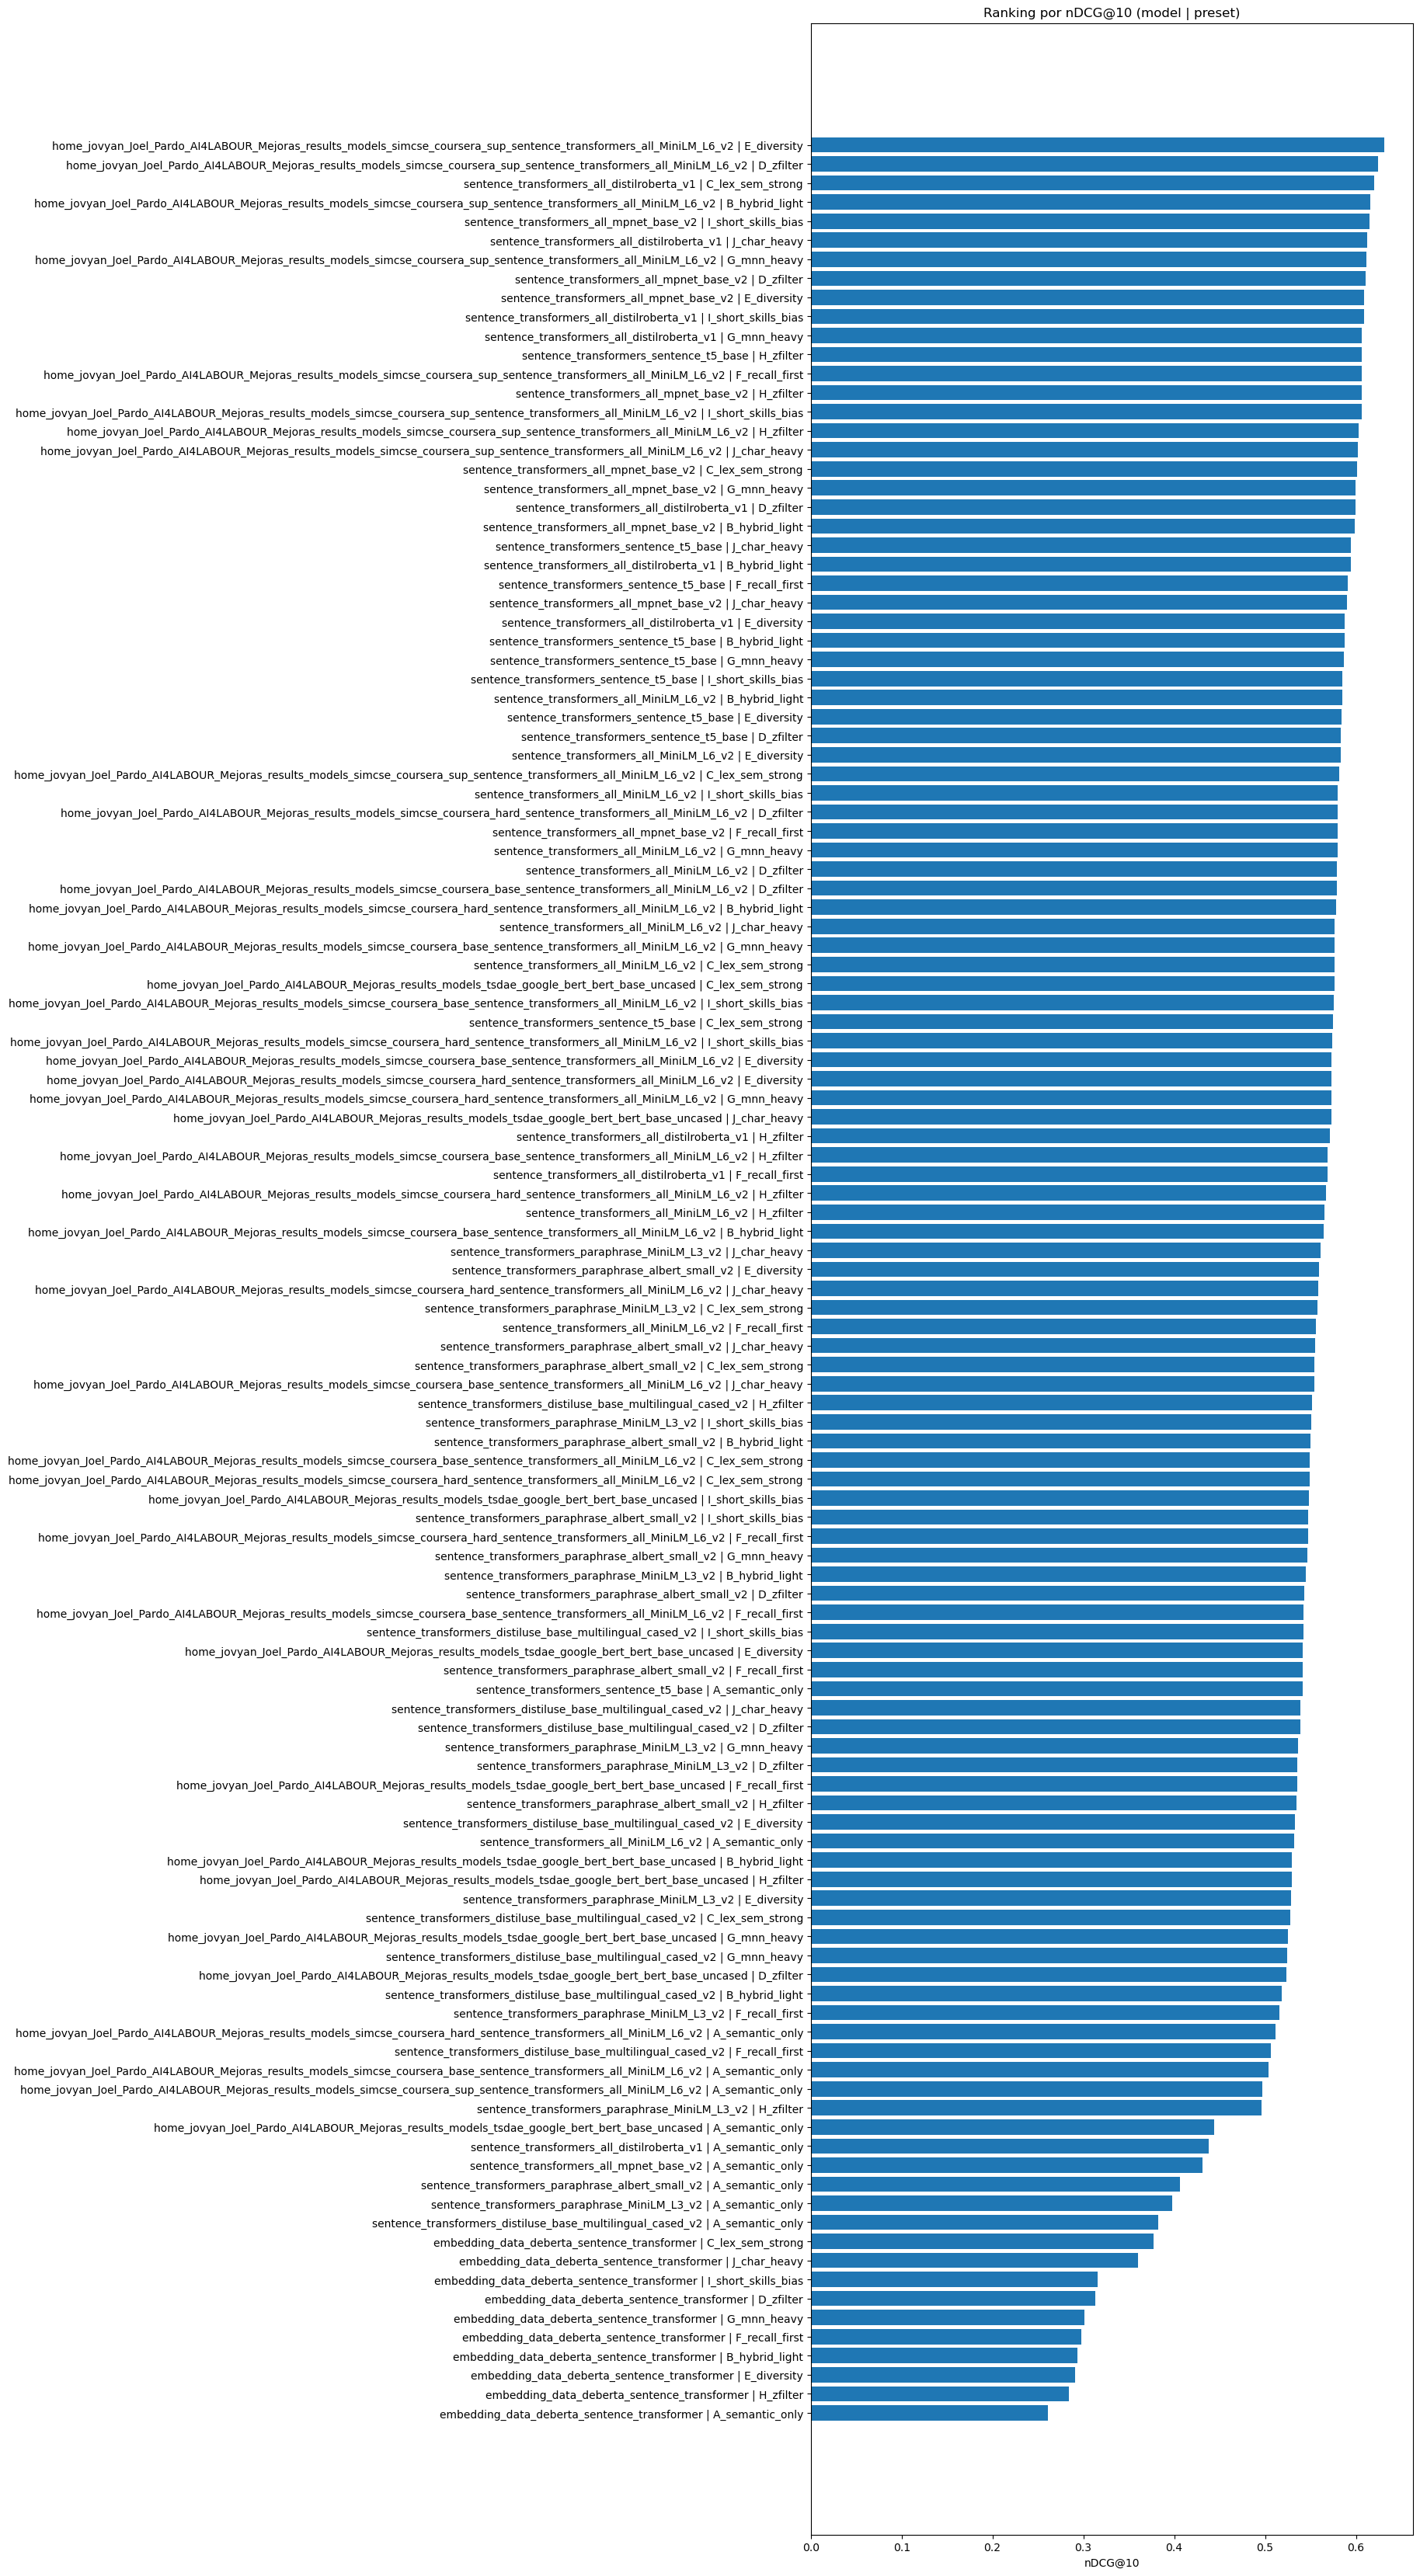

In [132]:
# H1) Ranking de modelos (nDCG@10 y MAP@10)

df10 = rank_sum[rank_sum["k"]==10].copy()
df10["label"] = df10["model"] + " | " + df10["preset"]

# nDCG@10
plt.figure(figsize=(10, max(4, 0.35*len(df10))))
ord_ndcg = df10.sort_values("nDCG@k", ascending=True)
plt.barh(ord_ndcg["label"], ord_ndcg["nDCG@k"])
plt.xlabel("nDCG@10")
plt.title("Ranking por nDCG@10 (model | preset)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "H1_ndcg10_barh.svg", format="svg")
plt.show()


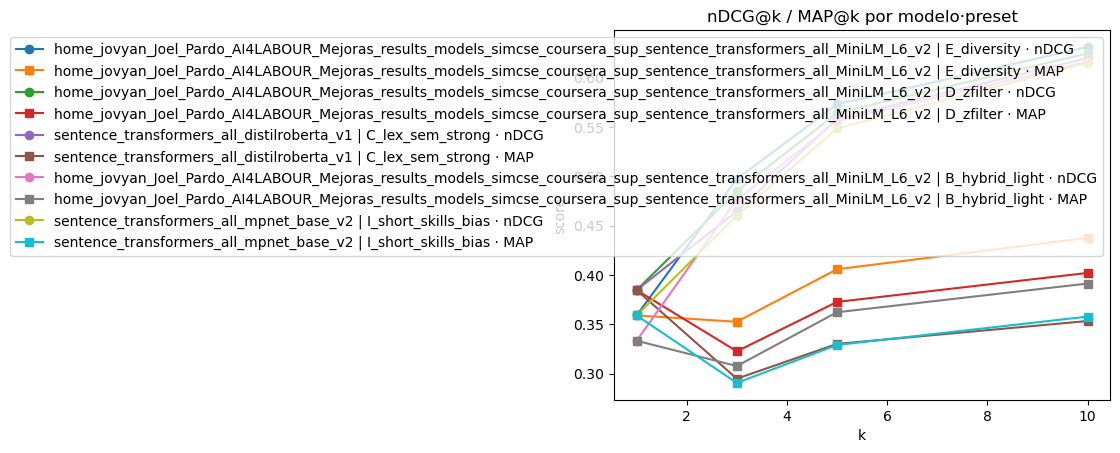

[H1] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H1_curvas_ndcg_map_por_k_dwa.png


In [133]:

# 1) nDCG/MAP vs k
plt.figure()
for (m,p) in top_keys:
    sub = rank_sum[(rank_sum["model"]==m) & (rank_sum["preset"]==p)].sort_values("k")
    plt.plot(sub["k"], sub["nDCG@k"], marker="o", label=f"{m} | {p} · nDCG")
    plt.plot(sub["k"], sub["MAP@k"],  marker="s", label=f"{m} | {p} · MAP")
plt.xlabel("k"); plt.ylabel("score")
plt.title("nDCG@k / MAP@k por modelo·preset")
plt.legend(loc="best")
fig_path = PLOTS_DIR / "H1_curvas_ndcg_map_por_k_dwa.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
print("[H1] Guardado:", fig_path)


/tmp/ipykernel_628/1925496581.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


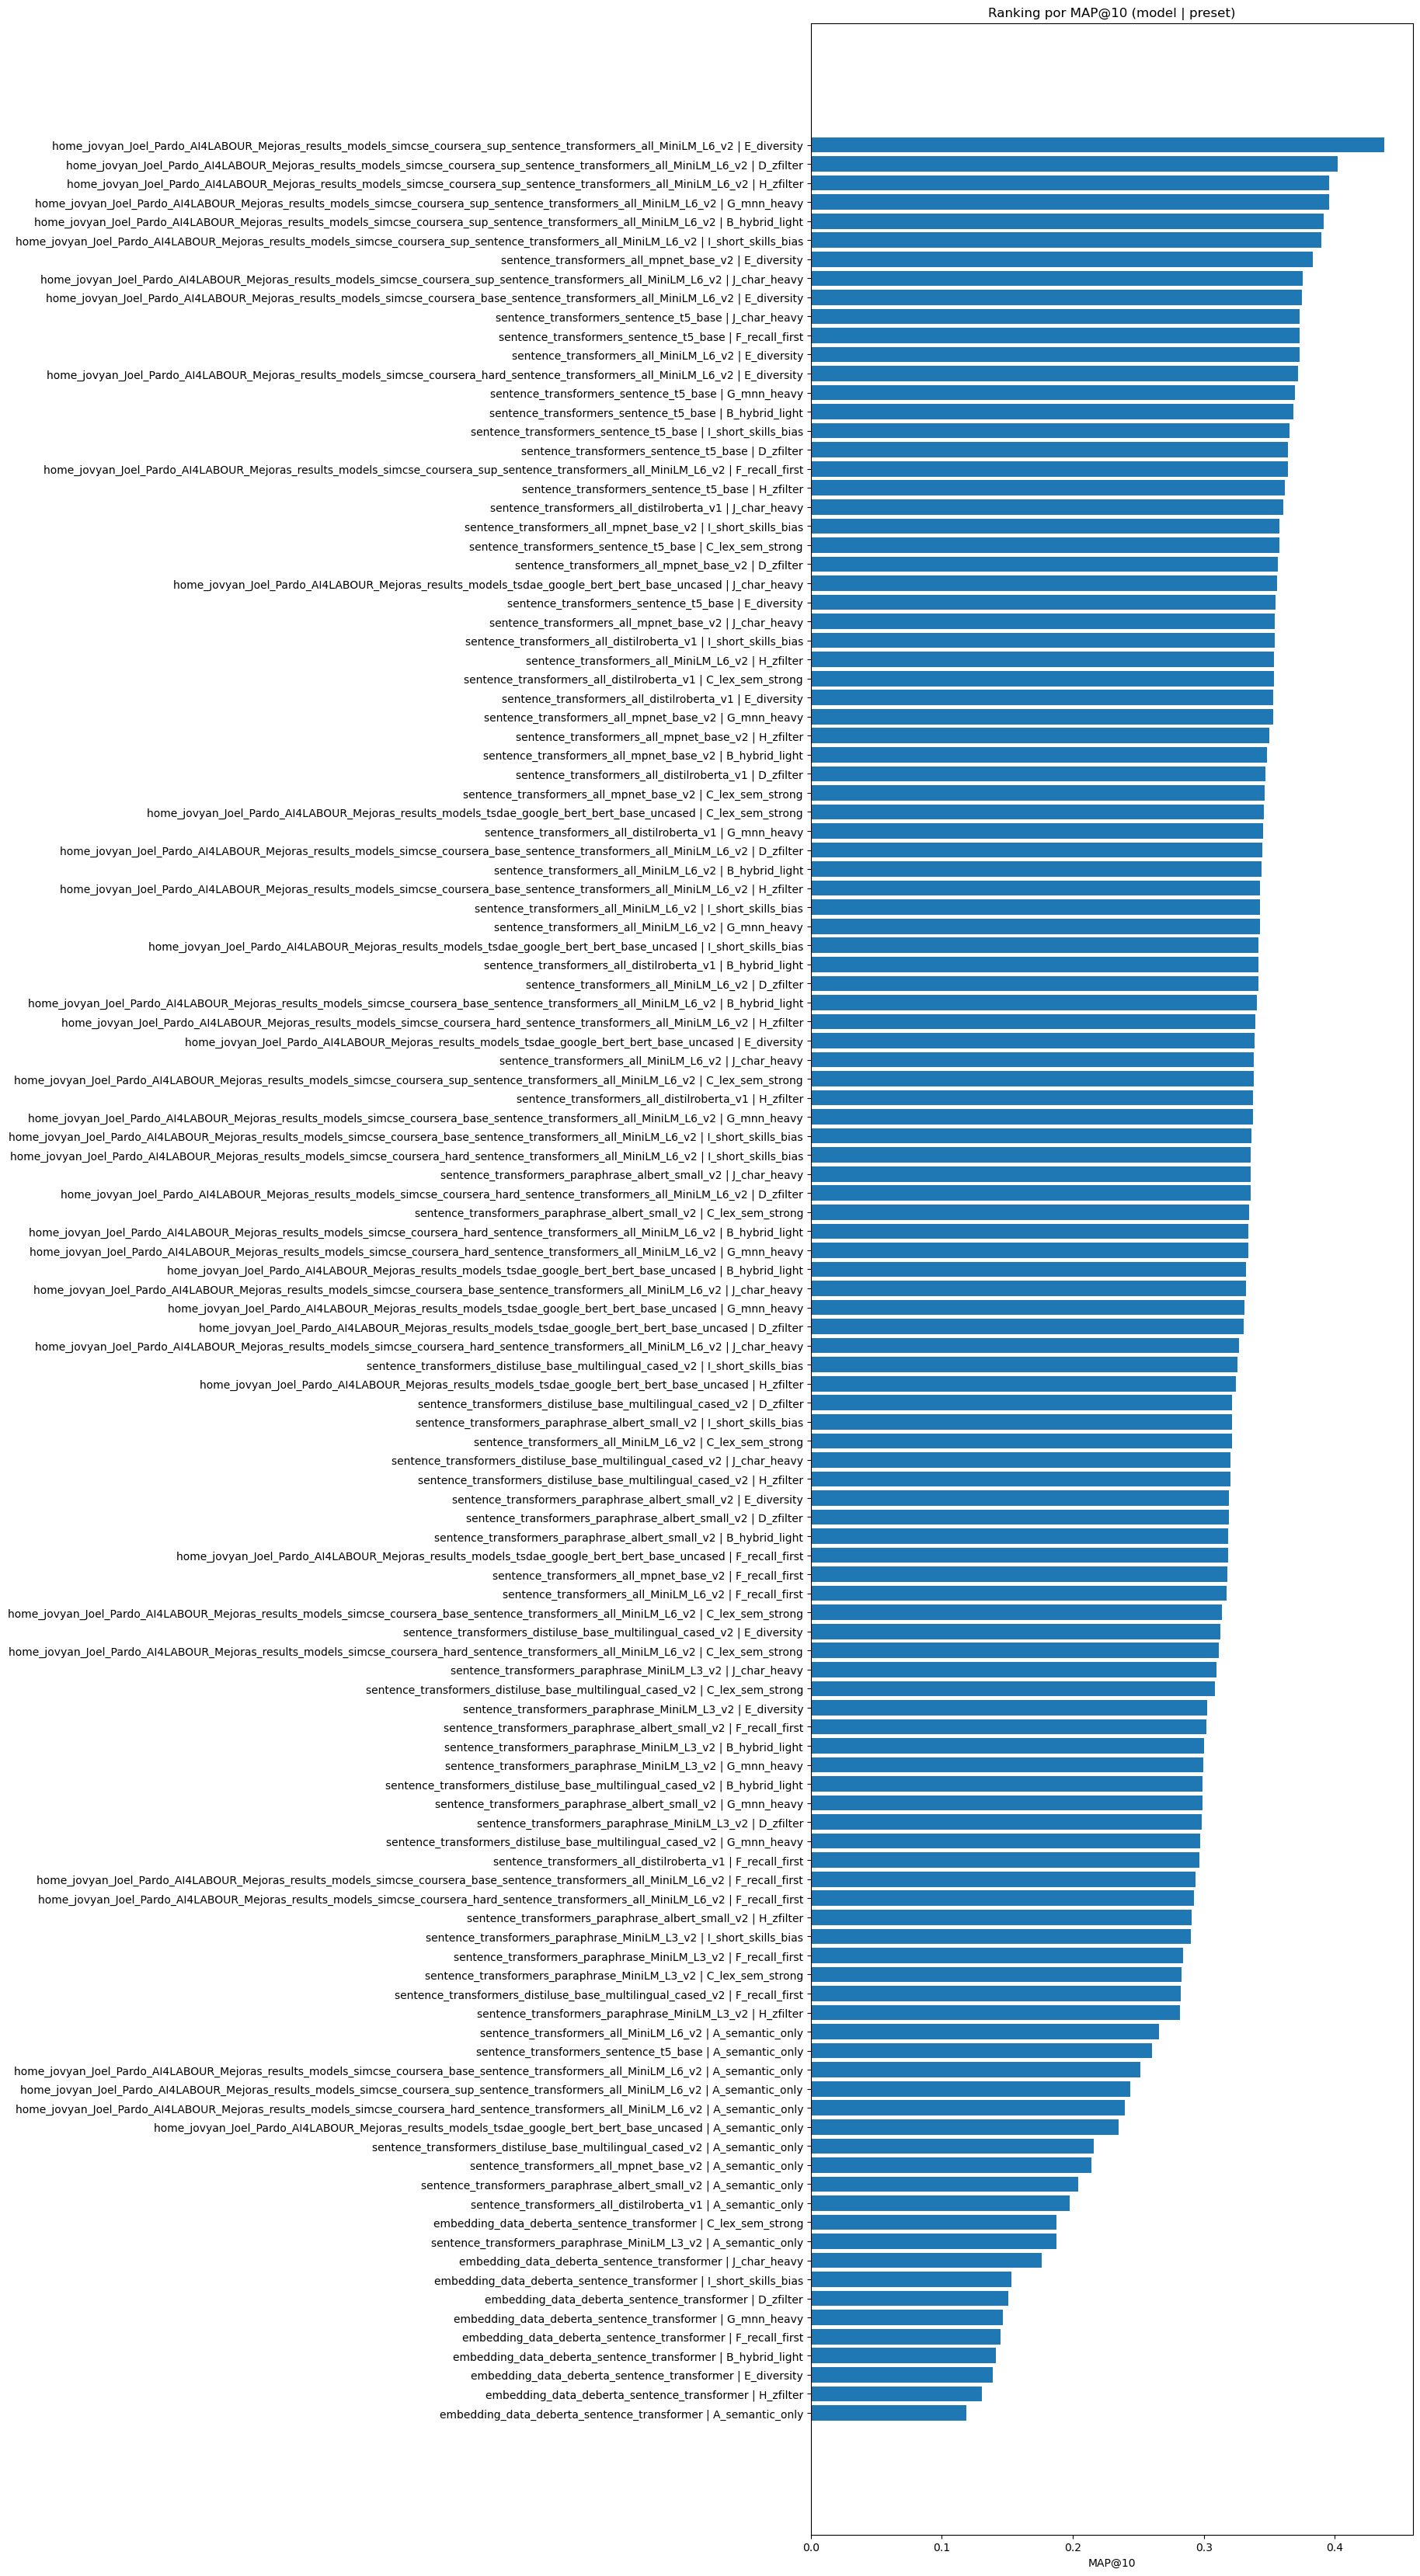

In [134]:

# MAP@10
plt.figure(figsize=(10, max(4, 0.35*len(df10))))
ord_map = df10.sort_values("MAP@k", ascending=True)
plt.barh(ord_map["label"], ord_map["MAP@k"])
plt.xlabel("MAP@10")
plt.title("Ranking por MAP@10 (model | preset)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "H1_map10_barh.svg", format="svg")
plt.show()

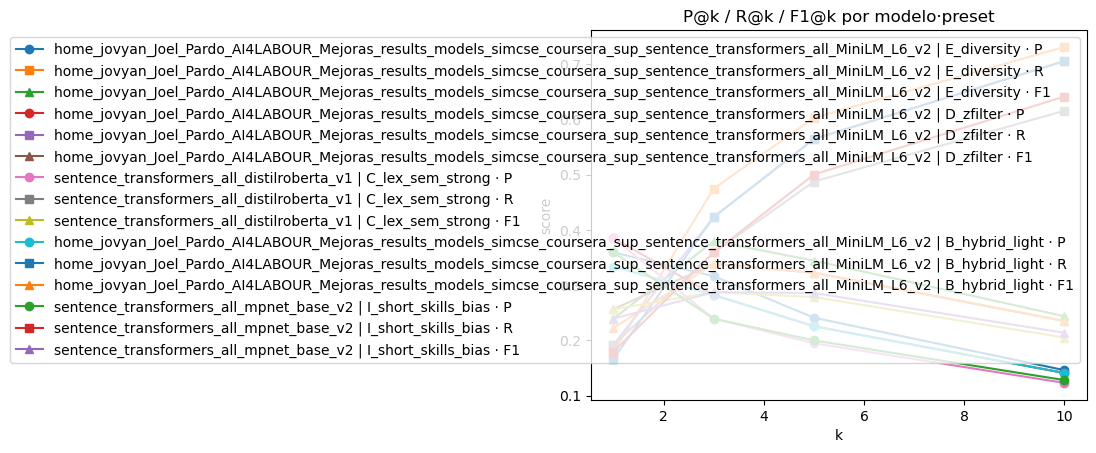

[H1] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H1_curvas_prf_por_k_dwa.png


In [135]:

# 2) P/R/F1 vs k
plt.figure()
for (m,p) in top_keys:
    sub = rank_sum[(rank_sum["model"]==m) & (rank_sum["preset"]==p)].sort_values("k")
    plt.plot(sub["k"], sub["P@k"],  marker="o", label=f"{m} | {p} · P")
    plt.plot(sub["k"], sub["R@k"],  marker="s", label=f"{m} | {p} · R")
    plt.plot(sub["k"], sub["F1@k"], marker="^", label=f"{m} | {p} · F1")
plt.xlabel("k"); plt.ylabel("score")
plt.title("P@k / R@k / F1@k por modelo·preset")
plt.legend(loc="best")
fig_path = PLOTS_DIR / "H1_curvas_prf_por_k_dwa.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
print("[H1] Guardado:", fig_path)


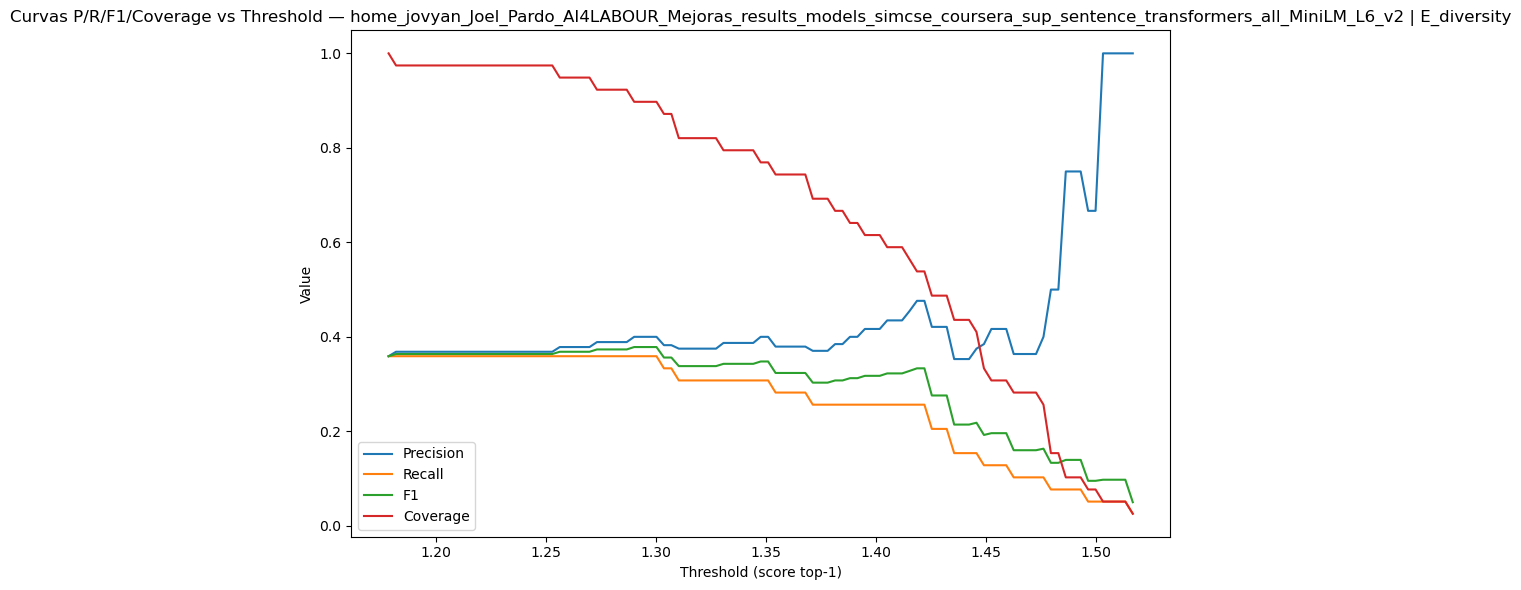

In [136]:
# H2) Curvas Precision/Recall/F1/Coverage vs Threshold (ganador)
if df_sweep is not None and not df_sweep.empty:
    plt.figure(figsize=(9,6))
    plt.plot(df_sweep["thr"], df_sweep["precision"], label="Precision")
    plt.plot(df_sweep["thr"], df_sweep["recall"], label="Recall")
    plt.plot(df_sweep["thr"], df_sweep["f1"], label="F1")
    plt.plot(df_sweep["thr"], df_sweep["coverage"], label="Coverage")
    plt.xlabel("Threshold (score top-1)")
    plt.ylabel("Value")
    plt.title(f"Curvas P/R/F1/Coverage vs Threshold — {w_model} | {w_preset}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "H2_threshold_curves_winner.svg", format="svg")
    plt.show()
else:
    print("[H2] No hay threshold_sweep para el ganador.")


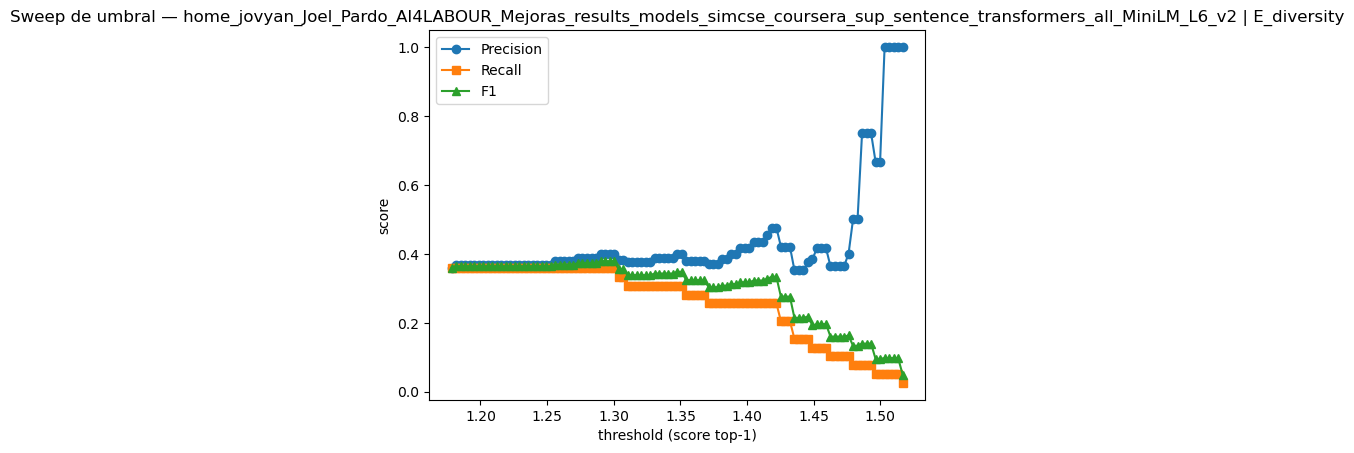

[H2] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H2_winner_sweep_thr_prf_dwa.png


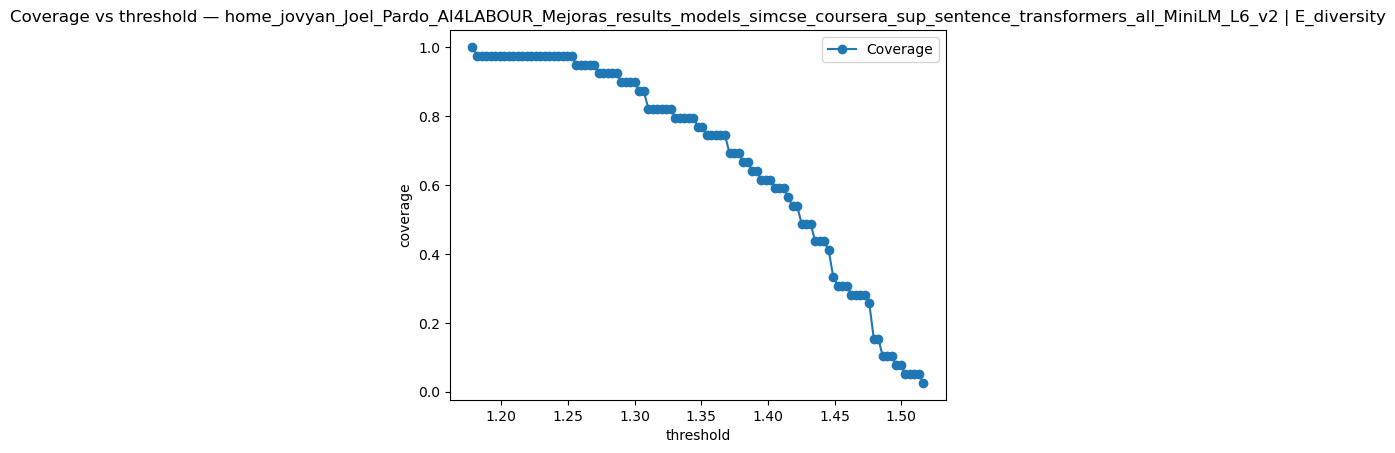

[H2] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H2_winner_sweep_thr_coverage_dwa.png


In [137]:
# === H2 · Sweep de umbral (ganador) ===
if not df_sweep.empty:
    sw = df_sweep[(df_sweep["model"]==winner["model"]) & (df_sweep["preset"]==winner["preset"])].copy()
    sw = sw.sort_values("thr")

    # PRF
    plt.figure()
    plt.plot(sw["thr"], sw["precision"], marker="o", label="Precision")
    plt.plot(sw["thr"], sw["recall"],    marker="s", label="Recall")
    plt.plot(sw["thr"], sw["f1"],        marker="^", label="F1")
    plt.xlabel("threshold (score top-1)"); plt.ylabel("score")
    plt.title(f"Sweep de umbral — {winner['model']} | {winner['preset']}")
    plt.legend(loc="best")
    fig_path = PLOTS_DIR / "H2_winner_sweep_thr_prf_dwa.png"
    plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
    print("[H2] Guardado:", fig_path)

    # Coverage
    if "coverage" in sw.columns:
        plt.figure()
        plt.plot(sw["thr"], sw["coverage"], marker="o", label="Coverage")
        plt.xlabel("threshold"); plt.ylabel("coverage")
        plt.title(f"Coverage vs threshold — {winner['model']} | {winner['preset']}")
        plt.legend(loc="best")
        fig_path = PLOTS_DIR / "H2_winner_sweep_thr_coverage_dwa.png"
        plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
        print("[H2] Guardado:", fig_path)
else:
    print("[H2] No hay threshold_sweep para el ganador.")


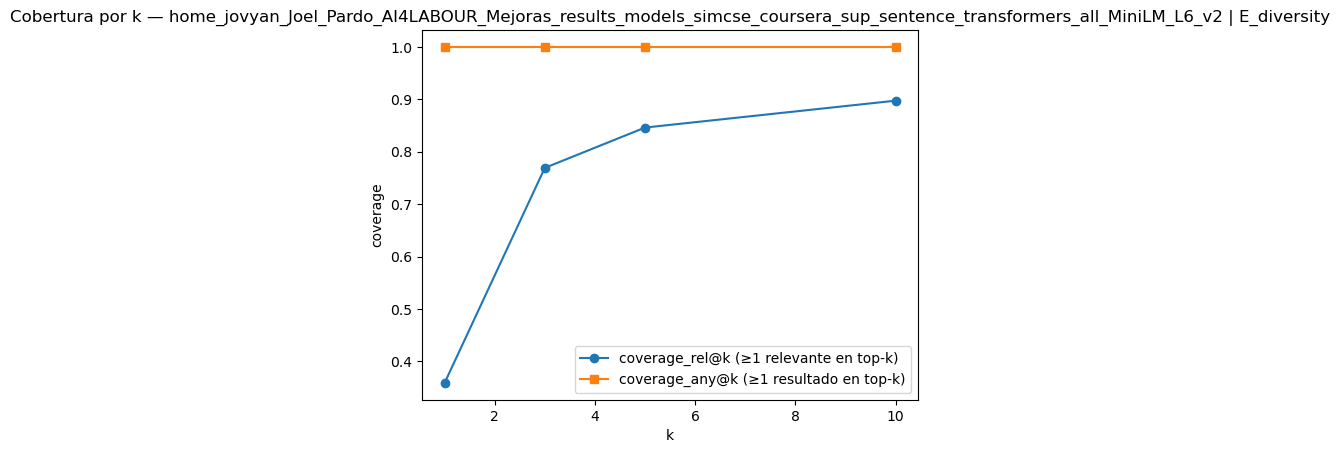

[H3] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H3_winner_cobertura_por_k_dwa.png


In [138]:
# === H3 · Cobertura por k del ganador ===
sub = rank_sum[(rank_sum["model"]==winner["model"]) & (rank_sum["preset"]==winner["preset"])].sort_values("k")
plt.figure()
if "coverage_rel@k" in sub.columns:
    plt.plot(sub["k"], sub["coverage_rel@k"], marker="o", label="coverage_rel@k (≥1 relevante en top-k)")
if "coverage_any@k" in sub.columns:
    plt.plot(sub["k"], sub["coverage_any@k"], marker="s", label="coverage_any@k (≥1 resultado en top-k)")
plt.xlabel("k"); plt.ylabel("coverage")
plt.title(f"Cobertura por k — {winner['model']} | {winner['preset']}")
plt.legend(loc="best")
fig_path = PLOTS_DIR / "H3_winner_cobertura_por_k_dwa.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
print("[H3] Guardado:", fig_path)


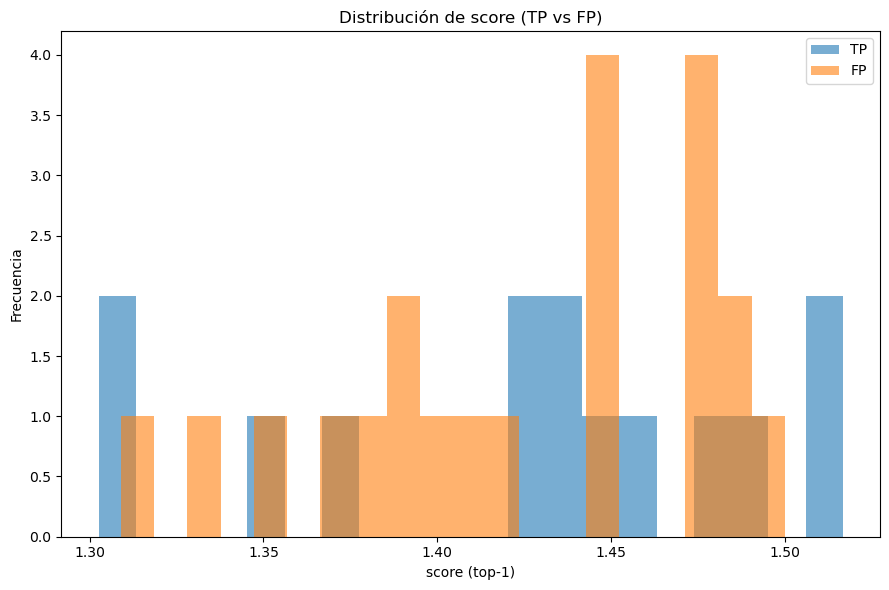

In [139]:
# H3) Histogramas del score (TP vs FP) en top-1
if not df_tp.empty or not df_fp.empty:
    plt.figure(figsize=(9,6))
    if not df_tp.empty:
        plt.hist(df_tp["score"].values, bins=20, alpha=0.6, label="TP")
    if not df_fp.empty:
        plt.hist(df_fp["score"].values, bins=20, alpha=0.6, label="FP")
    plt.xlabel("score (top-1)")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de score (TP vs FP)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "H3_score_hist_tp_fp.svg", format="svg")
    plt.show()
else:
    print("[H3] No hay TP/FP para graficar.")


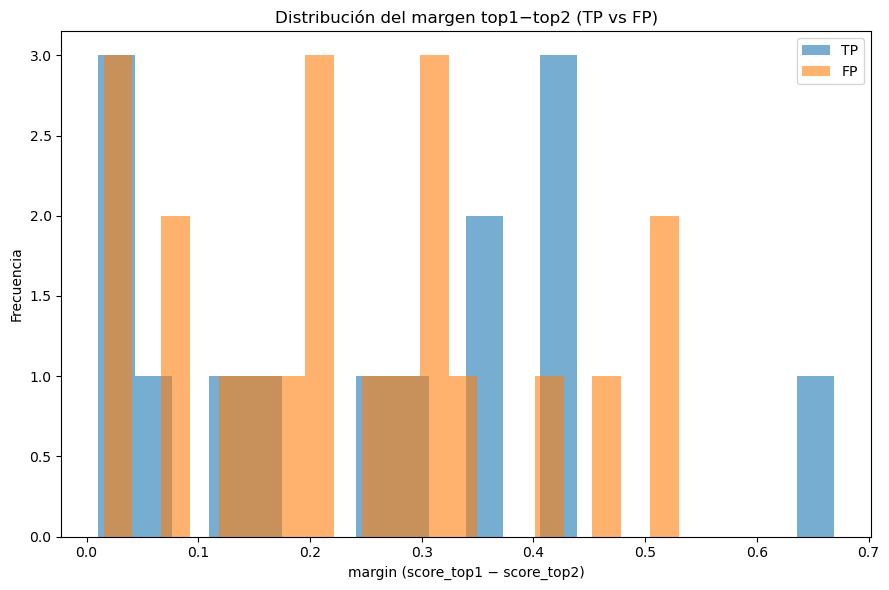

In [140]:
# H4) Margen top1 − top2 (TP vs FP)
if not df_tp.empty or not df_fp.empty:
    plt.figure(figsize=(9,6))
    if not df_tp.empty:
        plt.hist(df_tp["margin_top1_top2"].values, bins=20, alpha=0.6, label="TP")
    if not df_fp.empty:
        plt.hist(df_fp["margin_top1_top2"].values, bins=20, alpha=0.6, label="FP")
    plt.xlabel("margin (score_top1 − score_top2)")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del margen top1−top2 (TP vs FP)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "H4_margin_hist_tp_fp.svg", format="svg")
    plt.show()
else:
    print("[H4] No hay TP/FP para graficar márgenes.")


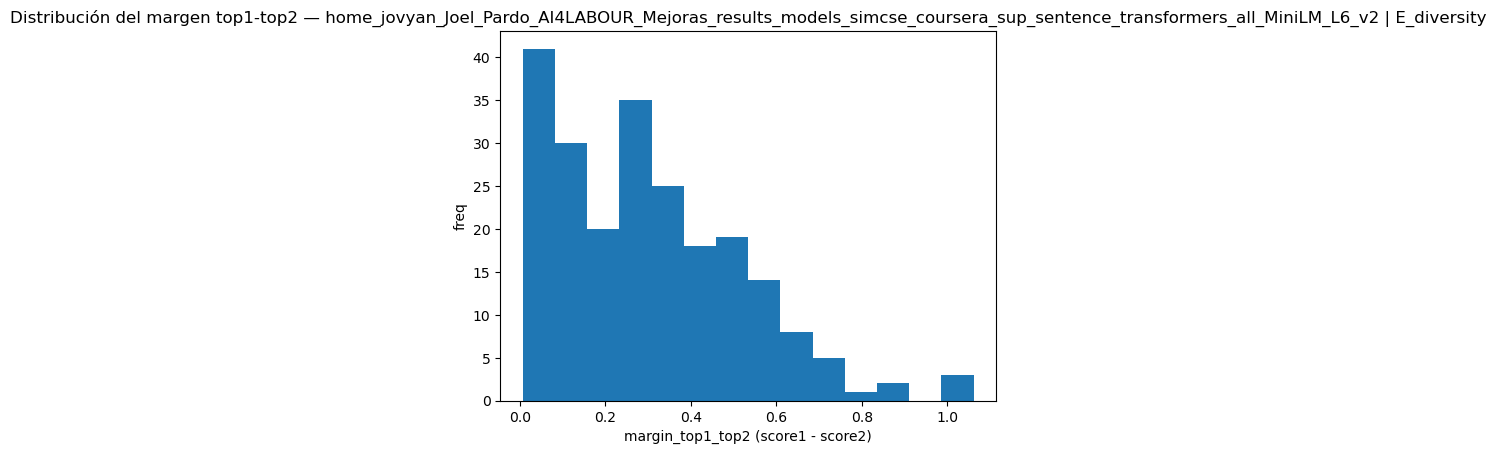

[H4] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H4_winner_top1_margin_hist_dwa.png


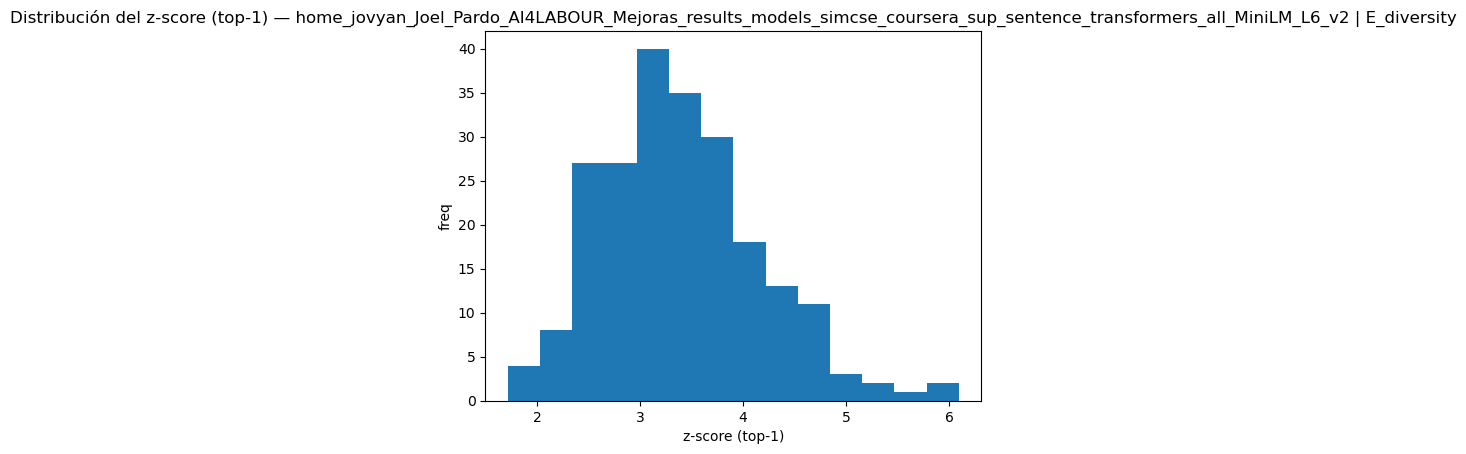

[H4] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H4_winner_top1_z_hist_dwa.png


In [141]:
# === H4 · Histos del top-1: margen y z-score ===
assert not df_long.empty, "Falta neighbors_all_long_* (ejecuta E)."

g = df_long[(df_long["model"]==winner["model"]) & (df_long["preset"]==winner["preset"])].copy()
g = g.sort_values(["q_idx","rank"])
top1 = g.drop_duplicates("q_idx", keep="first").copy()
top2 = g[g["rank"]==2][["q_idx","score"]].rename(columns={"score":"score_top2"})
top1 = top1.merge(top2, on="q_idx", how="left")
top1["margin_top1_top2"] = top1["score"] - top1["score_top2"]

# Histograma margen
plt.figure()
vals = top1["margin_top1_top2"].dropna().values
bins = max(10, int(np.sqrt(len(vals)))) if len(vals)>0 else 10
plt.hist(vals, bins=bins)
plt.xlabel("margin_top1_top2 (score1 - score2)"); plt.ylabel("freq")
plt.title(f"Distribución del margen top1-top2 — {winner['model']} | {winner['preset']}")
fig_path = PLOTS_DIR / "H4_winner_top1_margin_hist_dwa.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
print("[H4] Guardado:", fig_path)

# Histograma z-score
plt.figure()
vals = top1["z"].dropna().values
bins = max(10, int(np.sqrt(len(vals)))) if len(vals)>0 else 10
plt.hist(vals, bins=bins)
plt.xlabel("z-score (top-1)"); plt.ylabel("freq")
plt.title(f"Distribución del z-score (top-1) — {winner['model']} | {winner['preset']}")
fig_path = PLOTS_DIR / "H4_winner_top1_z_hist_dwa.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
print("[H4] Guardado:", fig_path)


/tmp/ipykernel_628/4200554634.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


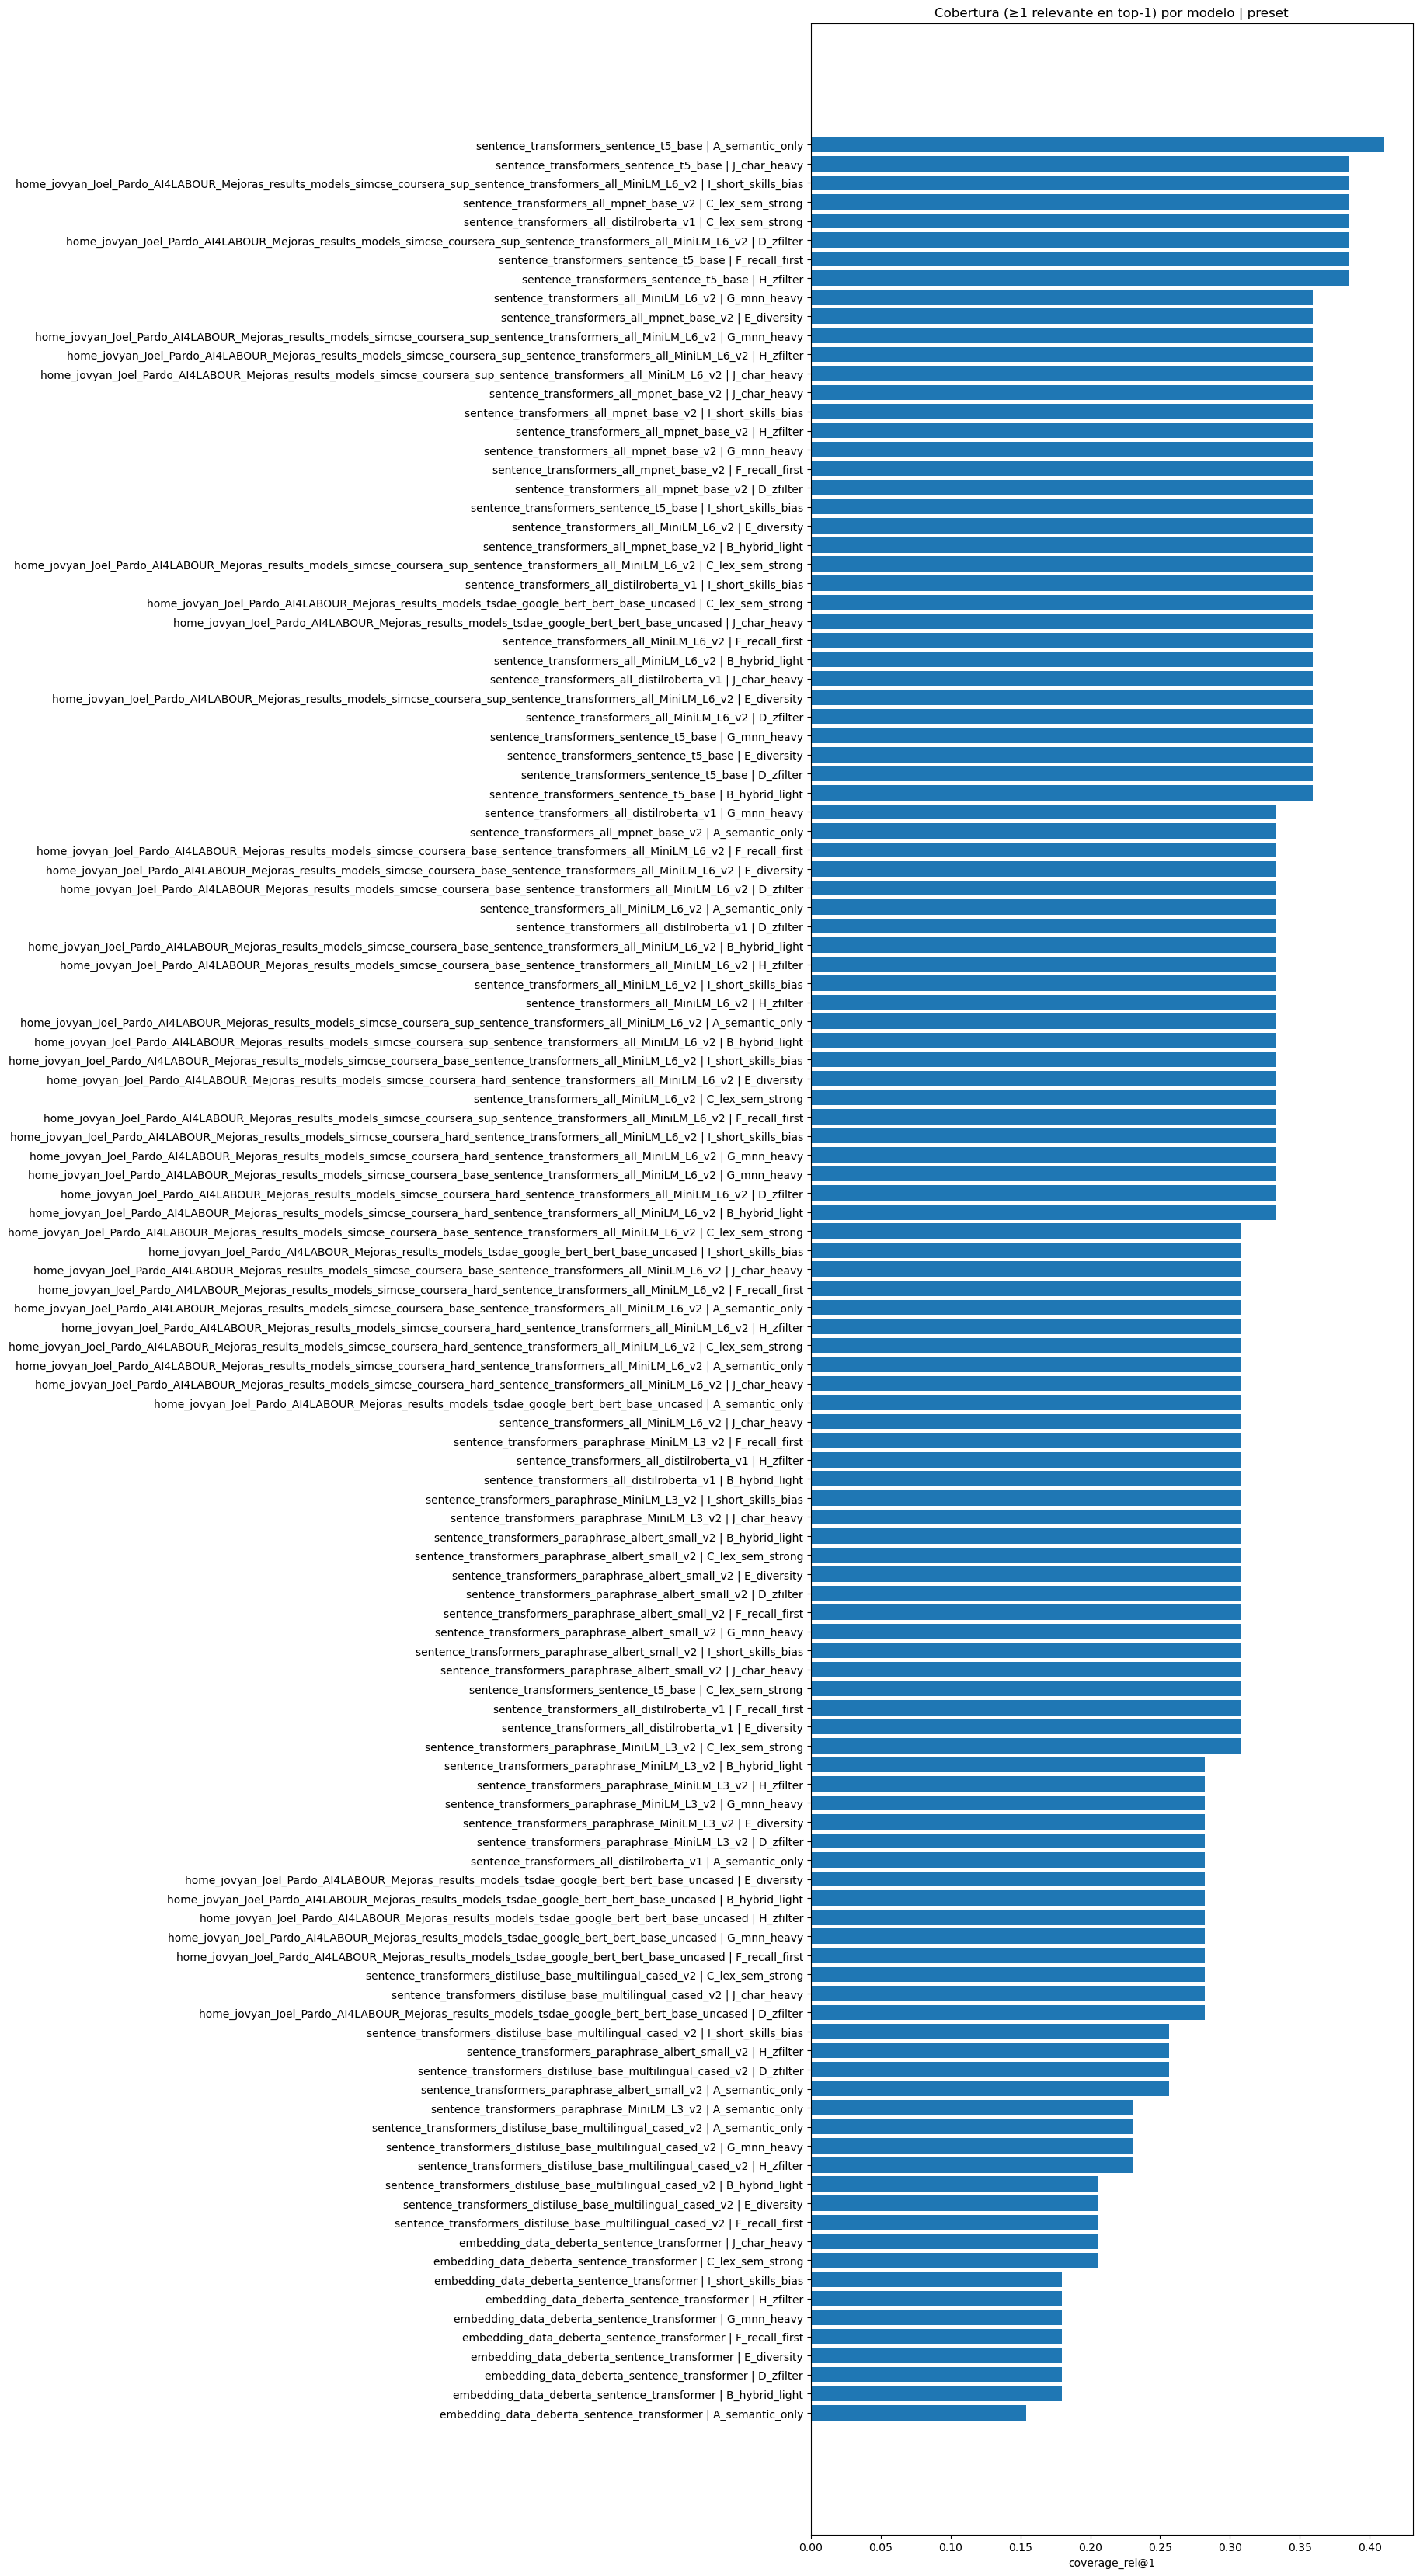

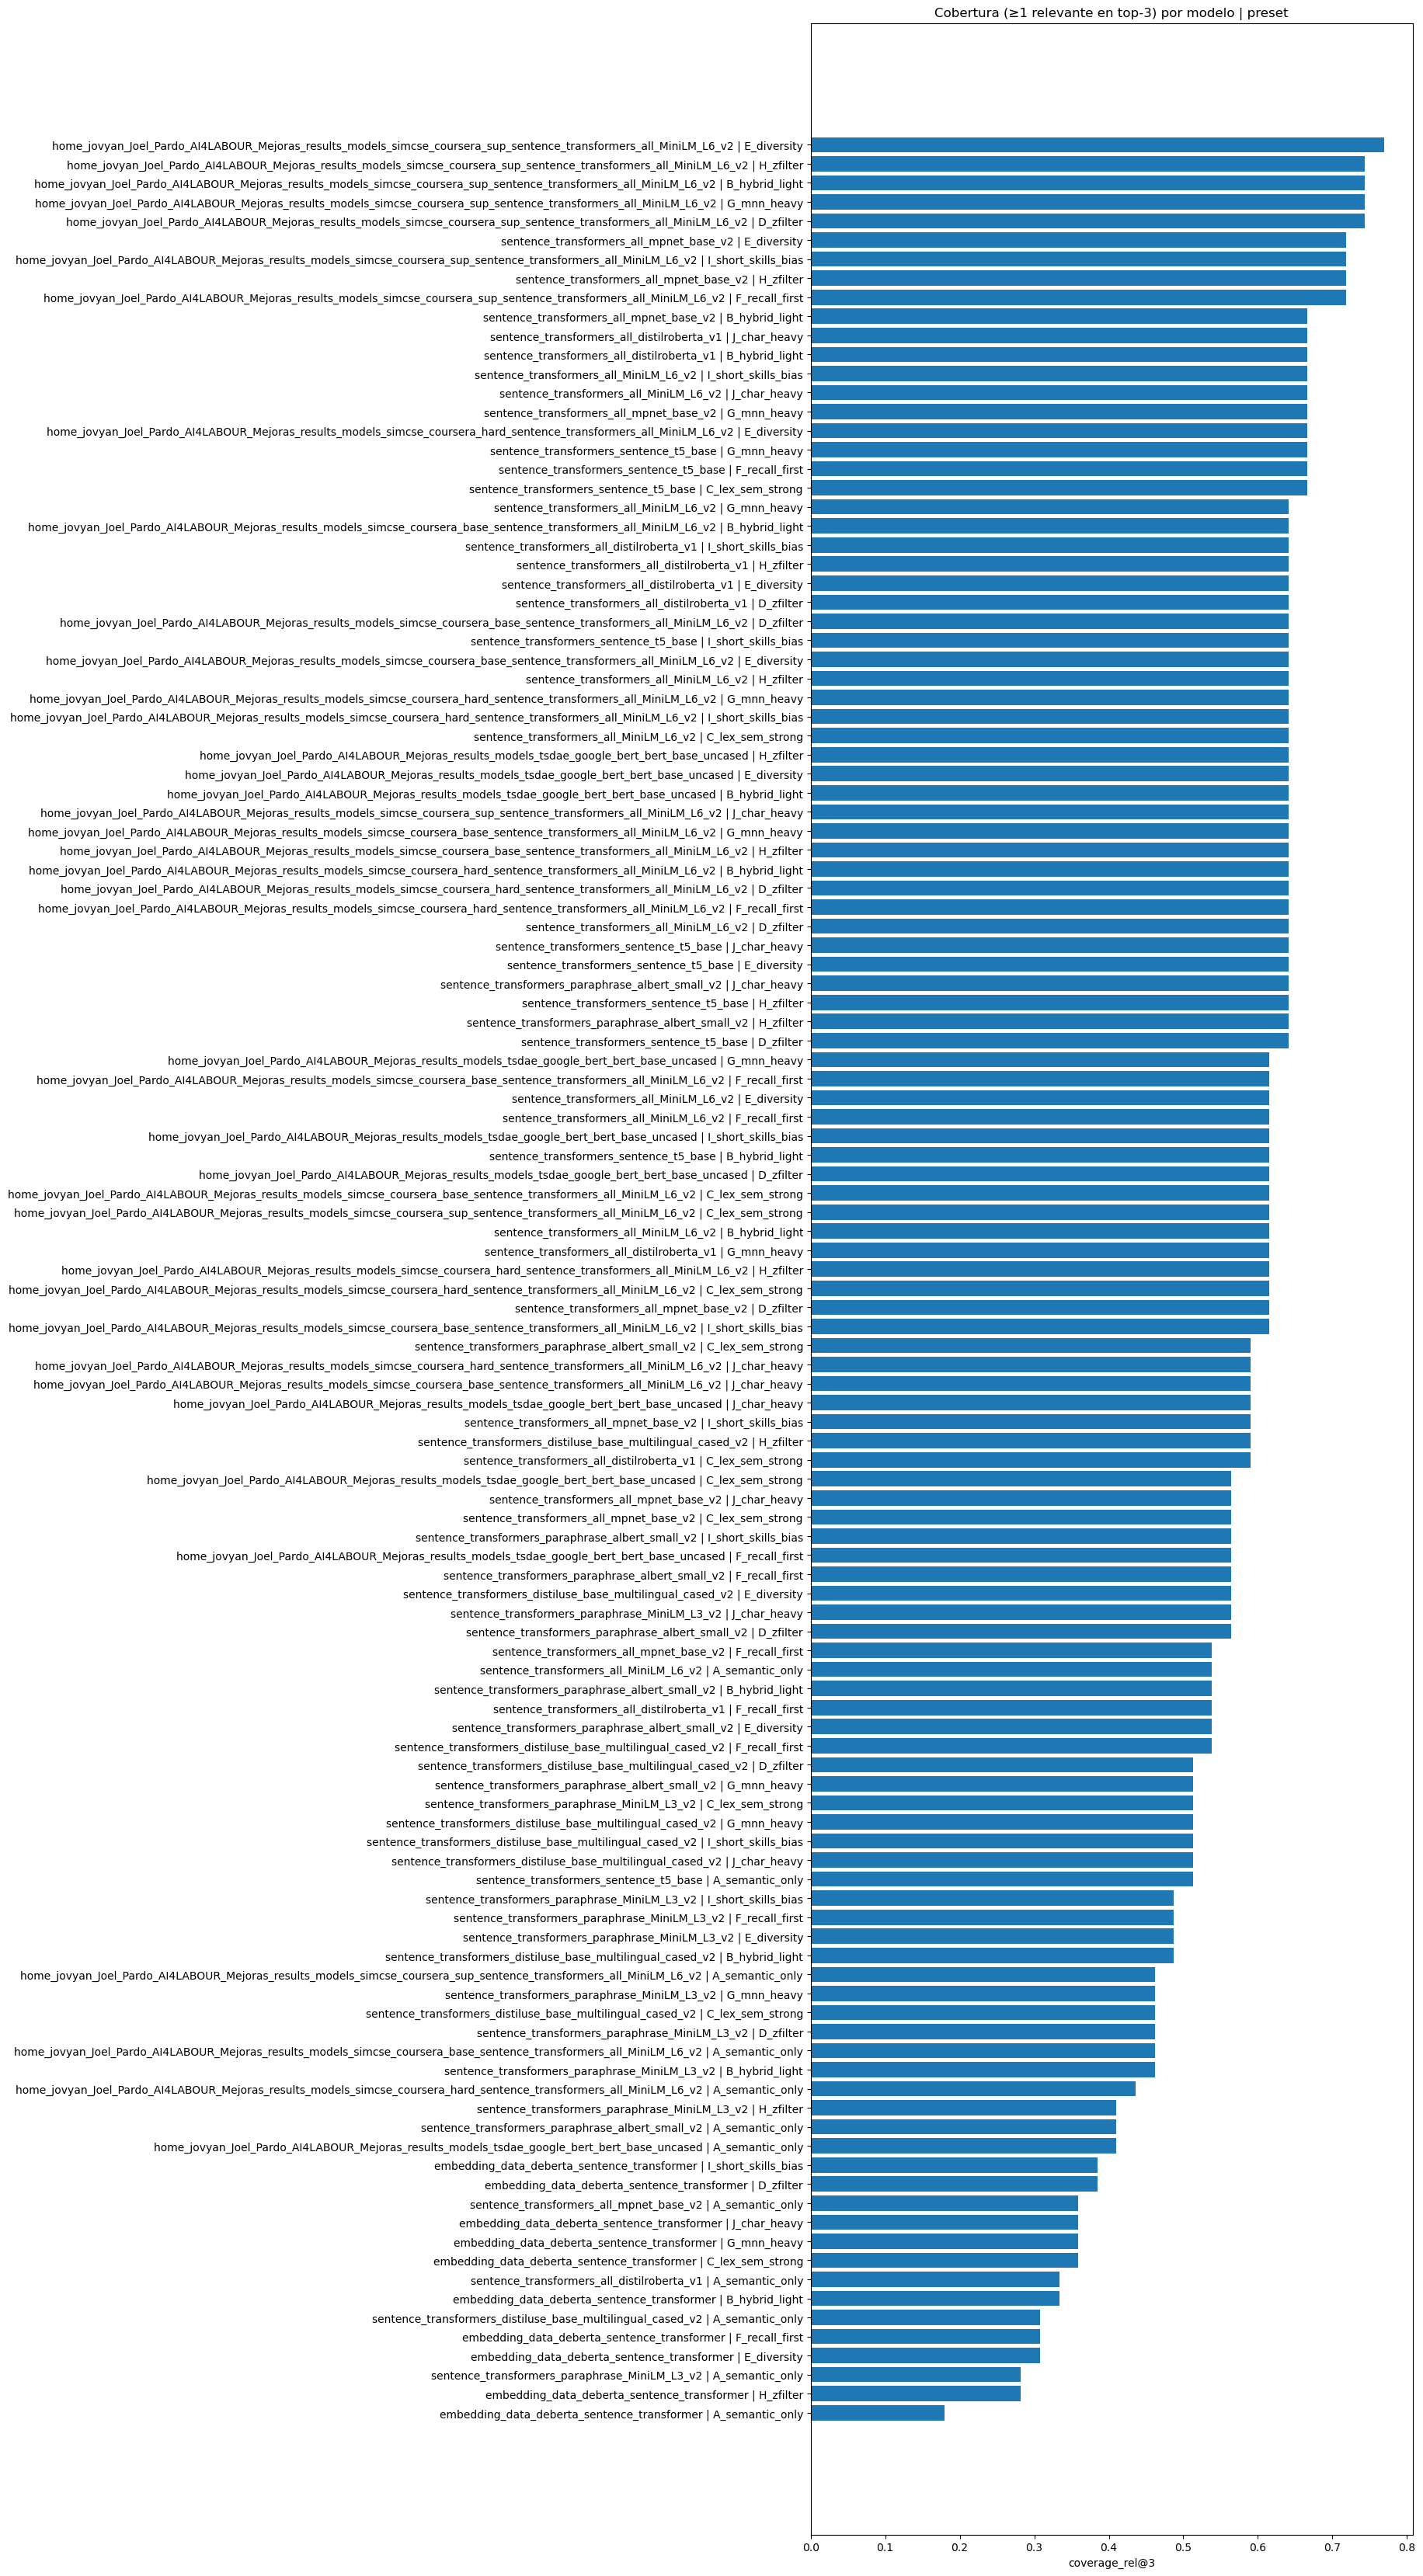

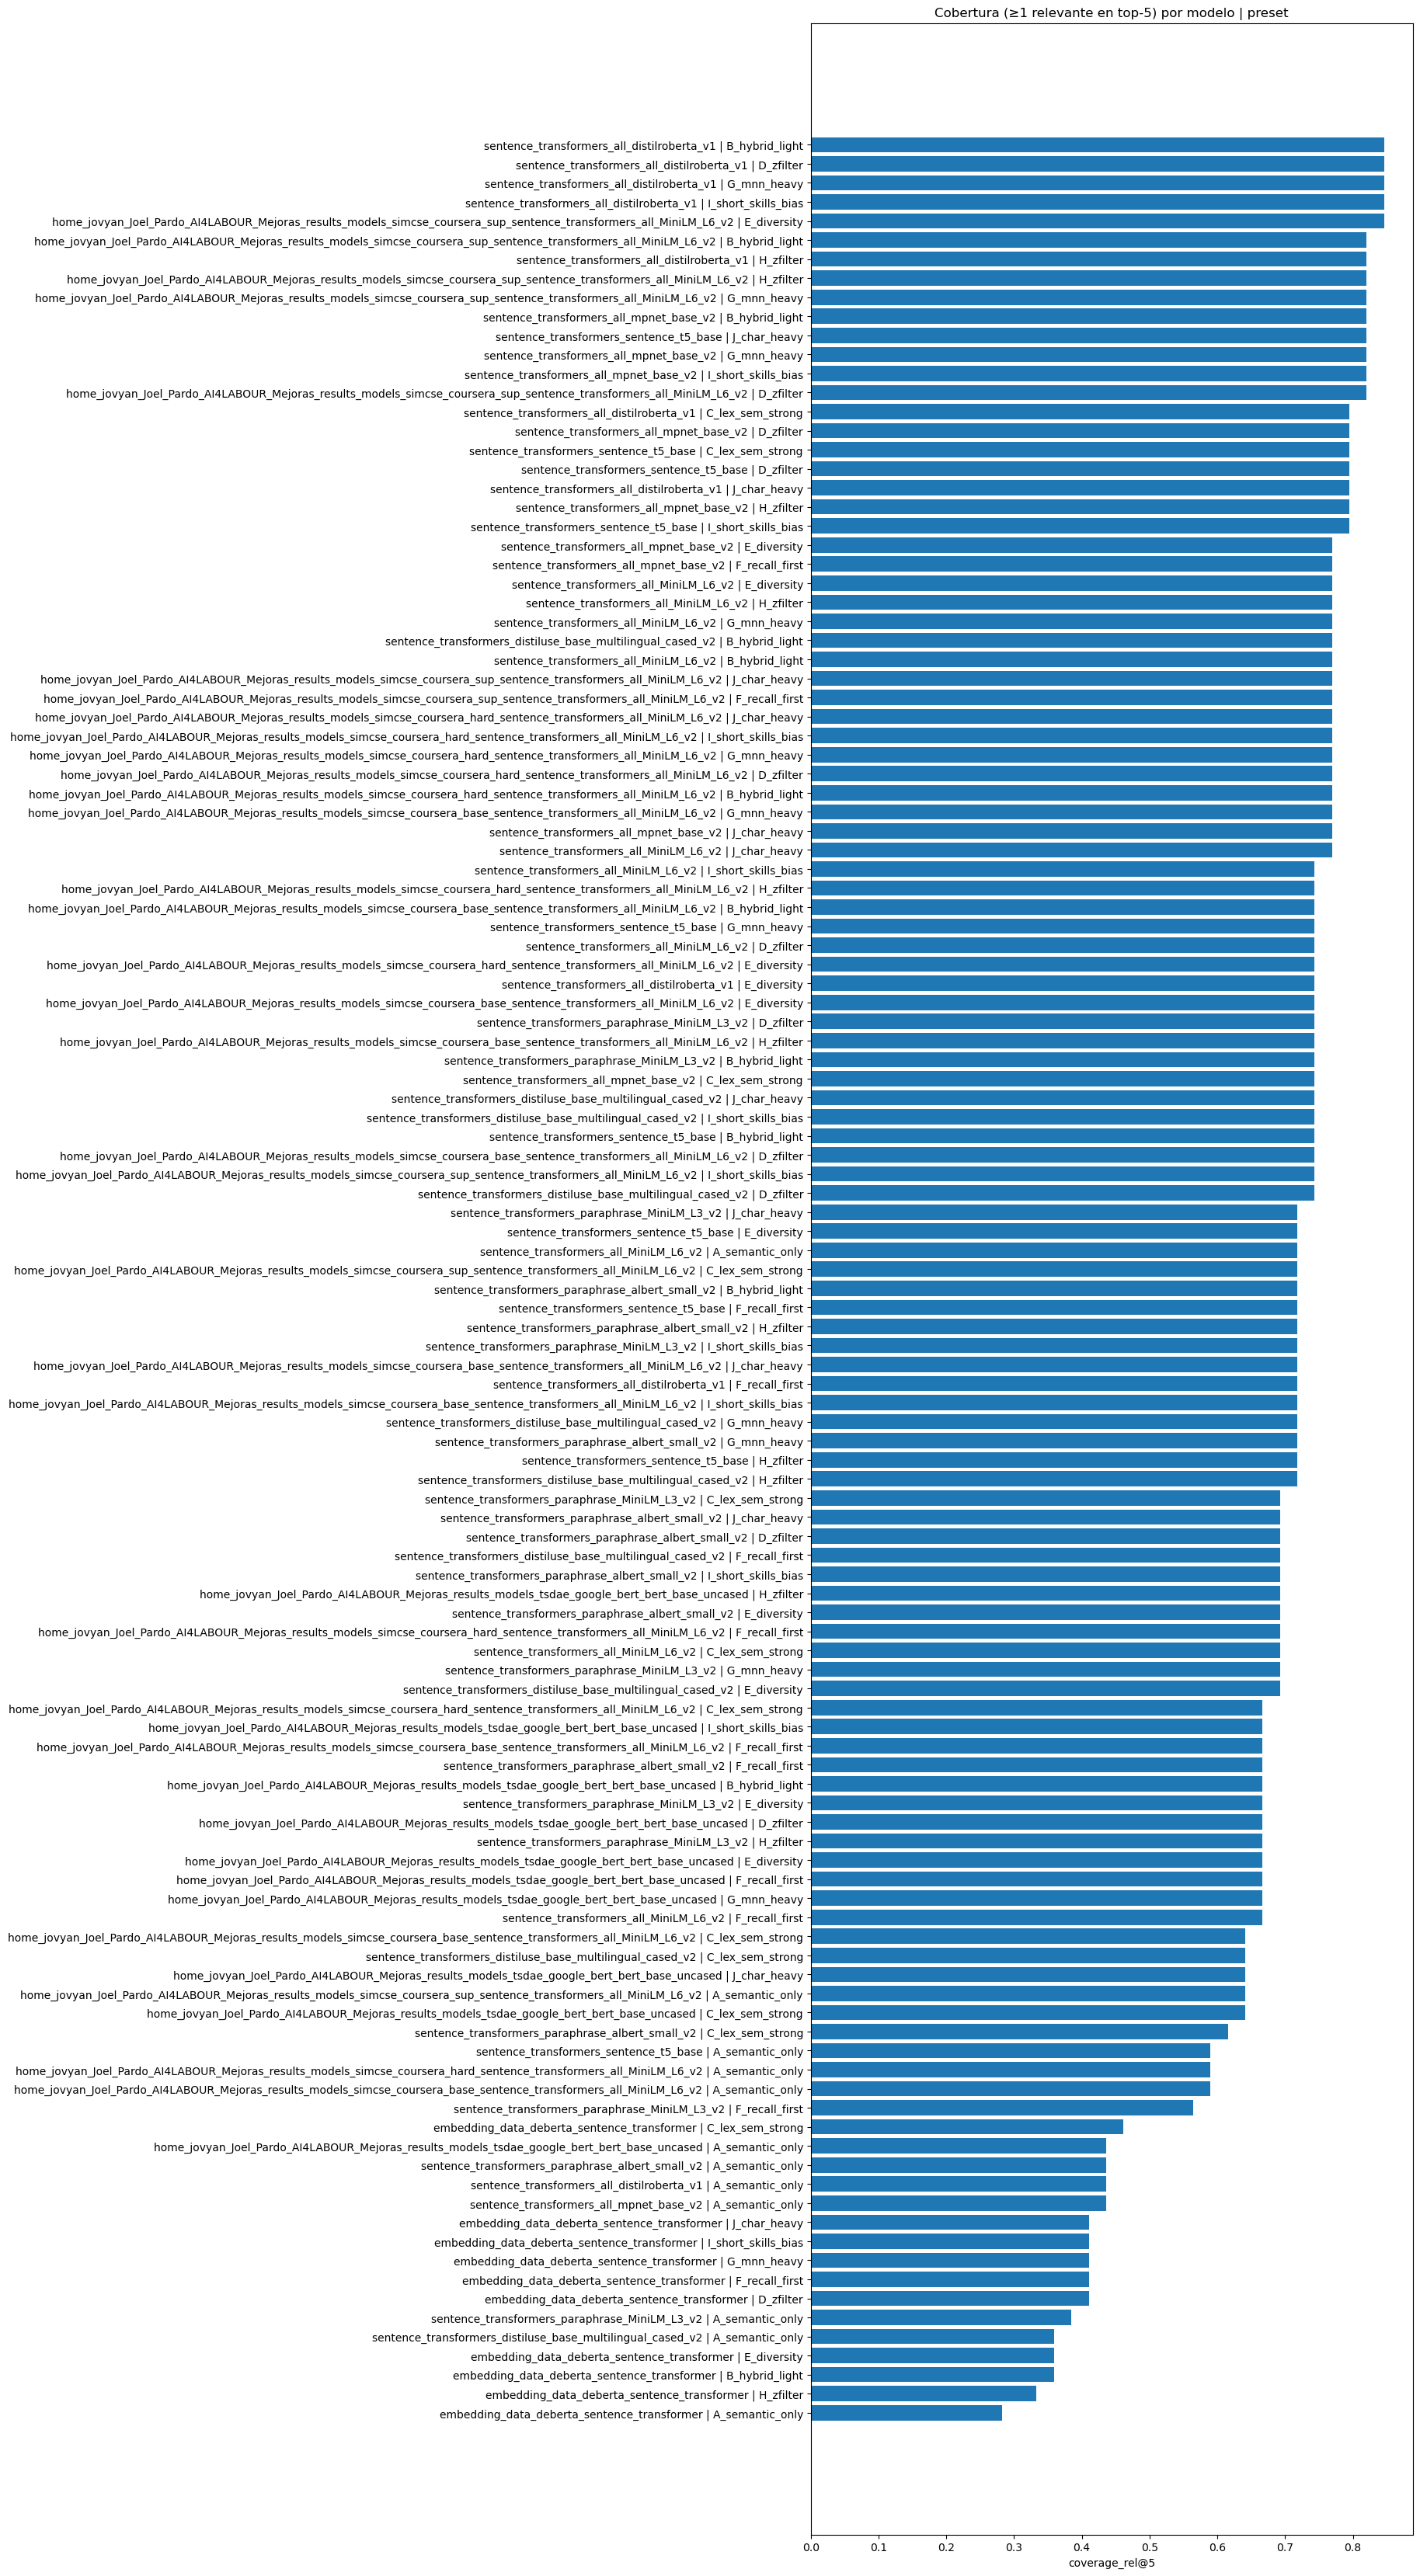

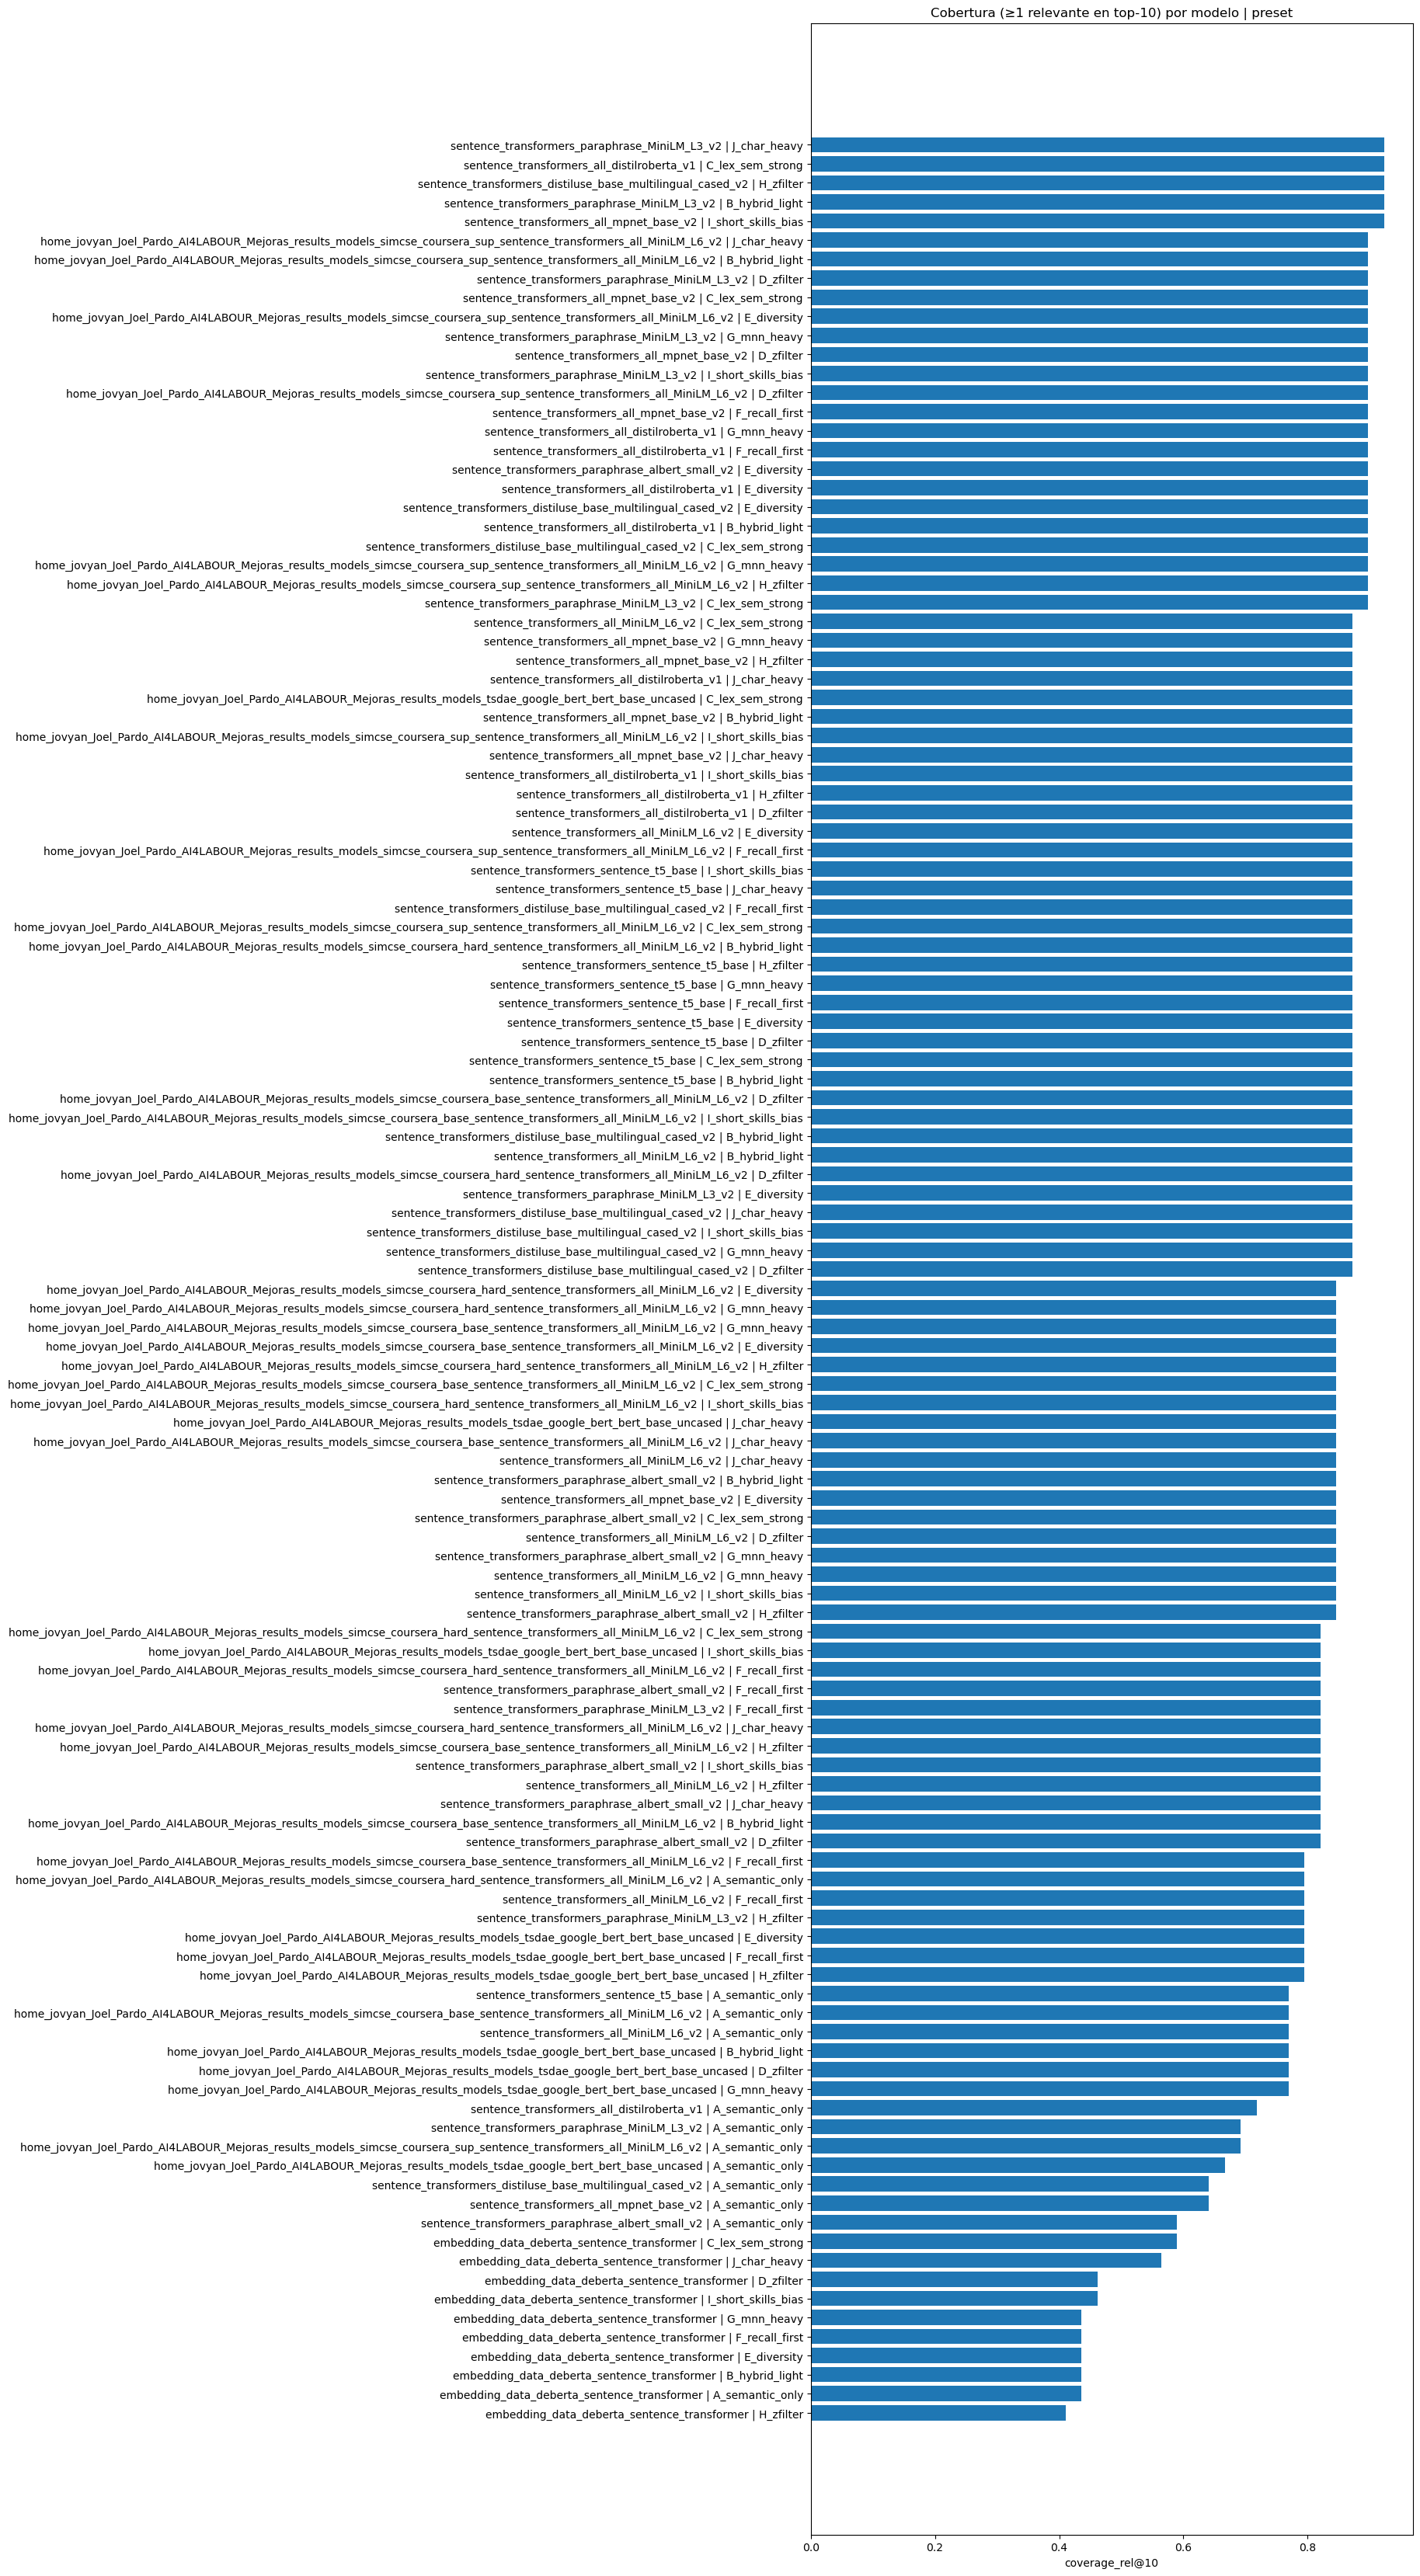

In [142]:
# H5) Cobertura comparada por k (coverage_rel@k)
# Para una vista rápida de cobertura relevante por k
cov_piv = (rank_sum
           .pivot_table(index=["model","preset"], columns="k", values="coverage_rel@k")
           .reset_index())

for k in sorted(rank_sum["k"].unique()):
    col = k
    if col not in cov_piv.columns: 
        continue
    plt.figure(figsize=(10, max(4, 0.35*len(cov_piv))))
    labels = cov_piv["model"] + " | " + cov_piv["preset"]
    vals = cov_piv[col].fillna(0.0).values
    order = np.argsort(vals)
    plt.barh(labels.iloc[order], vals[order])
    plt.xlabel(f"coverage_rel@{k}")
    plt.title(f"Cobertura (≥1 relevante en top-{k}) por modelo | preset")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"H5_coverage_rel_at{k}.svg", format="svg")
    plt.show()


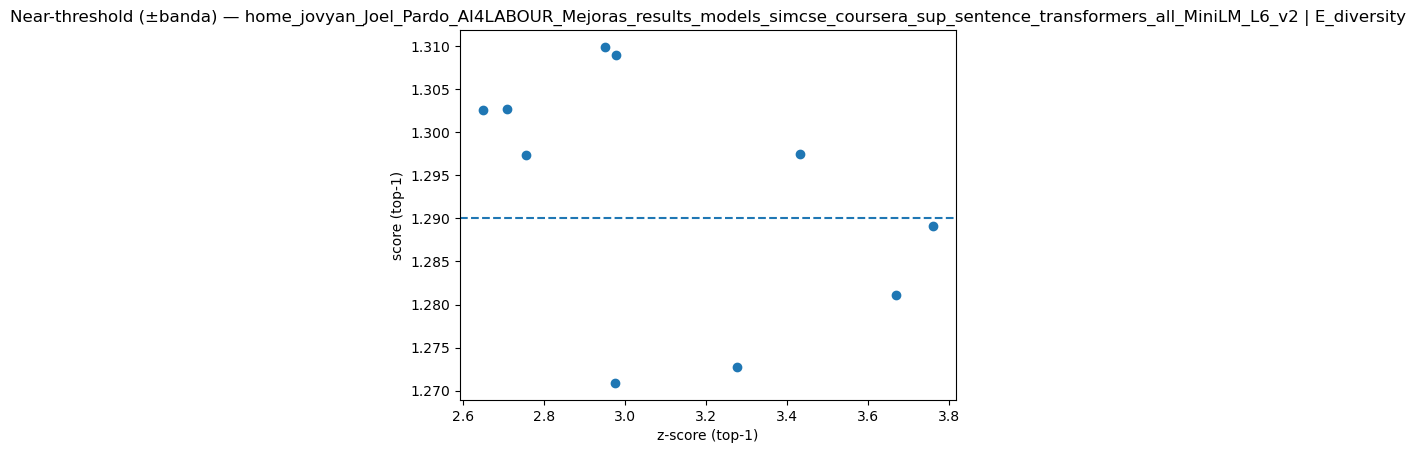

[H5] Guardado: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/plots/H5_winner_near_threshold_scatter_dwa.png


In [143]:
# === H5 · near-threshold: scatter score vs z del top-1 ===
near_thr_path = RESULTS_DIR / "near_threshold.csv"
if near_thr_path.exists():
    near_df = pd.read_csv(near_thr_path)
    if {"model","preset"}.issubset(near_df.columns):
        near_df = near_df[(near_df["model"]==winner["model"]) & (near_df["preset"]==winner["preset"])].copy()

    if not near_df.empty and {"z","score"}.issubset(near_df.columns):
        plt.figure()
        x = near_df["z"].values
        y = near_df["score"].values
        plt.scatter(x, y)
        try:
            thr_val = float(thr_txt) if thr_txt!="None" else None
        except:
            thr_val = None
        if thr_val is not None:
            plt.axhline(y=thr_val, linestyle="--")
        plt.xlabel("z-score (top-1)"); plt.ylabel("score (top-1)")
        plt.title(f"Near-threshold (±banda) — {winner['model']} | {winner['preset']}")
        fig_path = PLOTS_DIR / "H5_winner_near_threshold_scatter_dwa.png"
        plt.savefig(fig_path, bbox_inches="tight", dpi=160); plt.show()
        print("[H5] Guardado:", fig_path)
    else:
        print("[H5] near_threshold sin columnas necesarias (z, score).")
else:
    print("[H5] No existe near_threshold.csv (ver G3).")


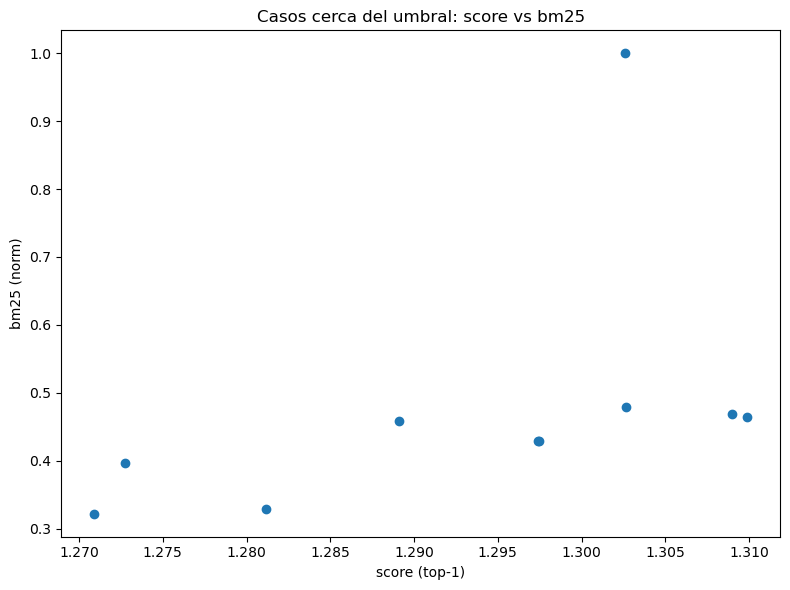

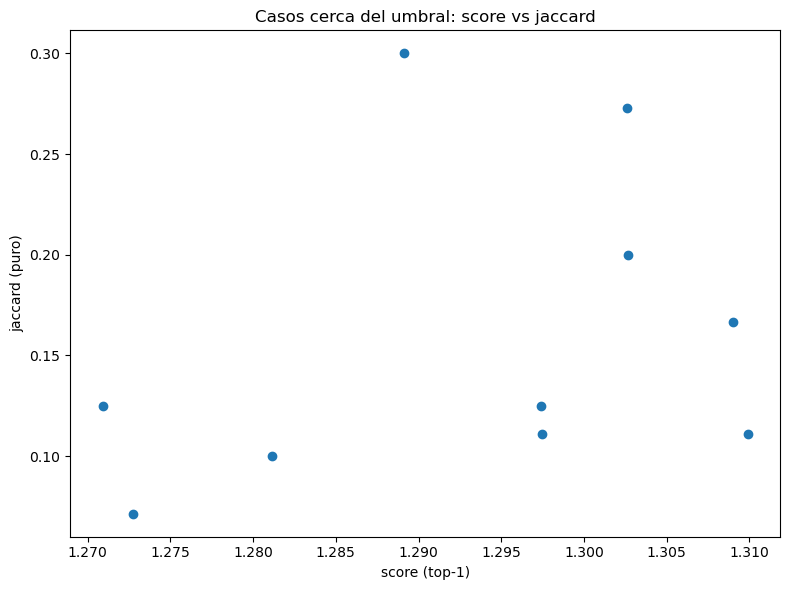

In [144]:
# H6) (Opcional) Puntos near-threshold: score vs bm25 o jacc
if not df_near.empty:
    plt.figure(figsize=(8,6))
    plt.scatter(df_near["score"].values, df_near["bm25"].values)
    plt.xlabel("score (top-1)")
    plt.ylabel("bm25 (norm)")
    plt.title("Casos cerca del umbral: score vs bm25")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "H6_nearthr_score_vs_bm25.svg", format="svg")
    plt.show()

    if "jacc" in df_near.columns:
        plt.figure(figsize=(8,6))
        plt.scatter(df_near["score"].values, df_near["jacc"].values)
        plt.xlabel("score (top-1)")
        plt.ylabel("jaccard (puro)")
        plt.title("Casos cerca del umbral: score vs jaccard")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "H6_nearthr_score_vs_jacc.svg", format="svg")
        plt.show()
else:
    print("[H6] No hay near_threshold para scatter.")


In [145]:
# === H6 · Tabla rápida de TOP combos y mejor umbral (si existe) ===
if not df_best_thr.empty:
    # Unir con el top-N de H1 para inspección
    keys_df = pd.DataFrame(top_keys, columns=["model","preset"])
    m = keys_df.merge(df_best_thr, on=["model","preset"], how="left")
    display(m)


,model,preset,thr,f1,coverage,precision
0,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,E_diversity,1.290044,0.378378,0.897436,0.400000
1,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,D_zfilter,1.276293,0.394737,0.948718,0.405405
2,sentence_transformers_all_distilroberta_v1,C_lex_sem_strong,1.186409,0.384615,1.000000,0.384615
3,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,B_hybrid_light,1.366370,0.361111,0.846154,0.393939
4,sentence_transformers_all_mpnet_base_v2,I_short_skills_bias,1.468687,0.388060,0.717949,0.464286


## I) SimCSE unsupervised 

* Objective: aprender embeddings donde paráfrasis (o dos “vistas” de la misma frase) queden cerca y no-paráfrasis queden lejos.

* Unsupervised: usa dropout como data augmentation: el mismo texto pasa dos veces por el encoder con dropout distinto → par positivo. El resto del batch son negativos (Multiple Negatives Ranking Loss).

* Supervised (opcional): si tienes pares (ancla, positivo) de verdad, entrenas con esos (y el resto del batch como negativos).

En tu caso:

* Unsupervised con todas las DWAs ya aporta.

* Puedes añadir hard negatives de tu propio Bloque D (FP frecuentes/vecinos confusos) para reforzar.

La magia de MultipleNegativesRankingLoss es que TODO lo que no sea el “par positivo” del mismo índice actúa como negativo, por tanto esos FPs presentes en el batch ejercerán presión para separarse.

In [88]:
#  Unsupervised SimCSE sobre tus DWAs 
from sentence_transformers import SentenceTransformer, losses, InputExample, models
from torch.utils.data import DataLoader
import torch, math, random
from pathlib import Path

# Config
SIMCSE_BACKBONE = "sentence-transformers/all-MiniLM-L6-v2"  # rápido y sólido
SIMCSE_EPOCHS   = 1               # sube a 2-3 si ves mejora estable
SIMCSE_BS       = 64              # si no cabe, baja y usa grad_accum
SIMCSE_LR       = 5e-5
SIMCSE_WARMUP   = 0.1             # ratio de steps
GRAD_ACCUM      = 1               # p.ej., 2 si BS=32 efectivo
AMP_MIXED       = True            # autocast si hay CUDA

SAVE_DIR_SIMCSE1 = RESULTS_DIR / "models" / "simcse_coursera_base" / SIMCSE_BACKBONE #.replace("/", "_")
SAVE_DIR_SIMCSE1.mkdir(parents=True, exist_ok=True)

SAVE_DIR_SIMCSE2 = RESULTS_DIR / "models" / "simcse_coursera_hard" / SIMCSE_BACKBONE #.replace("/", "_")
SAVE_DIR_SIMCSE2.mkdir(parents=True, exist_ok=True)

SAVE_DIR_SIMCSE3 = RESULTS_DIR / "models" / "simcse_coursera_sup" / SIMCSE_BACKBONE #.replace("/", "_")
SAVE_DIR_SIMCSE3.mkdir(parents=True, exist_ok=True)


### La idea general
**`MultipleNegativesRankingLoss`** en **SimCSE**:

* En SimCSE queremos que **pares positivos** (dos vistas de la misma frase) estén **cerca** en el espacio de embeddings.
* Y que todas las demás frases del **mismo batch** actúen como **negativos** (es decir, deben estar lejos).

### Cómo funciona paso a paso

1. **InputExample** → en unsupervised SimCSE se crean pares `(s, s)` del mismo texto, pero cada pasada lleva *dropout distinto* → dos representaciones ligeramente diferentes del mismo texto = **par positivo**.

   * Ej:

     * Texto original: *“Prepare procedural documents”*
     * Embedding 1 (con dropout A)
     * Embedding 2 (con dropout B)

2. **Dentro del batch**:

   * Supón batch size = 4 → tenemos 4 frases, cada una con su par positivo.
   * Eso genera 8 embeddings en total (cada frase → 2 vistas).

3. **Positivo**:

   * Para cada embedding, el **par correcto** es su otra vista.

4. **Negativos**:

   * Todos los demás embeddings del batch son considerados **negativos**.

5. **Loss (infoNCE)**:

   * Para cada ancla, se calcula la similitud coseno con **todas** las otras oraciones en el batch.
   * Se aplica softmax sobre estas similitudes.
   * El objetivo es que la probabilidad máxima recaiga en su **par positivo**.
   * Fórmula simplificada:

   $$
   L = - \log \frac{\exp(\text{sim}(h_i, h_i^+)/\tau)}{\sum_{j=1}^N \exp(\text{sim}(h_i, h_j)/\tau)}
   $$

   * donde:

     * $h_i$ = embedding de la oración ancla
     * $h_i^+$ = embedding positivo
     * $h_j$ = embeddings de todos los demás en el batch
     * $\tau$ = temperatura (scale, por defecto 1.0)





### ¿Qué aprende el encoder?

* A acercar embeddings de la **misma frase** (robustez frente a dropout / ruido).
* A separar embeddings de frases diferentes.
* Resultado: un **espacio semántico más estructurado**, donde frases con significado parecido acaban más cerca.


`MultipleNegativesRankingLoss` es una **loss contrastiva**: empuja el ancla hacia su positivo y lo aleja de todos los demás en el batch, aprovechando que cada frase que no es su par positivo puede servir como negativo “gratis”.


In [89]:

# Dataset: textos únicos y barajados
uniq_texts = list(dict.fromkeys(CORPUS_TEXTS))
random.shuffle(uniq_texts)


In [90]:

# SentenceTransformer ya aplica el truco de dropout para SimCSE unsup
encoder = SentenceTransformer(SIMCSE_BACKBONE, device=DEVICE)

train_examples = [InputExample(texts=[t, t]) for t in uniq_texts]
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=SIMCSE_BS, drop_last=True)

# Loss con soporte defensivo por cambios de firma
try:
    train_loss = losses.MultipleNegativesRankingLoss(encoder)
except TypeError:
    # versiones antiguas requieren 'scale' o 'similarity_fct'
    train_loss = losses.MultipleNegativesRankingLoss(model=encoder)

# Warmup steps
steps_per_epoch = math.floor(len(train_dataloader) / max(1, GRAD_ACCUM))
total_steps = max(1, steps_per_epoch * SIMCSE_EPOCHS)
warmup_steps = int(SIMCSE_WARMUP * total_steps)

# Entrenar
encoder.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=SIMCSE_EPOCHS,
    optimizer_params={"lr": SIMCSE_LR},
    warmup_steps=warmup_steps,
    use_amp=AMP_MIXED,
    show_progress_bar=True,
    checkpoint_path=None
)

# Guardar
encoder.save(str(SAVE_DIR_SIMCSE1))
print(f"[I] SimCSE unsup guardado en: {SAVE_DIR_SIMCSE1}")


/home/jovyan/.local/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py:948: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

[I] SimCSE unsup guardado en: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_base/sentence-transformers/all-MiniLM-L6-v2


In [91]:

# -------- Integración con tu pipeline --------
# Añade el encoder a CANDIDATE_MODELS y re-ejecuta el Bloque E (grid modelo×preset).
if 'CANDIDATE_MODELS' in globals():
    if str(SAVE_DIR_SIMCSE1) not in CANDIDATE_MODELS:
        CANDIDATE_MODELS.append(str(SAVE_DIR_SIMCSE1))
        print(f"[SIMCSE] Añadido a CANDIDATE_MODELS: {SAVE_DIR_SIMCSE1}")
    else:
        print("[SIMCSE] Ya estaba en CANDIDATE_MODELS")
else:
    print("[SIMCSE] Define CANDIDATE_MODELS antes si quieres agregarlo automáticamente.")

[SIMCSE] Añadido a CANDIDATE_MODELS: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_base/sentence-transformers/all-MiniLM-L6-v2


### HARD NEGATIVES del propio sistema

Puedes robustecer el entrenamiento mezclando negativos duros (vecinos confusos) en batches. Dos caminos:
1. Toma de errors_fp.csv las parejas (q_text, cand_text) como negativos duros. 
2. Construye batches donde cada ancla se empareja con su “otro” (dropout), y fuerzas a que el resto (incluido FP) sea negativo.

In [92]:
# Cargar FP como pares "difíciles"
fp_path = RESULTS_DIR / "errors_fp.csv"
hard_pairs = []
if fp_path.exists():
    df_fp = pd.read_csv(fp_path)
    # nos quedamos con algunos (q_text, cand_text) únicos
    hard_pairs = list({(r["q_text"], r["cand_text"]) for _, r in df_fp.iterrows()})
    random.shuffle(hard_pairs)
    hard_pairs = hard_pairs[: min(2000, len(hard_pairs))]  # tope

# Mezclamos dataset: mitad unsup, mitad con ancla=texto, pos=texto (SimCSE), pero sabiendo que los FPs estarán en el batch como negativos
mix_texts = uniq_texts.copy()
if hard_pairs:
    # reforzamos aparición de anclas donde hay FP frecuentes
    anchors_from_fp = [a for a, b in hard_pairs]
    mix_texts = anchors_from_fp + mix_texts
    random.shuffle(mix_texts)

train_examples = [InputExample(texts=[t, t]) for t in mix_texts]
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=SIMCSE_BS, drop_last=True)

encoder = SentenceTransformer(SIMCSE_BACKBONE, device=DEVICE)

# Loss con soporte defensivo por cambios de firma
try:
    train_loss = losses.MultipleNegativesRankingLoss(encoder)
except TypeError:
    # versiones antiguas requieren 'scale' o 'similarity_fct'
    train_loss = losses.MultipleNegativesRankingLoss(model=encoder)

# Warmup steps
steps_per_epoch = math.floor(len(train_dataloader) / max(1, GRAD_ACCUM))
total_steps = max(1, steps_per_epoch * SIMCSE_EPOCHS)
warmup_steps = int(SIMCSE_WARMUP * total_steps)

# Entrenar
encoder.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=SIMCSE_EPOCHS,
    optimizer_params={"lr": SIMCSE_LR},
    warmup_steps=warmup_steps,
    use_amp=AMP_MIXED,
    show_progress_bar=True,
    checkpoint_path=None
)

# Guardar
encoder.save(str(SAVE_DIR_SIMCSE2))
print(f"[I] SimCSE unsup guardado en: {SAVE_DIR_SIMCSE2}")


/home/jovyan/.local/lib/python3.11/site-packages/sentence_transformers/SentenceTransformer.py:948: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

[I] SimCSE unsup guardado en: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_hard/sentence-transformers/all-MiniLM-L6-v2


In [93]:

# -------- Integración con tu pipeline --------
# Añade el encoder a CANDIDATE_MODELS y re-ejecuta el Bloque E (grid modelo×preset).
if 'CANDIDATE_MODELS' in globals():
    if str(SAVE_DIR_SIMCSE2) not in CANDIDATE_MODELS:
        CANDIDATE_MODELS.append(str(SAVE_DIR_SIMCSE2))
        print(f"[SIMCSE] Añadido a CANDIDATE_MODELS: {SAVE_DIR_SIMCSE2}")
    else:
        print("[SIMCSE] Ya estaba en CANDIDATE_MODELS")
else:
    print("[SIMCSE] Define CANDIDATE_MODELS antes si quieres agregarlo automáticamente.")

[SIMCSE] Añadido a CANDIDATE_MODELS: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_hard/sentence-transformers/all-MiniLM-L6-v2


### SimCSE semi-supervised con GOLD (pequeño refuerzo)
Tienes, por query, positivos en GOLD. Puedes entrenar con pares (q, pos) reales (y el resto del batch negativo). Úsalo con moderación (tu GOLD es pequeño).

In [94]:
pairs = []
for q_text, dd in GOLD.items():
    for p in dd.get("positives", []):
        pairs.append((q_text, p))
random.shuffle(pairs)

# Filtra pares que estén en el corpus (ya tenemos TEXT2ID del bloque F)
pairs = [(q, p) for q, p in pairs if normalize_nfkc(q) in TEXT2QIDX and normalize_nfkc(p) in TEXT2ID]

if len(pairs) >= 8:  # mínimo razonable
    encoder_sup = SentenceTransformer(SIMCSE_BACKBONE, device=DEVICE)
    sup_examples = [InputExample(texts=[a, b]) for (a, b) in pairs]
    sup_dl = DataLoader(sup_examples, shuffle=True, batch_size=min(32, len(sup_examples)), drop_last=True)

    try:
        sup_loss = losses.MultipleNegativesRankingLoss(encoder_sup)
    except TypeError:
        sup_loss = losses.MultipleNegativesRankingLoss(model=encoder_sup)

    steps = max(1, len(sup_dl))
    warmup = int(0.1 * steps)
    encoder_sup.fit(
        train_objectives=[(sup_dl, sup_loss)],
        epochs=2, optimizer_params={"lr": 3e-5},
        warmup_steps=warmup, use_amp=True, show_progress_bar=True
    )
    encoder_sup.save(str(SAVE_DIR_SIMCSE3))
    print(f"[I] SimCSE semi-supervised guardado en: {SAVE_DIR_SIMCSE3}")

    # para evaluar
    CANDIDATE_MODELS.append(str(SAVE_DIR_SIMCSE3))
else:
    print("[I] Muy pocos pares GOLD para SimCSE supervised; omitido.")


Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Iteration:   0%|          | 0/2 [00:00<?, ?it/s]

Iteration:   0%|          | 0/2 [00:00<?, ?it/s]

[I] SimCSE semi-supervised guardado en: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/simcse_coursera_sup/sentence-transformers/all-MiniLM-L6-v2


## J) TSDAE (Denoising AutoEncoder)

* Qué busca: aprender embeddings robustos a ruido/paráfrasis reconstruyendo la oración original desde una versión corrompida.

* Cómo se entrena: encoder (Transformer + pooling) produce un embedding comprimido; un decoder trata de reconstruir el texto limpio. El encoder aprende representaciones más estables.

* Cuándo aporta: cuando hay ruido de redacción, siglas, variantes léxicas y descripciones tipo DWA/skills con mucha variación superficial.

In [ ]:
from huggingface_hub import login
import os

# Sustituye por tu token real de HF
# Use environment variable HF_TOKEN or set it here
hf_token = os.getenv("HF_TOKEN", "YOUR_HF_TOKEN_HERE")
login(token=hf_token)

#"google-bert/bert-base-uncased"
#"FacebookAI/roberta-base"

In [96]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [97]:
# TSDAE (Denoising AutoEncoder) 

from sentence_transformers import SentenceTransformer, models, losses, datasets
from torch.utils.data import DataLoader
import torch, math, random, os
from pathlib import Path

# -------- Configuración --------
TSDAE_BACKBONE = "google-bert/bert-base-uncased"   # alternatives: "distilbert/distilroberta-base", "FacebookAI/xlm-roberta-base", "distilbert/distilbert-base-uncased"
TSDAE_EPOCHS   = 1
TSDAE_BS       = 64                     # si no cabe, baja y usa GRAD_ACCUM>1
TSDAE_LR       = 5e-5
TSDAE_WARMUP   = 0.1                    # fracción de steps
TSDAE_MAXLEN   = 256
GRAD_ACCUM     = 1
AMP_MIXED      = True                   # autocast si hay CUDA
AUGMENT_BASIC  = False                  # True si quieres duplicar con corrupción previa

SAVE_DIR_TSDAE   = RESULTS_DIR / "models" / "tsdae" / TSDAE_BACKBONE
SAVE_DIR_TSDAE.mkdir(parents=True, exist_ok=True)

print(f"[TSDAE] backbone={TSDAE_BACKBONE} epochs={TSDAE_EPOCHS} bs={TSDAE_BS} lr={TSDAE_LR} maxlen={TSDAE_MAXLEN}")
print(f"[TSDAE] device={DEVICE} amp={AMP_MIXED} grad_accum={GRAD_ACCUM} augment_basic={AUGMENT_BASIC}")
print(f"[TSDAE] save_dir={SAVE_DIR_TSDAE}")


[TSDAE] backbone=google-bert/bert-base-uncased epochs=1 bs=64 lr=5e-05 maxlen=256
[TSDAE] device=cuda amp=True grad_accum=1 augment_basic=False
[TSDAE] save_dir=/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/tsdae/google-bert/bert-base-uncased


### **Qué hace `DenoisingAutoEncoderLoss` (TSDAE)**

1. **Entrada:** una frase de tu corpus (ej: *“Prepare procedural documents”*).
2. **Corrupción:** el `DenoisingAutoEncoderDataset` genera una versión **ensuciada** de esa frase (p. ej. elimina o permuta palabras → *“Prepare documents”*).
3. **Encoder:** esa frase ruidosa pasa por tu encoder (p. ej. DistilRoBERTa + pooling) y produce un **embedding**.
4. **Decoder:** a partir de ese embedding, un **decoder Transformer** intenta **reconstruir** la frase original limpia (*“Prepare procedural documents”*).
5. **Loss:** mide cuán **bien se reconstruye** la frase original comparada con la salida del decoder (usualmente usando cross-entropy sobre los tokens).

### **¿Qué aprende el encoder?**

* A producir **representaciones robustas** que capturen el **significado global**, incluso cuando la frase de entrada está incompleta o alterada.
* Como el decoder necesita información semántica suficiente para “recomponer” la oración, el encoder se ve obligado a **codificar semántica de manera más estable**.

`DenoisingAutoEncoderLoss` entrena el encoder para que, a partir de frases ruidosas, produzca embeddings que permitan **reconstruir las frases limpias**.
El decoder solo vive en el entrenamiento; al final te quedas con un **encoder más robusto** para similitud semántica.


### ¿De dónde sale ese decoder?
En **TSDAE** el **decoder** no es algo que tú definas manualmente, sino que lo crea internamente la librería `sentence-transformers` cuando usas:

* **`decoder_name_or_path=TSDAE_BACKBONE`** → se carga un **modelo Transformer del mismo tipo** que el encoder (por ejemplo, `distilroberta-base` o `bert-base-uncased`) pero usado como **decoder**.
* **`tie_encoder_decoder=True`** → los pesos de embedding entre encoder y decoder se comparten (“atados”), así el decoder “habla el mismo idioma” que el encoder.

En la práctica:

1. El **encoder** procesa la frase ruidosa → produce un embedding.
2. El **decoder** (instanciado automáticamente a partir del backbone) toma ese embedding y trata de **reconstruir la frase original**.
3. La **loss** mide la diferencia entre tokens predichos y tokens originales.

### Después del entrenamiento:

* El **decoder se descarta**.
* Te quedas **solo con el encoder** (`tsdae_model`) para generar embeddings robustos.

El decoder **no lo diseñas tú**, se crea automáticamente a partir del mismo `backbone` que usas para el encoder, y solo existe durante el entrenamiento para forzar al encoder a aprender mejores representaciones.



In [98]:

# # -------- Datos (corpus) --------
# # Usamos tus DWAs únicas como oraciones de entrenamiento
# uniq_texts = list(dict.fromkeys(CORPUS_TEXTS))
# random.shuffle(uniq_texts)

# def corrupt_text_basic(s: str, p_drop=0.10, p_swap=0.05):
#     toks = s.split()
#     # drop suave
#     kept = []
#     for t in toks:
#         if len(toks) > 3 and random.random() < p_drop:
#             continue
#         kept.append(t)
#     # swap adyacente
#     if len(kept) > 3 and random.random() < p_swap:
#         i = random.randrange(0, len(kept)-1)
#         kept[i], kept[i+1] = kept[i+1], kept[i]
#     return " ".join(kept) if kept else s

# train_texts = uniq_texts if not AUGMENT_BASIC else (uniq_texts + [corrupt_text_basic(t) for t in uniq_texts])
# random.shuffle(train_texts)
# print(f"[TSDAE] num_texts={len(train_texts)} (uniq={len(uniq_texts)})")


In [99]:

# -------- Modelo (encoder) --------
word_embedding_model = models.Transformer(TSDAE_BACKBONE, max_seq_length=TSDAE_MAXLEN)
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
tsdae_model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=DEVICE)

# -------- Dataset + Dataloader --------
train_dataset = datasets.DenoisingAutoEncoderDataset(uniq_texts)  # aplica ruido interno (masking/drop/swap)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=TSDAE_BS, drop_last=True)

# -------- Pérdida TSDAE (defensiva ante cambios de firma) --------

# Loss: decoder explícito, sin tie (evita el bug de versión)
train_loss = losses.DenoisingAutoEncoderLoss(
    tsdae_model,
    decoder_name_or_path=TSDAE_BACKBONE,      # deja que lo cree a partir del encoder
    tie_encoder_decoder=False       # evita el problema de versiones
)


# -------- Entrenamiento --------
steps_per_epoch = max(1, len(train_dataloader) // max(1, GRAD_ACCUM))
# total_steps     = max(1, steps_per_epoch * TSDAE_EPOCHS)
warmup_steps    = int(TSDAE_WARMUP * total_steps)

# Fit (SentenceTransformer maneja AMP, scheduler, etc.)
tsdae_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=TSDAE_EPOCHS,
    optimizer_params={"lr": TSDAE_LR},
    warmup_steps=warmup_steps,
    use_amp=AMP_MIXED,
    show_progress_bar=True
)

# -------- Guardar encoder --------
tsdae_model.save(str(SAVE_DIR_TSDAE))
print(f"[TSDAE] Modelo guardado en: {SAVE_DIR_TSDAE}")


Some weights of BertLMHeadModel were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.layer.1.crossattention.self.key.bi

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


[TSDAE] Modelo guardado en: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/tsdae/google-bert/bert-base-uncased


In [100]:

# -------- Integración con tu pipeline --------
# Añade el encoder a CANDIDATE_MODELS y re-ejecuta el Bloque E (grid modelo×preset).
if 'CANDIDATE_MODELS' in globals():
    if str(SAVE_DIR_TSDAE) not in CANDIDATE_MODELS:
        CANDIDATE_MODELS.append(str(SAVE_DIR_TSDAE))
        print(f"[TSDAE] Añadido a CANDIDATE_MODELS: {SAVE_DIR_TSDAE}")
    else:
        print("[TSDAE] Ya estaba en CANDIDATE_MODELS")
else:
    print("[TSDAE] Define CANDIDATE_MODELS antes si quieres agregarlo automáticamente.")


[TSDAE] Añadido a CANDIDATE_MODELS: /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/models/tsdae/google-bert/bert-base-uncased


**IMPORTANTE** Ahora toca correr desde el bloque E hasta el H. Fijate porque arriba defines de nuevo los CANDIDATE_MODELS

## K) Produccion del winner

* No aplica umbral al generar el top-3 (si quieres umbral, mejor aplicarlo solo al top-1 en producción).

* Asegura no self-match y sin duplicados por query.

* Toma top 3 por query con groupby().head(3) (no depende de la columna rank estar perfecta).

* Hace un merge con TODAS las queries para que salgan 221 filas siempre.

* Rellena huecos con vacío si una query tiene <3 candidatos.

In [146]:
import pandas as pd
import numpy as np
import re

# 1) Cargar consolidado largo y ganador
neighbors_long_path = next((p for p in RESULTS_DIR.glob("neighbors_all_long_*.csv")), None)
assert neighbors_long_path is not None, "No encuentro neighbors_all_long_*.csv (Bloque E)."
df_long = pd.read_csv(neighbors_long_path)

winner_txt = RESULTS_DIR / "winner.txt"
if winner_txt.exists():
    txt = winner_txt.read_text()
    WIN_MODEL = re.search(r"MODEL=(.*)", txt).group(1).strip()
    WIN_PRESET = re.search(r"PRESET=(.*)", txt).group(1).strip()
else:
    ranking_summary_path = next((p for p in RESULTS_DIR.glob("ranking_summary_*.csv")), None)
    assert ranking_summary_path is not None, "No encuentro ranking_summary_*.csv para elegir ganador."
    rs = pd.read_csv(ranking_summary_path)
    k_main = 10 if (rs["k"]==10).any() else (5 if (rs["k"]==5).any() else int(rs["k"].max()))
    dfk = rs[rs["k"]==k_main][["model","preset","nDCG@k","MAP@k"]]
    df1 = rs[rs["k"]==1][["model","preset","R@k","MRR"]].rename(columns={"R@k":"R@1"})
    dfm = dfk.merge(df1, on=["model","preset"], how="left").sort_values(["nDCG@k","MAP@k","R@1","MRR"], ascending=False)
    WIN_MODEL, WIN_PRESET = dfm.iloc[0]["model"], dfm.iloc[0]["preset"]

print(f"[K] Winner → {WIN_MODEL} | {WIN_PRESET}")


[K] Winner → home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2 | E_diversity


In [147]:

# 2) Filtrar por ganador
dfl = (df_long[(df_long["model"]==WIN_MODEL) & (df_long["preset"]==WIN_PRESET)]
       .copy()
       .sort_values(["q_idx","rank"]))
# 3) Mapas id->texto
IDX2TEXT = {i: t for i, t in enumerate(CORPUS_TEXTS)}
ID2TEXT  = {lid: t for lid, t in zip(CORPUS_LABELS, CORPUS_TEXTS)}

# 4) Limpieza básica: sin self-match y sin duplicados por query
dfl = dfl[dfl["q_idx"] != dfl["cand_idx"]].copy()
dfl = dfl.drop_duplicates(subset=["q_idx","cand_idx"], keep="first")

# 5) Tomar top-3 por query (independiente de si rank es 1..K exacto)
top3 = dfl.sort_values(["q_idx","rank"]).groupby("q_idx", as_index=False).head(3).copy()
top3["cand_text"] = top3["cand_label"].map(ID2TEXT)

# 6) Pivot a columnas (dwa1..dwa3)
top3 = top3.assign(pos=lambda x: x.groupby("q_idx").cumcount()+1)  # 1,2,3 dentro de cada query
top3["pos"] = "dwa" + top3["pos"].astype(str)
pivot = (top3.pivot_table(index="q_idx", columns="pos", values="cand_text", aggfunc="first")
              .reset_index())


In [148]:
display(pivot)

pos,q_idx,dwa1,dwa2,dwa3
0,0,prepare operational reports,confer with other personnel to resolve design ...,monitor operational procedures in technical en...
1,1,prepare proposal documents,prepare financial documents,"prepare contracts, disclosures, or applications"
2,2,recommend organizational process or policy cha...,implement design or process improvements,evaluate technical data to determine effect on...
3,3,confer with other personnel to resolve design ...,evaluate technical data to determine effect on...,provide technical guidance to other personnel
4,4,"coordinate activities with suppliers, contract...",communicate organizational information to cust...,"explain engineering drawings, specifications, ..."
...,...,...,...,...
216,216,inspect condition or functioning of facilities...,monitor activities affecting environmental qua...,examine characteristics or behavior of living ...
217,217,examine characteristics or behavior of living ...,research genetic characteristics or expression,create physical models or prototypes
218,218,classify organisms based on their characterist...,inspect condition of natural environments,research microbiological or chemical processes...
219,219,set up laboratory or field equipment,maintain laboratory or technical equipment,operate industrial equipment


In [149]:

# 7) Construir tabla completa con TODAS las queries (221 filas)
all_q = pd.DataFrame({"q_idx": list(range(len(CORPUS_TEXTS)))})
all_q["dwa_original"] = all_q["q_idx"].map(lambda i: IDX2TEXT.get(int(i), ""))

final = all_q.merge(pivot, on="q_idx", how="left")

# Asegurar columnas presentes y en orden
for col in ["dwa1","dwa2","dwa3"]:
    if col not in final.columns:
        final[col] = ""
final = final[["dwa_original","dwa1","dwa2","dwa3"]].fillna("")

print(f"[K1] Filas={len(final)} (esperado={len(CORPUS_TEXTS)})")
print(final.head(5).to_string(index=False))

[K1] Filas=221 (esperado=221)
                                                                                dwa_original                                                                             dwa1                                                                      dwa2                                                                                        dwa3
                                            train personnel on proper operational procedures                                                      prepare operational reports     confer with other personnel to resolve design or operational problems monitor operational procedures in technical environments to ensure conformance to standards
                                                                prepare procedural documents                                                       prepare proposal documents                                               prepare financial documents                                           

In [150]:
display(final)

,dwa_original,dwa1,dwa2,dwa3
0,train personnel on proper operational procedures,prepare operational reports,confer with other personnel to resolve design ...,monitor operational procedures in technical en...
1,prepare procedural documents,prepare proposal documents,prepare financial documents,"prepare contracts, disclosures, or applications"
2,recommend technical design or process changes ...,recommend organizational process or policy cha...,implement design or process improvements,evaluate technical data to determine effect on...
3,confer with technical personnel to prepare des...,confer with other personnel to resolve design ...,evaluate technical data to determine effect on...,provide technical guidance to other personnel
4,communicate technical information to suppliers...,"coordinate activities with suppliers, contract...",communicate organizational information to cust...,"explain engineering drawings, specifications, ..."
...,...,...,...,...
216,inspect condition of natural environments,inspect condition or functioning of facilities...,monitor activities affecting environmental qua...,examine characteristics or behavior of living ...
217,classify organisms based on their characterist...,examine characteristics or behavior of living ...,research genetic characteristics or expression,create physical models or prototypes
218,examine characteristics or behavior of living ...,classify organisms based on their characterist...,inspect condition of natural environments,research microbiological or chemical processes...
219,operate laboratory or field equipment,set up laboratory or field equipment,maintain laboratory or technical equipment,operate industrial equipment


In [151]:
# 8) Guardar CSV
corpus_tag = f"n{len(CORPUS_TEXTS)}"
out_csv = RESULTS_DIR / f"dwa_top3_{WIN_MODEL}_{WIN_PRESET}_{corpus_tag}.csv"
final.to_csv(out_csv, index=False)
print(f"[K] Export listo → {out_csv} | filas={len(final)} (esperado={len(CORPUS_TEXTS)})")

[K] Export listo → /home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/results/dwa_top3_home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_results_models_simcse_coursera_sup_sentence_transformers_all_MiniLM_L6_v2_E_diversity_n221.csv | filas=221 (esperado=221)


In [152]:
# 9) Diagnóstico rápido
missing_any = (final[["dwa1","dwa2","dwa3"]]== "").all(axis=1).sum()
only_one    = ((final["dwa1"]!="") & (final["dwa2"]=="") & (final["dwa3"]=="")).sum()
only_two    = ((final["dwa1"]!="") & (final["dwa2"]!="") & (final["dwa3"]=="")).sum()
print(f"[K] Sin ninguna recomendación: {missing_any}")
print(f"[K] Solo 1 recomendación:     {only_one}")
print(f"[K] Solo 2 recomendaciones:   {only_two}")

[K] Sin ninguna recomendación: 0
[K] Solo 1 recomendación:     0
[K] Solo 2 recomendaciones:   0


In [153]:
# Vista rápida
display(final.head(5))

,dwa_original,dwa1,dwa2,dwa3
0,train personnel on proper operational procedures,prepare operational reports,confer with other personnel to resolve design ...,monitor operational procedures in technical en...
1,prepare procedural documents,prepare proposal documents,prepare financial documents,"prepare contracts, disclosures, or applications"
2,recommend technical design or process changes ...,recommend organizational process or policy cha...,implement design or process improvements,evaluate technical data to determine effect on...
3,confer with technical personnel to prepare des...,confer with other personnel to resolve design ...,evaluate technical data to determine effect on...,provide technical guidance to other personnel
4,communicate technical information to suppliers...,"coordinate activities with suppliers, contract...",communicate organizational information to cust...,"explain engineering drawings, specifications, ..."
